<a href="https://www.kaggle.com/code/vladosht/simple-stock-pricing-model?scriptVersionId=274853420" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

This notebook will present a model which attempts to make individual estimates whether a stock is undervalued or not. It is based on the fundamental financial data of 3000+ public companies, which report to the SEC and which are currently traded on US stock exchanges.

DISCLAIMER: The results of this model must not in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import multiprocessing as mp
import json
from sklearn import linear_model, preprocessing
pd.set_option('display.max_rows', 200)
# Workaround for a pandas bug, as described here:
# https://stackoverflow.com/questions/30519487/pandas-error-invalid-value-encountered
pd.set_option('display.float_format', lambda x:'%f'%x)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Torch threads:',torch.get_num_threads())
print(torch.ones(1, device=device),device)

Torch threads: 2
tensor([1.], device='cuda:0') cuda


In [3]:
if __name__ == '__main__':
    mp.set_start_method('fork')
print('{} CPUs available'.format(mp.cpu_count()))
max_jobs = mp.cpu_count() + 1

4 CPUs available


The model will be based on the following features and labels, taken from the SEC fundamentals dataset:

In [4]:
ml_features = ['Assets','Liabilities','NetCashOperating_ttm']
ml_label = 'price'
keys = ['snapshot','cik','date']
window_size = 12*3 #in number of snapshots

The model is called "simple", because it is rooted in this very basic assumption:  
Market_Capitalization = ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) \* hype + bias  
The business logic behind this formula is that the market capitalization of a company is dependent on its current static value (its equity) and its future cashflows. The following considerations apply:  
1. We assume the total assets of an individual company should never be taken at the nominal value that appears on the balance sheet, because they often contain significant amount of "intangible" assets, for which it is notoriously difficult to arrive at a fair value. Therefore, we discount them with an asset_multiplier.
2. The Liabilities, on the other hand, can be taken at nominal value, because it is a rare event for any kind of debt, accounts payable or the like, to be written off.
3. Then, the cash flows from operating activities can be modeled as a [perpetuity](https://en.wikipedia.org/wiki/Perpetuity). This is inspired by the idea for a [Steady State Cash Flow Model](https://www.google.com/search?q=%22Steady+State+Cash+Flow+Model%22) where we attempt to estimate the fair value of a company on the assumption that its business behaves the same way for the foreseeable future. In essence, we again discount the NetCashOperating_ttm with a cash_multiplier. We use the Trailing Twelve Months (ttm) value here, and not the quarterly value, because it smoothens any seasonalities and makes the model less erratic.
4. All of the above is multiplied by a "hype" parameter, which is the premium or penalty that the market gives to the total value of the company.
5. The bias further fine-tunes the company value to its market capitalization.  

However, it seems difficult to obtain freely available historic market capitalization data for individual companies. It turns out this is not really necessary. It is much easier to obtain historic prices and modelling the share price directly is even simpler.  
We do this by maximizing the **correlation coefficient** between our formula and the price. In short, we try to find such asset_multiplier and cash_multiplier parameters, for which the correlation between ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) and the price is equal to 1.

In [5]:
# We use this dataset to provide ticker descriptions later on.
with open('/kaggle/input/sec-edgar-cik-ticker-exchange/company_tickers_exchange.json',mode='rt') as f:
    jfile = json.load(f)
tickers = pd.DataFrame(columns=jfile['fields'],data=jfile['data'],dtype=str)
tickers = tickers[tickers['exchange']!='OTC'].dropna() #leave only tickers traded on an exchange
tickers['exchange'] = tickers['exchange'].str.upper().str.strip()
tickers['cik'] = tickers['cik'].str.zfill(10)
tickers['len'] = 4
tickers.loc[tickers[tickers['ticker'].str.contains('-')].index,'len'] += 1
tickers['ticker'] = tickers.apply(lambda row: str(row.ticker[:row.len]),axis='columns').str.rstrip().str.rstrip('-').str.upper()
tickers = tickers.sort_values(by=['cik','exchange','ticker']).drop_duplicates(subset=['cik'],keep='last').set_index('cik').drop(columns=['len'])
tickers

,name,ticker,exchange
cik,,,
0000001750,AAR CORP,AIR,NYSE
0000001800,ABBOTT LABORATORIES,ABT,NYSE
0000002098,ACME UNITED CORP,ACU,NYSE
0000002178,"ADAMS RESOURCES & ENERGY, INC.",AE,NYSE
0000002186,BK Technologies Corp,BKTI,NYSE
...,...,...,...
0001984060,Atlas Energy Solutions Inc.,AESI,NYSE
0001990550,"Ambrx Biopharma, Inc.",AMAM,NASDAQ
0001993004,"NorthWestern Energy Group, Inc.",NWE,NASDAQ


In [6]:
prices = pd.read_csv('/kaggle/input/monthly-us-stock-prices/prices.csv').rename(columns={'date':'snapshot'}).dropna()
prices['snapshot'] = pd.to_datetime(prices['snapshot']).dt.date
prices

,ticker,exchange,snapshot,price
0,A,NYSE - Delayed Quote,2010-02-01,20.050000
1,A,NYSE - Delayed Quote,2010-03-01,22.500000
2,A,NYSE - Delayed Quote,2010-04-01,24.600000
3,A,NYSE - Delayed Quote,2010-05-01,25.940000
4,A,NYSE - Delayed Quote,2010-06-01,23.150000
...,...,...,...,...
602887,ZYXI,NasdaqGS - Delayed Quote,2025-07-01,2.580000
602888,ZYXI,NasdaqGS - Delayed Quote,2025-08-01,2.230000
602889,ZYXI,NasdaqGS - Delayed Quote,2025-09-01,1.640000
602890,ZYXI,NasdaqGS - Delayed Quote,2025-10-01,1.450000


In [7]:
raw_snapshots = pd.read_csv('/kaggle/input/fundamental-data-from-sec-xbrl-companyfacts-zip/snapshots.csv',dtype={'cik':str})
for i in ['snapshot','date']:
    raw_snapshots[i] = pd.to_datetime(raw_snapshots[i]).dt.date
raw_snapshots['timediff'] = pd.to_timedelta((raw_snapshots['snapshot'] - raw_snapshots['date'])).dt.days
raw_snapshots

,snapshot,cik,date,Assets,Revenue,COGS,GrossProfit,Equity,NetCashOperating,NetCashFinancing,...,Revenue_ttm,GrossProfit_ttm,NetCashOperating_ttm,NetCashFinancing_ttm,Earnings_ttm,ticker,exchange,PublicFloat,Employees,timediff
0,2012-01-01,0000001750,2011-11-30,1.821612,0.482000,0.403400,0.078600,0.863948,0.030412,-0.006559,...,1.920517,0.322328,0.083588,0.026485,0.073512,AIR,NYSE,0.934568,NaN,32
1,2012-01-01,0000001800,2011-09-30,59.628176,9.816682,3.973250,5.843432,24.603800,3.054430,-2.668122,...,38.441677,22.693948,9.885247,-4.831951,4.550604,ABT,NYSE,69.683329,NaN,93
2,2012-01-01,0000001961,2011-09-30,NaN,0.000000,0.000000,0.000000,NaN,-0.000067,0.000150,...,0.000188,0.000169,-0.000528,0.000456,-0.000968,NaN,NaN,NaN,NaN,93
3,2012-01-01,0000002034,2011-09-30,0.292355,0.101317,0.082798,0.018519,0.161372,0.005913,-0.001570,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93
4,2012-01-01,0000002098,2011-09-30,0.055344,0.019036,0.012396,0.006640,0.027561,0.003165,-0.000680,...,0.093494,0.033742,-0.003533,0.008428,0.004770,ACU,NYSE,NaN,NaN,93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1077584,2025-11-08,0002074872,2025-09-30,0.013448,NaN,NaN,NaN,-0.000063,0.000000,0.010650,...,NaN,NaN,NaN,NaN,NaN,KRSP,NYSE,NaN,NaN,39
1077585,2025-11-08,0002075336,2025-06-30,0.000314,NaN,NaN,NaN,-0.000018,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,131
1077586,2025-11-08,0002075816,2025-06-30,0.000062,NaN,NaN,NaN,-0.000023,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,EMIS,NASDAQ,NaN,NaN,131
1077587,2025-11-08,0002077010,2025-06-30,0.000172,NaN,NaN,NaN,0.000010,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,OTGA,NASDAQ,NaN,NaN,131


Below we merge the fundamental data with the price data and do some dataset cleaning to maximize model performance. The datasets themselves are documented on their respective pages and you can refer to them for further insights about their structure.

In [8]:
snapshots = pd.merge(raw_snapshots,prices,on=['ticker','snapshot'],suffixes=('','_yahoo'),how='left')

# The key date (snapshot date) must always be later than the period-end date. We enforce this
# per cik using the timediff column - it must be positive for all records of a cik.
# We also ensure a window_size number of snapshots of historic data is available for each cik.
snapshots = snapshots[keys +['ticker'] + ml_features + [ml_label] + ['timediff']]
valid_ciks = snapshots.dropna().groupby(by='cik')['timediff'].aggregate(['min','count'])
valid_ciks = valid_ciks[(valid_ciks['min']>0)&(valid_ciks['count']>window_size)]
snapshots = snapshots.set_index(keys)
snapshots = snapshots.loc[(slice(None),valid_ciks.index.to_list()),:].sort_index().drop(columns='timediff')

# Ciks that have assets close to zero cause problems during training. We remove them
zero_asset_ciks = list(snapshots[snapshots['Assets'].fillna(0.0).abs()<1e-3].reset_index()['cik'].unique())
zero_asset_ciks = snapshots.loc[(slice(None),zero_asset_ciks),:].index
snapshots = snapshots.drop(index=zero_asset_ciks)

# There are several ciks, that have reported wrong data 1000 times larger than actual.
# They apparently never submitted a correction.
# This data disrupts the training and we remove the whole ciks.
asset_outliers = snapshots.groupby(by='cik')['Assets'].aggregate(['min','max'])
asset_outliers = asset_outliers['min']/asset_outliers['max']
asset_outliers = asset_outliers.sort_values().fillna(0.0)
asset_outliers = list(asset_outliers[asset_outliers<1e-3].reset_index()['cik'].unique())
asset_outliers = snapshots.loc[(slice(None),asset_outliers),:].index
snapshots = snapshots.drop(index=asset_outliers)
snapshots

ticker    Assets  Liabilities  \
snapshot   cik        date                                       
2012-01-01 0000001750 2011-11-30    AIR  1.821612     0.957664   
           0000001800 2011-09-30    ABT 59.628176    35.024376   
           0000002098 2011-09-30    ACU  0.055344     0.027783   
           0000002488 2011-10-01    AMD  5.236000     3.492000   
           0000002969 2011-09-30    APD 14.290700     8.494900   
...                                 ...       ...          ...   
2025-11-08 0001894954 2025-06-30   XPON  0.008605     0.006538   
           0001901637 2025-06-30   USCB  2.719474     2.487891   
           0001902733 2025-07-31   NCNO  1.616017     0.559199   
           0001914605 2025-06-30   ECBK  1.515014     1.346737   
           0001915657 2025-09-30   DINO 17.264000     7.834000   

                                  NetCashOperating_ttm     price  
snapshot   cik        date                                        
2012-01-01 0000001750 2011-11-30              0.083588 19.170000  
           0000001800 2011-09-30              9.885247 26.980000  
           0000002098 2011-09-30             -0.003533  9.500000  
           0000002488 2011-10-01             -0.018000  5.400000  
           0000002969 2011-09-30              1.753200 78.810000  
...                                                ...       ...  
2025-11-08 0001894954 2025-06-30             -0.007786       NaN  
           0001901637 2025-06-30              0.040351       NaN  
           0001902733 2025-07-31              0.067814       NaN  
           0001914605 2025-06-30              0.006604       NaN  
           0001915657 2025-09-30              1.167000       NaN  

[456946 rows x 5 columns]

Machine learning algorithms in general cannot handle NaN values. The data we feed into our algorithm later must not only be free of NaNs, but it must also be symmetrical, i.e., for each cik there must be the same number of snapshots in the dataset. This is of course not the case in the raw data, so we create rows where they do not exist for a particular cik/snapshot combination. Then we replace all NaNs with zero, but we do retain information in a new column (is_created) whether a row was artificially created or not.

In [9]:
ml_input_df = snapshots.dropna().copy()
ml_input_df['is_created'] = False
unique_snapshot_dates = ml_input_df.index.get_level_values(0).unique().sort_values().to_series()
unique_ciks = ml_input_df.index.get_level_values(1).unique().sort_values().to_series()
print("There are {} unique snapshots and {} unique ciks for a total of {} records.".format(len(unique_snapshot_dates),len(unique_ciks),len(unique_snapshot_dates)*len(unique_ciks)))

ml_input_df = pd.merge(pd.merge(unique_snapshot_dates, unique_ciks, how='cross'),ml_input_df[ml_features+[ml_label,'is_created']].reset_index(drop=False),how='left')
ml_input_df = ml_input_df.drop(columns=['date']).set_index(['cik','snapshot']).sort_index()
ml_input_df['is_created'] = ml_input_df['is_created'].isna()
ml_input_df = ml_input_df.fillna(0.0)
ml_input_df

There are 166 unique snapshots and 3436 unique ciks for a total of 570376 records.


Assets  Liabilities  NetCashOperating_ttm     price  \
cik        snapshot                                                            
0000001750 2012-01-01  1.821612     0.957664              0.083588 19.170000   
           2012-02-01  1.821612     0.957664              0.083588 21.190000   
           2012-03-01  1.821612     0.957664              0.083588 22.050000   
           2012-04-01  2.220293     1.330213              0.066898 18.250000   
           2012-05-01  2.220293     1.330213              0.066898 15.450000   
...                         ...          ...                   ...       ...   
0001915657 2025-06-01 16.542000     7.355000              0.704000 36.130000   
           2025-07-01 16.542000     7.355000              0.704000 41.080000   
           2025-08-01 16.843000     7.561000              1.067000 43.940000   
           2025-09-01 16.843000     7.561000              1.067000 50.880000   
           2025-10-01 16.843000     7.561000              1.067000 52.340000   

                       is_created  
cik        snapshot                
0000001750 2012-01-01       False  
           2012-02-01       False  
           2012-03-01       False  
           2012-04-01       False  
           2012-05-01       False  
...                           ...  
0001915657 2025-06-01       False  
           2025-07-01       False  
           2025-08-01       False  
           2025-09-01       False  
           2025-10-01       False  

[570376 rows x 5 columns]

The cell below is the heart of our machine learning model. The following is critical for the loss function we want to use - the correlation coefficient between our model formula and the price. Unfortunately the built-in PyTorch function can handle only pairs of 1d tensors, so with the help of Gemini we re-created it to handle our multi-dimensional data.

In [10]:
# Generated by Gemini AI
def batched_corrcoef(t1, t2):
    """
    Computes batched correlation coefficient matrix.
    t1 and t2 are tensors of shape (B, N) where B is the batch size
    and N is the number of observations.
    Returns a tensor of shape (B, 2, 2).
    """
    # Stack the tensors along a new dimension to create a (B, 2, N) tensor
    stacked_tensors = torch.stack([t1, t2], dim=1)

    # Compute covariance for each batch
    # We need to compute covariance for each item in the batch.
    # torch.cov doesn't have a batch dimension argument.
    # We can implement batched covariance manually.
    mean_x = torch.mean(stacked_tensors, dim=2, keepdim=True)
    mx = stacked_tensors - mean_x
    # For batched dot product, we can use matmul
    # mx is (B, 2, N), mx.transpose(-1, -2) is (B, N, 2)
    # cov is (B, 2, 2)
    cov_matrix = torch.matmul(mx, mx.transpose(-1, -2)) / (stacked_tensors.size(2) - 1)

    # Extract diagonal for standard deviation
    std_dev = torch.sqrt(torch.diagonal(cov_matrix, dim1=-2, dim2=-1))
    # std_dev is (B, 2). We need to compute outer product for each batch item.
    # We can do this by unsqueezing and multiplying.
    std_dev_prod = std_dev.unsqueeze(2) * std_dev.unsqueeze(1)

    # Normalize covariance matrix
    corr_matrix = cov_matrix / std_dev_prod
    return corr_matrix

# Create two sample tensors
t1 = torch.randn(10, 5)
t2 = torch.randn(10, 5)

# Compute batched correlation coefficient
result_vectorized = batched_corrcoef(t1, t2)

print("Shape of the vectorized result:", result_vectorized.shape)
print("Result for the first batch item (vectorized):\n", result_vectorized[0])

Shape of the vectorized result: torch.Size([10, 2, 2])
Result for the first batch item (vectorized):
 tensor([[1.0000, 0.2406],
        [0.2406, 1.0000]])


In [11]:
# The correlation coefficient varies from 0 (no correlation) to 1 (perfect correlation)
# In order to be used as a part of a loss function, we have to convert this in a way
# that 0 means perfect correlation.
def convert_corrcoef_to_loss(corrcoef):
    """
    Takes a tensor of shape (B, 2, 2).
    """
    return 2 - corrcoef.sum(dim=[1,2])/2

What follows is the actual model implementation. We need to clarify several things here:
1. We compute the asset_multiplier on per-cik, per-snapshot basis, but the cash_multiplier is only computed on per-snapshot basis. The reasoning behind this is that it is much more logical to assume that the discount rate for the NetCashOperating_ttm is the same for all ciks on a given date, something like a common interest rate for all companies that depends not on individual companies, but on general interest and inflation levels and return-on-investment expectations of investors. This also makes the model more generalized.
2. The asset_multiplier is enforced to be always positive by exponentiating the actual parameter we are trying to find. I.e., final asset_multiplier = 10 \*\* (internal parameter)
3. From our previous [whole-market model](https://www.kaggle.com/code/vladosht/s-p-500-fundamental-data-model) we know that the market as a whole does not adjust the total assets away from their nominal value. We put this knowledge into the loss function by minimizing the ratio between total adjusted assets for all ciks and total unadjusted assets for all ciks (method get_asset_loss)
4. Finally, the model results are returned by the get_df method, which simply takes the input dataframe and extends it with two additional columns for the asset_multiplier and cash_multiplier. It also returns a column for the computed model value. Remember, this model value only correlates perfectly with the price, it is not equal to the price.

In [12]:
class SimplePricingModel(torch.nn.Module):
    def __init__(self,df):
        super().__init__()
        self.df          = df
        self.columns     = df.columns.to_list()
        self.columns     = { i:self.columns.index(i) for i in self.columns }
        self.len_ciks    = len(df.index.get_level_values(0).unique())
        self.len_snapshots = len(df.index.get_level_values(1).unique())
        self.asmul       = torch.nn.Parameter(0.1 + torch.rand(self.len_ciks,self.len_snapshots))
        self.cashmul     = torch.nn.Parameter(0.1 + torch.rand(self.len_snapshots))
        self.ml_input    = torch.nn.Buffer(torch.tensor(df[ml_features].to_numpy()).reshape(self.len_ciks,self.len_snapshots,-1))
        self.labels      = torch.nn.Buffer(torch.tensor(df[ml_label].to_numpy()).reshape(self.len_ciks,self.len_snapshots))
        self.print_shape = True
        print('Input shape:',self.ml_input.shape)
        print('Labels shape:',self.labels.shape)
        print('Asset multiplier shape:',self.asmul.shape)
        print('Cash multiplier shape:',self.cashmul.shape)

    def get_adjusted_assets(self):
        adjusted_assets = self.ml_input[:,:,self.columns['Assets']] * 10**self.asmul
        if self.print_shape:
            print('Adjusted assets shape:',adjusted_assets.shape)        
        return adjusted_assets

    def get_asset_loss(self):
        # 1d tensor of length self.len_snapshots
        asset_loss = (self.get_adjusted_assets().sum(dim=0)/self.ml_input[:,:,self.columns['Assets']].sum(dim=0)-1)**2
        if self.print_shape:
            print('Asset loss shape:',asset_loss.shape)        
        return asset_loss
    
    def get_total_loss(self):
        y_pred = self()
        corrcoef = batched_corrcoef(y_pred,self.labels)
        if self.print_shape:
            print('Predictions shape:',y_pred.shape)
            print('Labels shape:',self.labels.shape)
            print('Correlation coefficient shape:',corrcoef.shape)
        corrcoef = convert_corrcoef_to_loss(corrcoef)
        total_loss = corrcoef.sum() + corrcoef.std()
        # We need regularization for the asset_multiplier, otherwise the values become uncomparable across ciks
        total_loss += 100 * (self.asmul.mean()**2)**0.5 + 10 * self.asmul.std()
        total_loss += self.get_asset_loss().sum()
        if self.print_shape:
            self.print_shape = False
        return total_loss

    def get_param_state(self):
        return { "median cashmul" : self.cashmul.median().item(), "median asmul" : (10 ** self.asmul).median().item() }

    def forward(self):
        fwd = self.get_adjusted_assets()
        fwd -= self.ml_input[:,:,self.columns['Liabilities']]
        fwd += self.ml_input[:,:,self.columns['NetCashOperating_ttm']] * self.cashmul.unsqueeze(0)
        if self.print_shape:
            print('Forward shape:',fwd.shape)
        return fwd

    def get_df(self):
        ret_df = self.df.copy()
        asmul = pd.Series(index=self.df.index,data = self.asmul.reshape(-1).cpu().detach().numpy()).rename('asmul')
        asmul = 10**asmul
        cashmul = self.cashmul.cpu().detach().numpy()
        cashmul = pd.Series(index=self.df.index.get_level_values(1).unique().sort_values(), data=cashmul).rename('cashmul')

        ret_df = pd.merge(ret_df,asmul,left_index=True,right_index=True)
        ret_df = pd.merge(ret_df,cashmul,left_index=True,right_index=True)
        ret_df['model'] = self.forward().reshape(-1).cpu().detach().numpy()
        return ret_df

def model_train(model, num_epochs = 100000, epoch_batch = 10000):
    optimizer = torch.optim.Adagrad(params = model.parameters(), lr = 0.15)

    output_graphic = []

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        loss = model.get_total_loss()
        loss.backward()
        optimizer.step()
        if (epoch+1) % epoch_batch == 0:
            param_state = list(model.get_param_state().items())
            output_string = f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.8f}, "
            output_string += " ".join([f"{key}: {value:.8f};" for key,value in param_state])
            print(output_string)
            output_graphic.append({'loss':loss.item(),param_state[0][0]:param_state[0][1]})
        
    output_graphic = pd.DataFrame(output_graphic)
    output_graphic['loss'].plot(grid=True,figsize=(20,5),legend=True,title='Epoch progression')
    output_graphic[output_graphic.columns[1]].plot(secondary_y=True,legend=True,grid=False)
    plt.show()
pricing_model = SimplePricingModel(ml_input_df).to(device)
print(pricing_model.ml_input.device)

Input shape: torch.Size([3436, 166, 3])
Labels shape: torch.Size([3436, 166])
Asset multiplier shape: torch.Size([3436, 166])
Cash multiplier shape: torch.Size([166])
cuda:0


Adjusted assets shape: torch.Size([3436, 166])
Forward shape: torch.Size([3436, 166])
Predictions shape: torch.Size([3436, 166])
Labels shape: torch.Size([3436, 166])
Correlation coefficient shape: torch.Size([3436, 2, 2])
Adjusted assets shape: torch.Size([3436, 166])
Asset loss shape: torch.Size([166])
Epoch [10000/100000], Loss: 1.84464012, median cashmul: 0.66253853; median asmul: 0.93030554;
Epoch [20000/100000], Loss: 1.55654957, median cashmul: 0.52757049; median asmul: 0.97985041;
Epoch [30000/100000], Loss: 1.47661070, median cashmul: 0.51671368; median asmul: 0.99083817;
Epoch [40000/100000], Loss: 1.43482118, median cashmul: 0.48773572; median asmul: 0.99654770;
Epoch [50000/100000], Loss: 1.39705328, median cashmul: 0.46049628; median asmul: 1.00082517;
Epoch [60000/100000], Loss: 1.38120310, median cashmul: 0.43700433; median asmul: 1.00322449;
Epoch [70000/100000], Loss: 1.38115117, median cashmul: 0.41908816; median asmul: 1.00436282;
Epoch [80000/100000], Loss: 1.352134

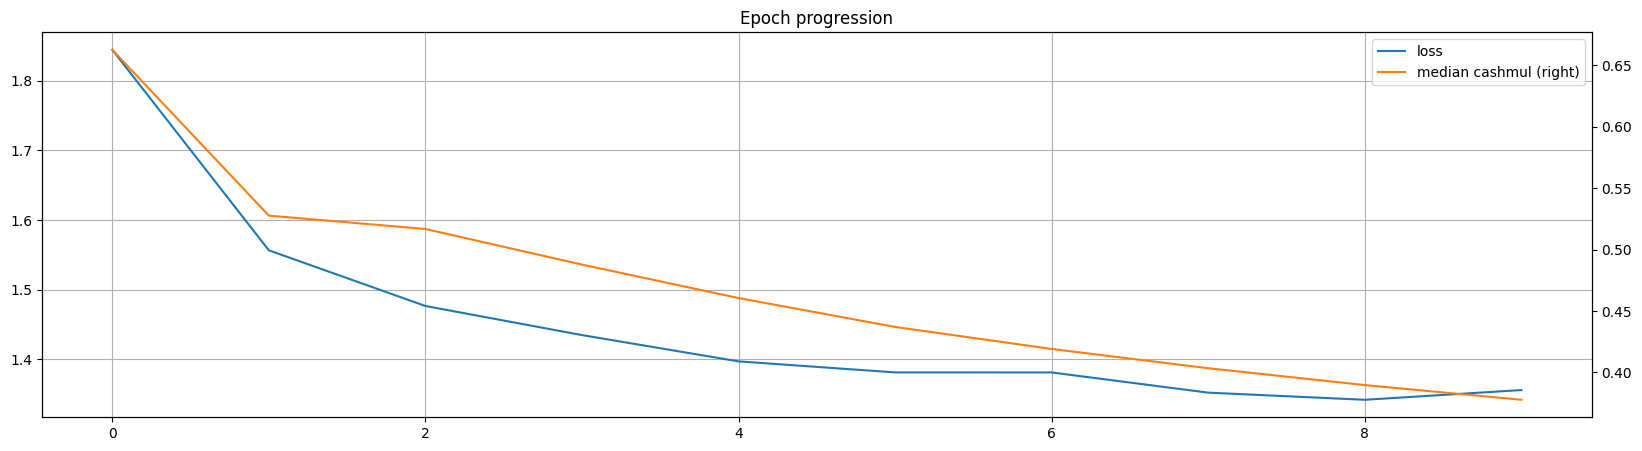

Assets  Liabilities  NetCashOperating_ttm     price  \
cik        snapshot                                                            
0000001750 2012-01-01  1.821612     0.957664              0.083588 19.170000   
           2012-02-01  1.821612     0.957664              0.083588 21.190000   
           2012-03-01  1.821612     0.957664              0.083588 22.050000   
           2012-04-01  2.220293     1.330213              0.066898 18.250000   
           2012-05-01  2.220293     1.330213              0.066898 15.450000   
...                         ...          ...                   ...       ...   
0001915657 2025-06-01 16.542000     7.355000              0.704000 36.130000   
           2025-07-01 16.542000     7.355000              0.704000 41.080000   
           2025-08-01 16.843000     7.561000              1.067000 43.940000   
           2025-09-01 16.843000     7.561000              1.067000 50.880000   
           2025-10-01 16.843000     7.561000              1.067000 52.340000   

                         asmul   cashmul     model  
cik        snapshot                                 
0000001750 2012-01-01 0.948083 -0.211073  0.751731  
           2012-02-01 0.962614 -0.212355  0.778095  
           2012-03-01 0.968515 -0.182063  0.791377  
           2012-04-01 0.939329 -0.197974  0.742128  
           2012-05-01 0.923252 -0.205088  0.705957  
...                        ...       ...       ...  
0001915657 2025-06-01 0.958188  0.519514  8.861078  
           2025-07-01 1.029361  0.565781 10.071000  
           2025-08-01 1.052304  0.574249 10.775682  
           2025-09-01 1.151092  0.611831 12.479673  
           2025-10-01 1.171151  0.624741 12.831292  

[435085 rows x 7 columns]

In [13]:
model_train(pricing_model)
model_output = pricing_model.get_df()
model_output = model_output[~model_output['is_created']].drop(columns=['is_created'])
model_output

In [14]:
# We take the computed multipliers and put them into the original dataframe "snapshots"
mul_columns = ['asmul','cashmul']
result = pd.merge(snapshots,model_output.groupby(by=['snapshot','cik'])[mul_columns].mean(),left_index=True,right_index=True,how='left')
result['model'] = result['asmul']*result['Assets'] - result['Liabilities'] + result['cashmul']*result['NetCashOperating_ttm']
# Sample data: Amazon
result[result['ticker']=='AMZN'].tail(20)

,,,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model
snapshot,cik,date,,,,,,,,
2024-05-01,0001018724,2023-12-31,AMZN,527.854000,325.979000,133.367167,175.000000,0.788254,0.395184,142.808429
2024-06-01,0001018724,2024-03-31,AMZN,530.969000,314.308000,159.120667,176.440000,0.729892,0.443324,143.784373
2024-07-01,0001018724,2024-03-31,AMZN,530.969000,314.308000,159.120667,193.250000,0.754439,0.450131,157.900567
2024-08-01,0001018724,2024-03-31,AMZN,530.969000,314.308000,159.120667,186.980000,0.732941,0.488658,152.616425
2024-09-01,0001018724,2024-06-30,AMZN,554.818000,318.371000,177.090000,178.500000,0.673102,0.510440,145.471999
2024-10-01,0001018724,2024-06-30,AMZN,554.818000,318.371000,177.090000,186.330000,0.674930,0.541734,152.027912
2024-11-01,0001018724,2024-06-30,AMZN,554.818000,318.371000,177.090000,186.400000,0.681300,0.522813,152.211584
2024-12-01,0001018724,2024-09-30,AMZN,584.626000,325.475000,193.943333,207.890000,0.650593,0.592542,169.797933
2025-01-01,0001018724,2024-09-30,AMZN,584.626000,325.475000,193.943333,219.390000,0.697564,0.500540,179.415605


In [15]:
# Let's see for how many ciks the achieved correlation is perfect and for how many it is not.
model_corr = result.dropna().groupby(by='cik')[[ml_label,'model']].corr().reset_index()
model_corr = model_corr[model_corr[model_corr.columns[1]]==ml_label][['cik','model']].rename(columns={'model':'corrcoef'}).set_index('cik')
model_corr.sort_values(by='corrcoef').round(3).value_counts()

corrcoef
1.000000    3429
0.999000       7
Name: count, dtype: int64

It is interesting to see the development of the two multipliers over time. The cash multiplier is the same for all ciks on a given snapshot date and can probably serve as some form of valuation metric for the whole market.

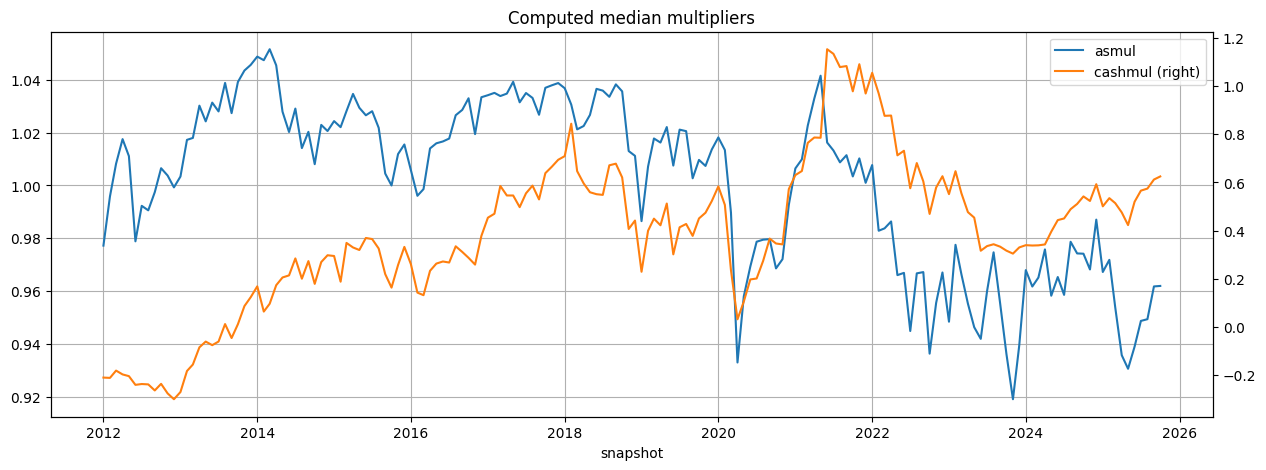

Median asset_multiplier per cik: 0.9955250024795532
Median asset_multiplier per snapshot: 1.0097662210464478


In [16]:
mul_graph = result.groupby(by='snapshot')[mul_columns].median()
mul_graph['asmul'].plot(title='Computed median multipliers',figsize=(15,5),grid=True,legend=True)
mul_graph['cashmul'].plot(secondary_y=True,legend=True,grid=False)
plt.show()
print("Median asset_multiplier per cik:",result['asmul'].groupby(by=['cik']).median().median())
print("Median asset_multiplier per snapshot:",result['asmul'].groupby(by=['snapshot']).median().median())

We can now output the results for later use in other models/notebooks/datasets

In [17]:
result.to_csv('/kaggle/working/pricing_model.csv.gz')

Finally, we apply the model to individual companies. We have tried to make the selection of sample tickers as varied as possible in terms of company kinds and sizes. By following the development of the asset_multiplier of each company over time, we can make some estimates if and how much the stock price corresponds to the financial fundamentals.

In other words, we may be able to determine if a stock is relatively over-or-undervalued, compared to its historic fundamentals.

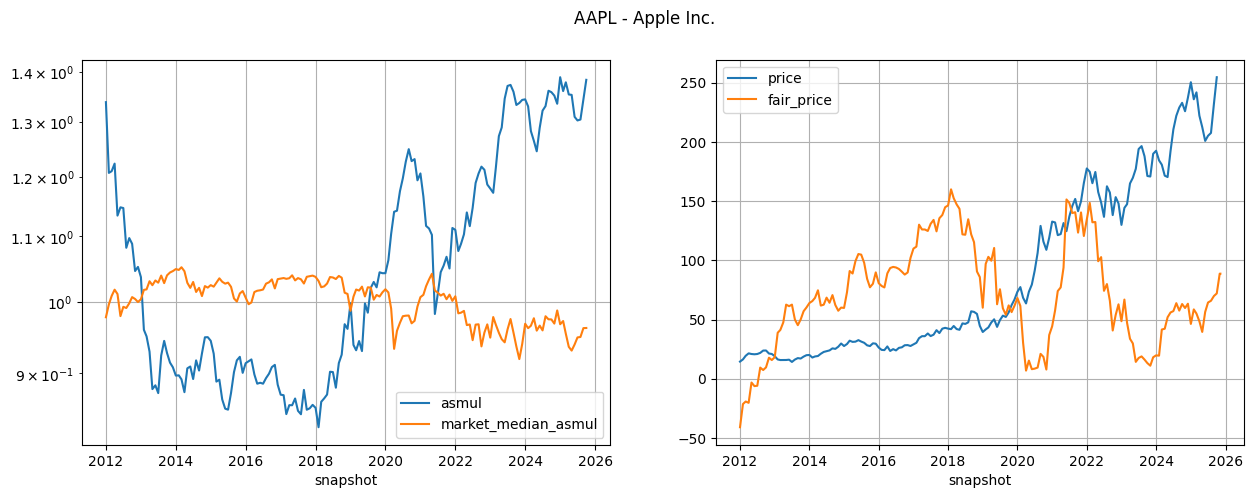

Apple Inc. stock pricing model:
AAPL fair_price = 1.5693 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -154.7598


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000320193,2025-03-29,AAPL,331.233000,264.437000,109.556000,0.574249,1.032749,140.555864,65.817573
2025-09-01,0000320193,2025-06-28,AAPL,331.495000,265.665000,108.565000,0.611831,1.032749,143.109451,69.824973
2025-10-01,0000320193,2025-06-28,AAPL,331.495000,265.665000,108.565000,0.624741,1.032749,144.511123,72.024647
2025-11-01,0000320193,2025-09-27,AAPL,359.241000,285.508000,111.482000,0.624741,1.032749,155.145143,88.712843
2025-11-08,0000320193,2025-09-27,AAPL,359.241000,285.508000,111.482000,0.624741,1.032749,155.145143,88.712843


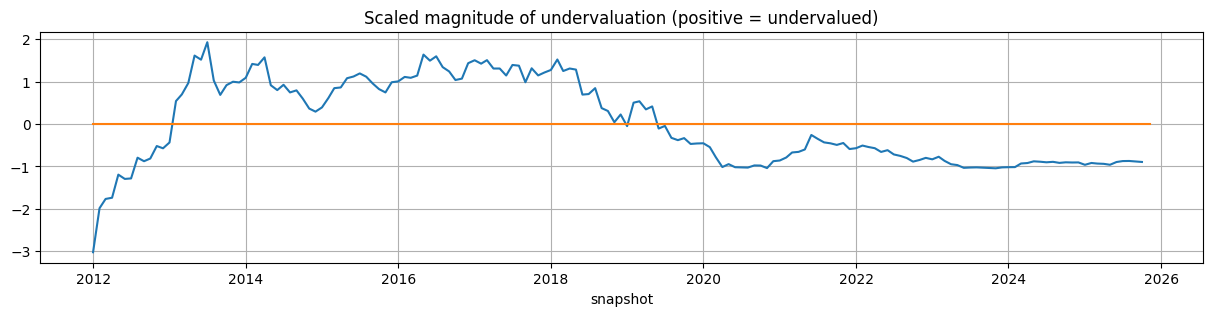

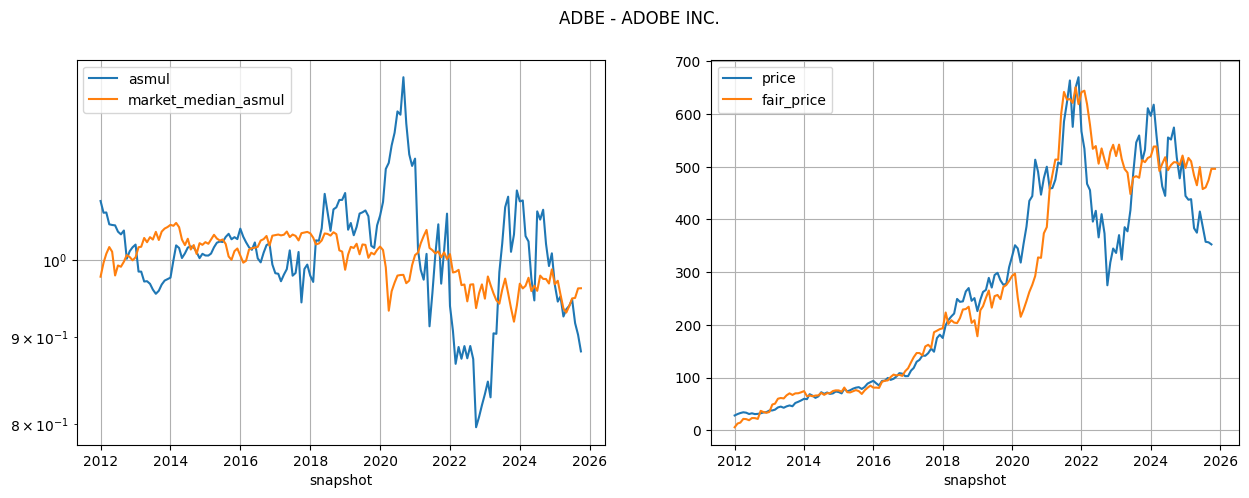

ADOBE INC. stock pricing model:
ADBE fair_price = 38.0349 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -199.1525


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000796343,2025-05-30,ADBE,28.107000,16.659000,9.615000,0.574249,1.013603,17.351752,460.820264
2025-09-01,0000796343,2025-05-30,ADBE,28.107000,16.659000,9.615000,0.611831,1.013603,17.713103,474.564215
2025-10-01,0000796343,2025-08-29,ADBE,28.754000,16.984000,9.792000,0.624741,1.013603,18.278622,496.073693
2025-11-01,0000796343,2025-08-29,ADBE,28.754000,16.984000,9.792000,0.624741,1.013603,18.278622,496.073693
2025-11-08,0000796343,2025-08-29,ADBE,28.754000,16.984000,9.792000,0.624741,1.013603,18.278622,496.073693


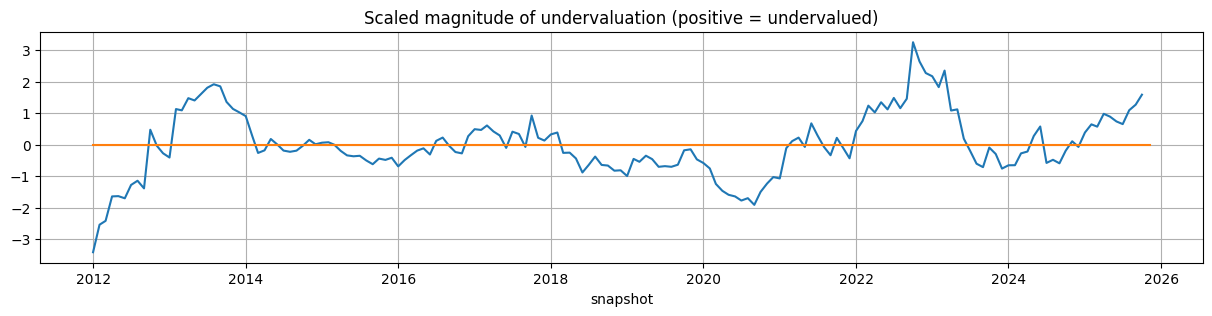

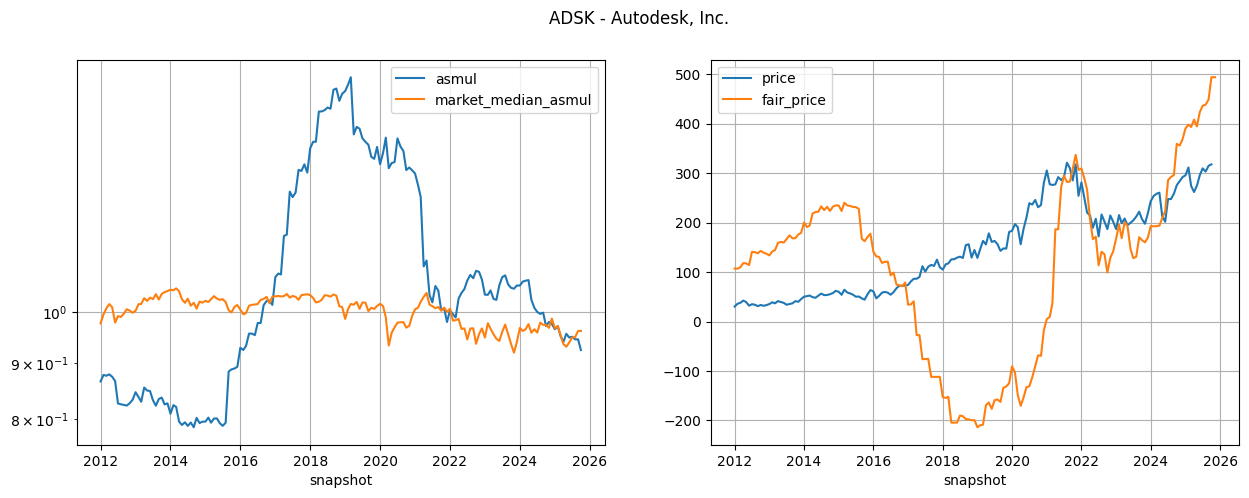

Autodesk, Inc. stock pricing model:
ADSK fair_price = 160.9702 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -179.384


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000769397,2025-04-30,ADSK,10.585000,7.968000,1.677000,0.574249,1.024368,3.837946,438.410734
2025-09-01,0000769397,2025-04-30,ADSK,10.585000,7.968000,1.677000,0.611831,1.024368,3.900971,448.555877
2025-10-01,0000769397,2025-07-31,ADSK,10.856000,8.141000,1.925000,0.624741,1.024368,4.182162,493.819252
2025-11-01,0000769397,2025-07-31,ADSK,10.856000,8.141000,1.925000,0.624741,1.024368,4.182162,493.819252
2025-11-08,0000769397,2025-07-31,ADSK,10.856000,8.141000,1.925000,0.624741,1.024368,4.182162,493.819252


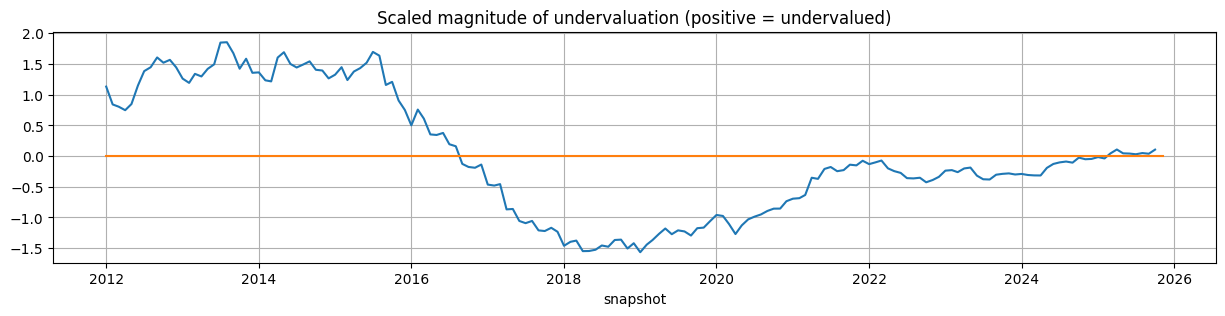

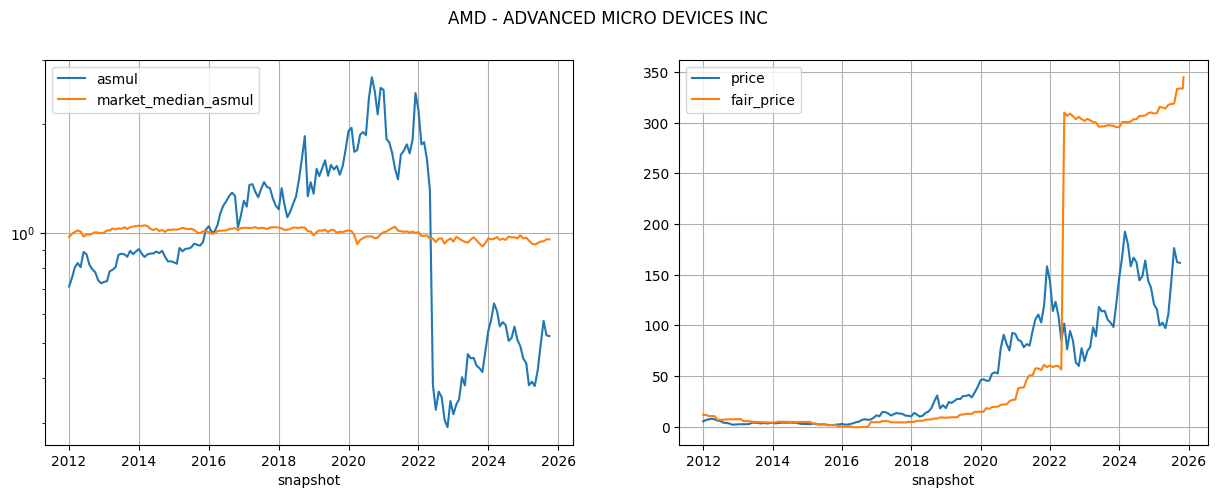

ADVANCED MICRO DEVICES INC stock pricing model:
AMD fair_price = 5.87 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 4.2302


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000002488,2025-03-29,AMD,71.550000,13.669000,3.459000,0.574249,0.912126,53.579963,318.742851
2025-09-01,0000002488,2025-06-28,AMD,74.820000,15.155000,4.877000,0.611831,0.912126,56.074187,333.383869
2025-10-01,0000002488,2025-06-28,AMD,74.820000,15.155000,4.877000,0.624741,0.912126,56.137154,333.753480
2025-11-01,0000002488,2025-06-28,AMD,74.820000,15.155000,4.877000,0.624741,0.912126,56.137154,333.753480
2025-11-08,0000002488,2025-09-27,AMD,76.891000,16.101000,6.408000,0.624741,0.912126,58.036647,344.903441


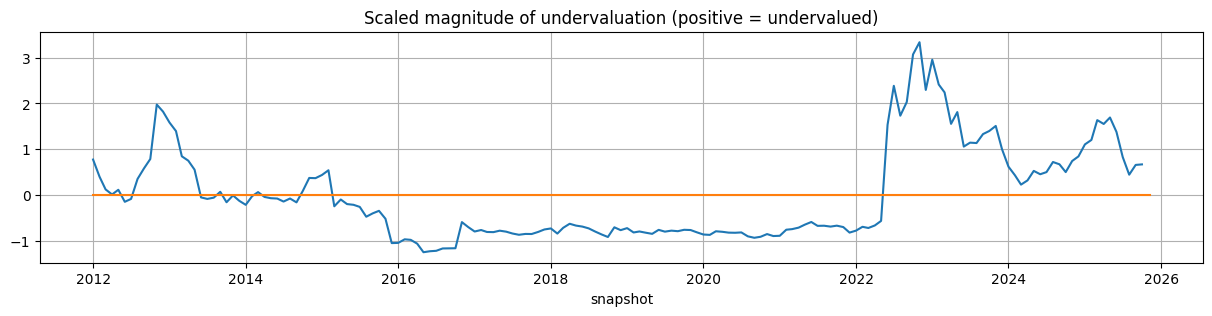

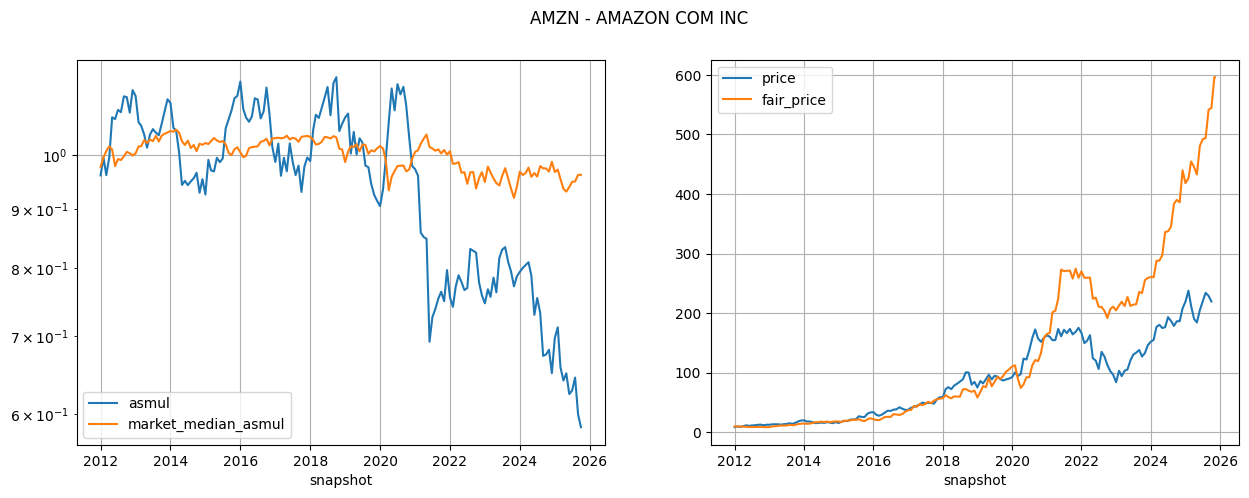

AMAZON COM INC stock pricing model:
AMZN fair_price = 1.208 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 2.5115


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001018724,2025-03-31,AMZN,643.256000,337.389000,199.102833,0.574249,0.979240,406.847634,493.995787
2025-09-01,0001018724,2025-06-30,AMZN,682.170000,348.395000,206.735833,0.611831,0.979240,446.100568,541.414525
2025-10-01,0001018724,2025-06-30,AMZN,682.170000,348.395000,206.735833,0.624741,0.979240,448.769714,544.638934
2025-11-01,0001018724,2025-09-30,AMZN,727.921000,358.290000,219.100167,0.624741,0.979240,491.400443,596.138151
2025-11-08,0001018724,2025-09-30,AMZN,727.921000,358.290000,219.100167,0.624741,0.979240,491.400443,596.138151


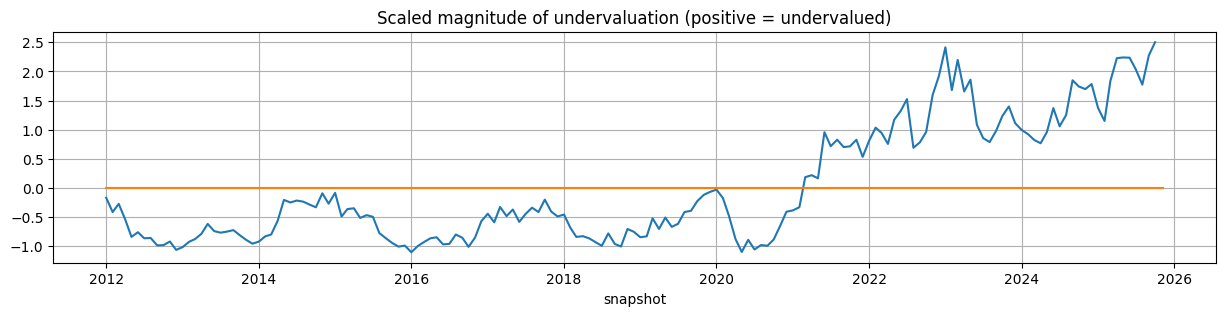

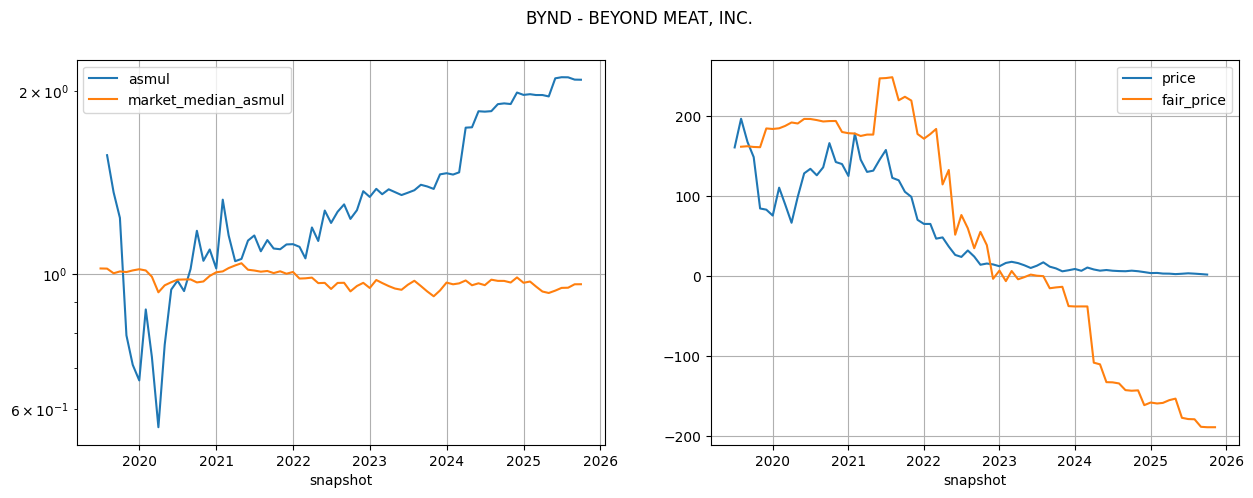

BEYOND MEAT, INC. stock pricing model:
BYND fair_price = 362.1944 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 0.1195


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001655210,2025-03-29,BYND,0.643830,1.293361,-0.093154,0.574249,1.324641,-0.494011,-178.808553
2025-09-01,0001655210,2025-06-28,BYND,0.691741,1.368764,-0.110354,0.611831,1.324641,-0.519974,-188.212040
2025-10-01,0001655210,2025-06-28,BYND,0.691741,1.368764,-0.110354,0.624741,1.324641,-0.521399,-188.728084
2025-11-01,0001655210,2025-06-28,BYND,0.691741,1.368764,-0.110354,0.624741,1.324641,-0.521399,-188.728084
2025-11-08,0001655210,2025-06-28,BYND,0.691741,1.368764,-0.110354,0.624741,1.324641,-0.521399,-188.728084


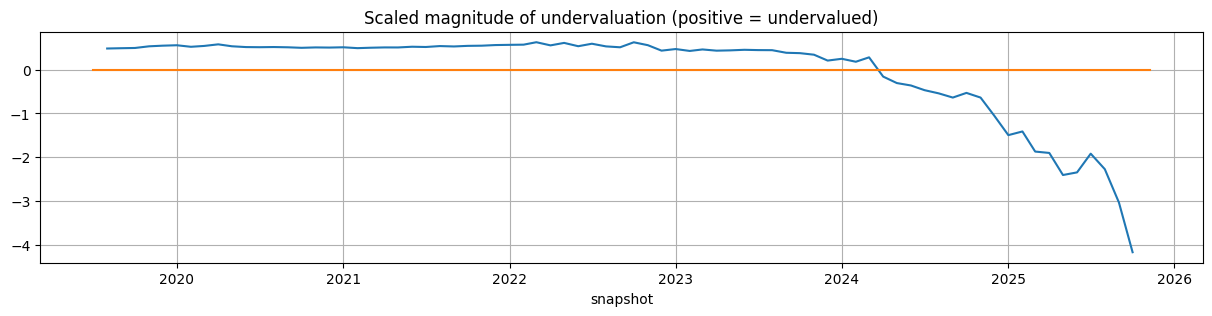

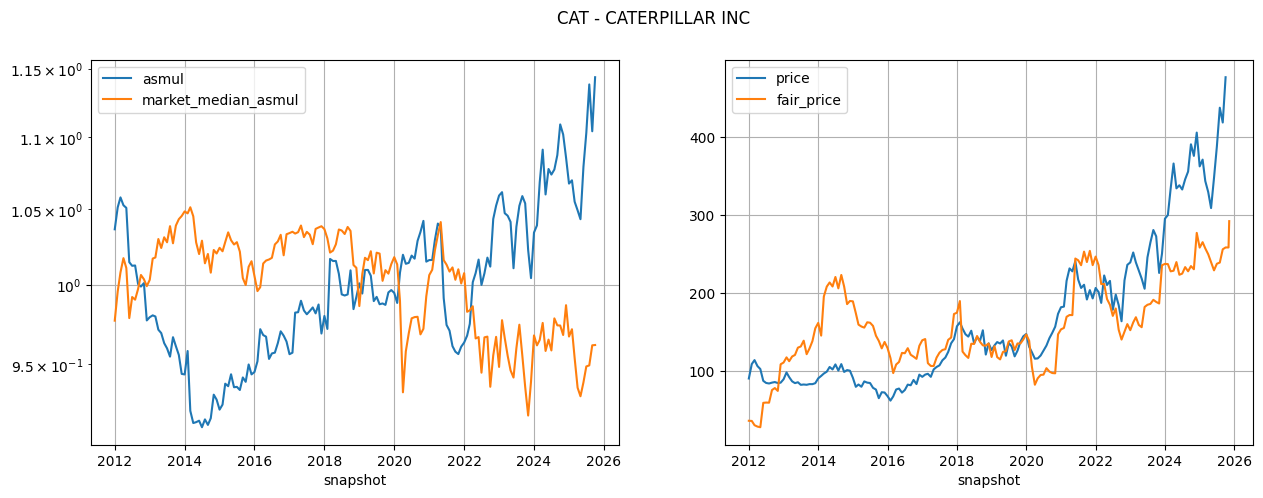

CATERPILLAR INC stock pricing model:
CAT fair_price = 16.2296 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -150.6182


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000018230,2025-03-31,CAT,84.974000,66.904000,11.272000,0.574249,0.993963,24.029972,239.378049
2025-09-01,0000018230,2025-06-30,CAT,90.325000,71.662000,11.373000,0.611831,0.993963,25.076089,256.356082
2025-10-01,0000018230,2025-06-30,CAT,90.325000,71.662000,11.373000,0.624741,0.993963,25.222925,258.739163
2025-11-01,0000018230,2025-06-30,CAT,90.325000,71.662000,11.373000,0.624741,0.993963,25.222925,258.739163
2025-11-08,0000018230,2025-09-30,CAT,93.722000,73.063000,11.541000,0.624741,0.993963,27.303375,292.503983


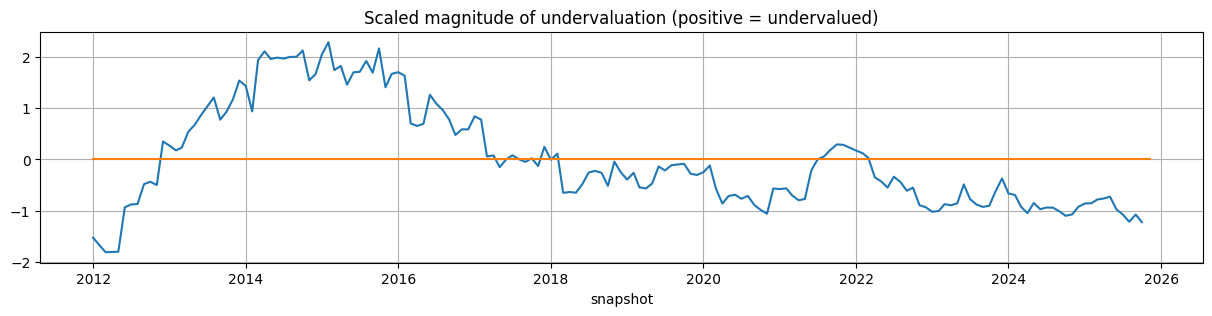

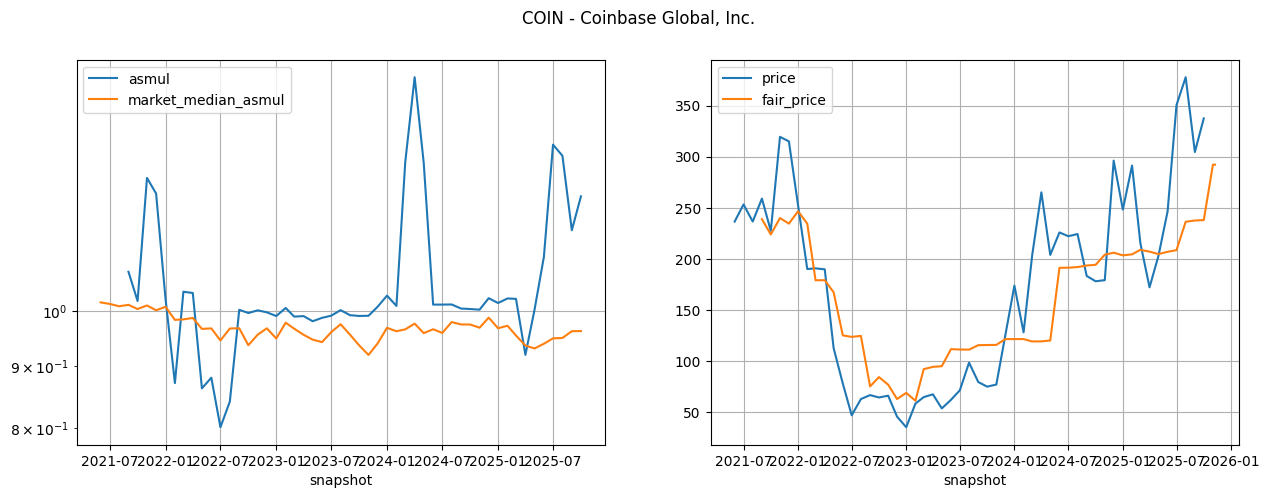

Coinbase Global, Inc. stock pricing model:
COIN fair_price = 17.7515 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 0.5204


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001679788,2025-06-30,COIN,23.476038,11.381149,1.806909,0.574249,1.006585,13.287102,236.385858
2025-09-01,0001679788,2025-06-30,COIN,23.476038,11.381149,1.806909,0.611831,1.006585,13.355009,237.591311
2025-10-01,0001679788,2025-06-30,COIN,23.476038,11.381149,1.806909,0.624741,1.006585,13.378338,238.005432
2025-11-01,0001679788,2025-09-30,COIN,31.351367,15.328143,0.325850,0.624741,1.006585,16.433256,292.234690
2025-11-08,0001679788,2025-09-30,COIN,31.351367,15.328143,0.325850,0.624741,1.006585,16.433256,292.234690


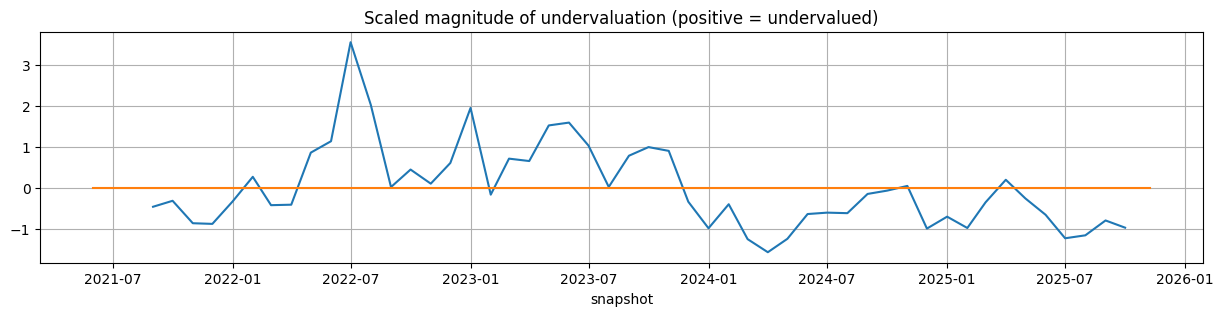

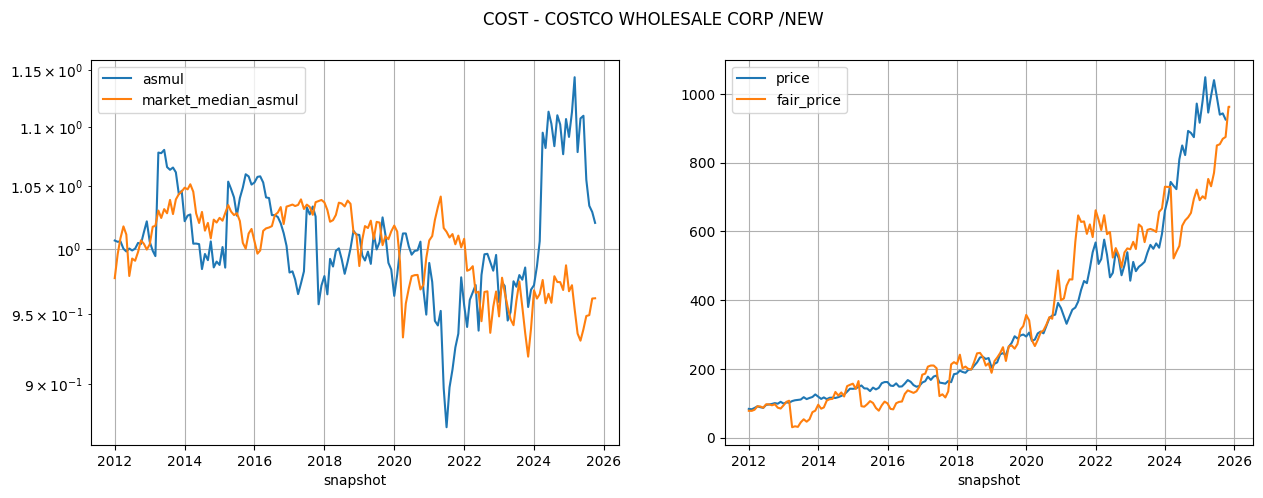

COSTCO WHOLESALE CORP /NEW stock pricing model:
COST fair_price = 33.6982 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -301.2713


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000909832,2025-05-11,COST,75.482000,48.357000,12.426000,0.574249,1.000122,34.269818,853.558618
2025-09-01,0000909832,2025-05-11,COST,75.482000,48.357000,12.426000,0.611831,1.000122,34.736811,869.295447
2025-10-01,0000909832,2025-05-11,COST,75.482000,48.357000,12.426000,0.624741,1.000122,34.897242,874.701673
2025-11-01,0000909832,2025-08-31,COST,77.099000,47.935000,13.335000,0.624741,1.000122,37.504329,962.555725
2025-11-08,0000909832,2025-08-31,COST,77.099000,47.935000,13.335000,0.624741,1.000122,37.504329,962.555725


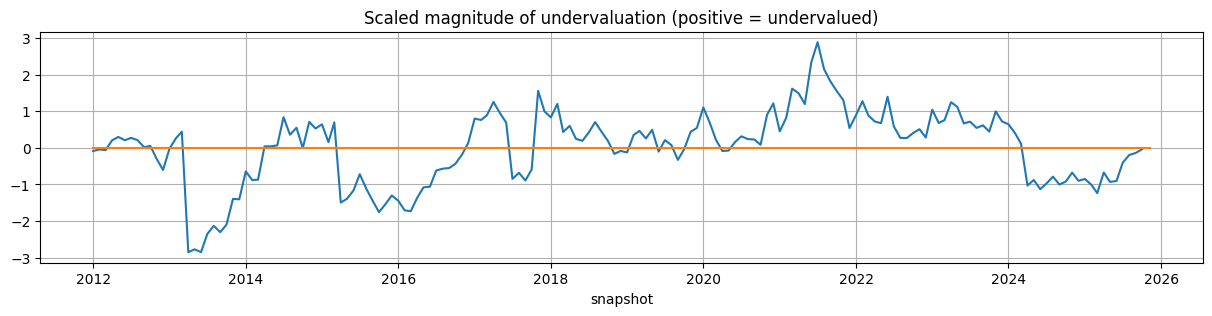

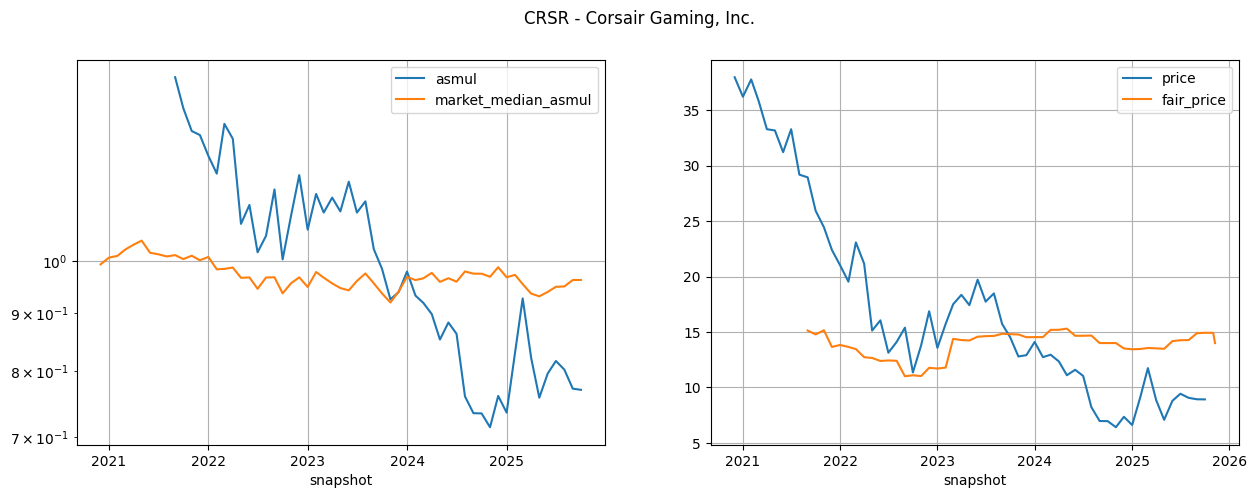

Corsair Gaming, Inc. stock pricing model:
CRSR fair_price = 22.0457 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 0.0065


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001743759,2025-03-31,CRSR,1.239457,0.630700,0.080944,0.574249,0.993404,0.647063,14.271437
2025-09-01,0001743759,2025-06-30,CRSR,1.221880,0.617983,0.129599,0.611831,0.993404,0.675130,14.890185
2025-10-01,0001743759,2025-06-30,CRSR,1.221880,0.617983,0.129599,0.624741,0.993404,0.676803,14.927073
2025-11-01,0001743759,2025-06-30,CRSR,1.221880,0.617983,0.129599,0.624741,0.993404,0.676803,14.927073
2025-11-08,0001743759,2025-09-30,CRSR,1.198499,0.598269,0.067507,0.624741,0.993404,0.634499,13.994446


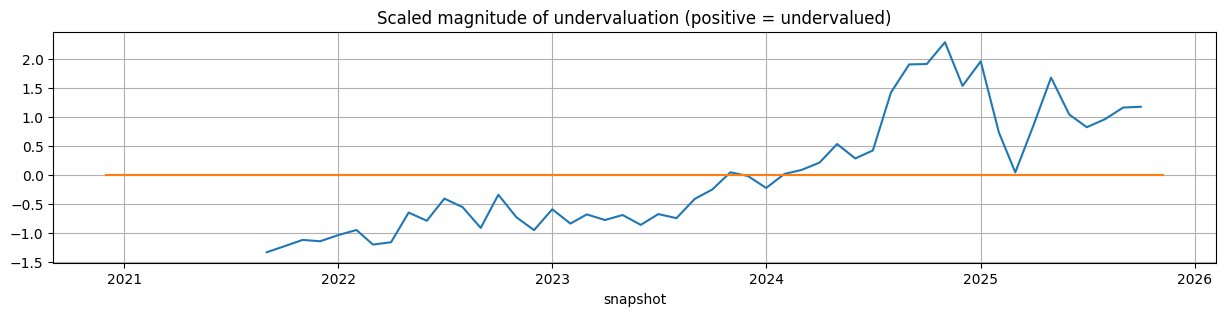

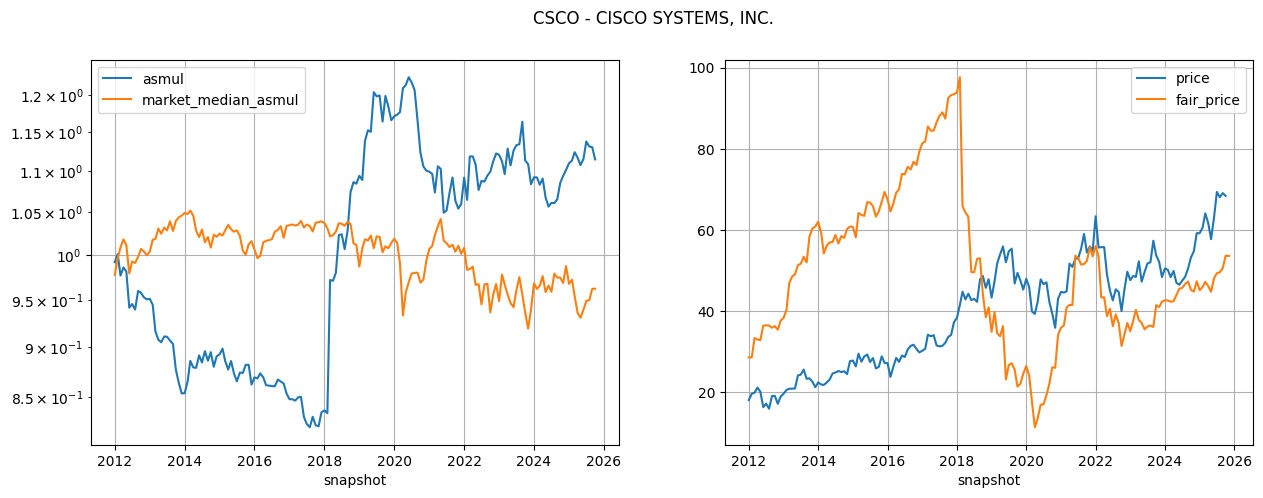

CISCO SYSTEMS, INC. stock pricing model:
CSCO fair_price = 1.9767 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -69.2493


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000858877,2025-04-26,CSCO,119.782000,73.847000,13.689000,0.574249,1.052720,60.110832,49.574674
2025-09-01,0000858877,2025-04-26,CSCO,119.782000,73.847000,13.689000,0.611831,1.052720,60.625292,50.591631
2025-10-01,0000858877,2025-07-26,CSCO,122.291000,75.448000,14.193000,0.624741,1.052720,62.157174,53.619776
2025-11-01,0000858877,2025-07-26,CSCO,122.291000,75.448000,14.193000,0.624741,1.052720,62.157174,53.619776
2025-11-08,0000858877,2025-07-26,CSCO,122.291000,75.448000,14.193000,0.624741,1.052720,62.157174,53.619776


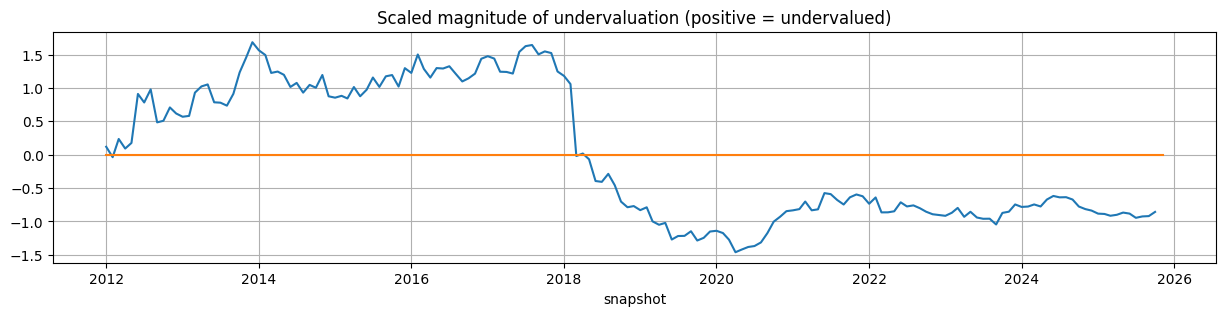

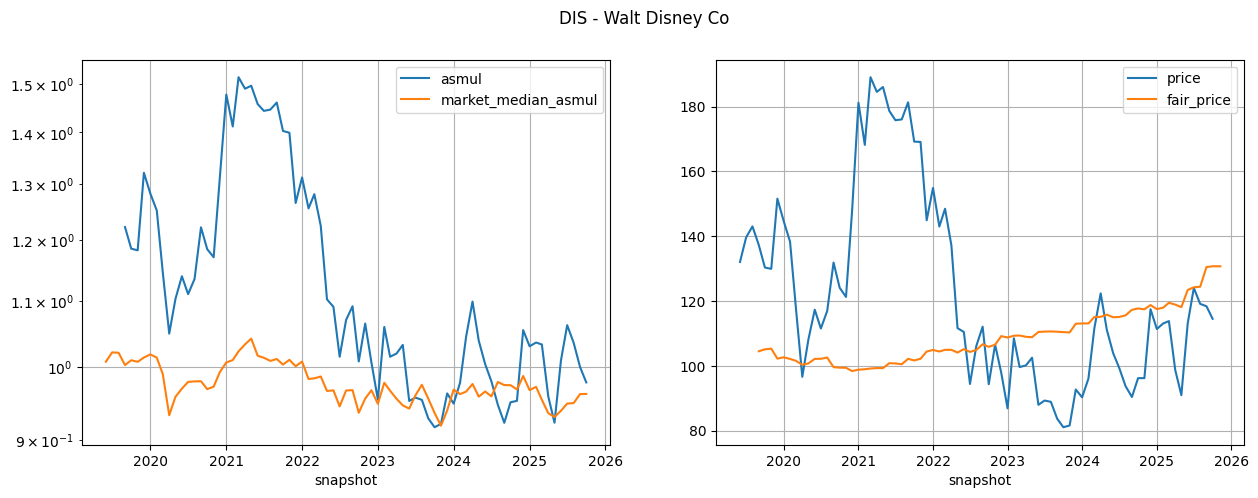

Walt Disney Co stock pricing model:
DIS fair_price = 0.9843 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -0.6829


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001744489,2025-03-29,DIS,195.833000,91.494000,18.078000,0.574249,1.062965,127.050804,124.378021
2025-09-01,0001744489,2025-06-28,DIS,196.612000,87.467000,19.145000,0.611831,1.062965,133.238083,130.468395
2025-10-01,0001744489,2025-06-28,DIS,196.612000,87.467000,19.145000,0.624741,1.062965,133.485263,130.711703
2025-11-01,0001744489,2025-06-28,DIS,196.612000,87.467000,19.145000,0.624741,1.062965,133.485263,130.711703
2025-11-08,0001744489,2025-06-28,DIS,196.612000,87.467000,19.145000,0.624741,1.062965,133.485263,130.711703


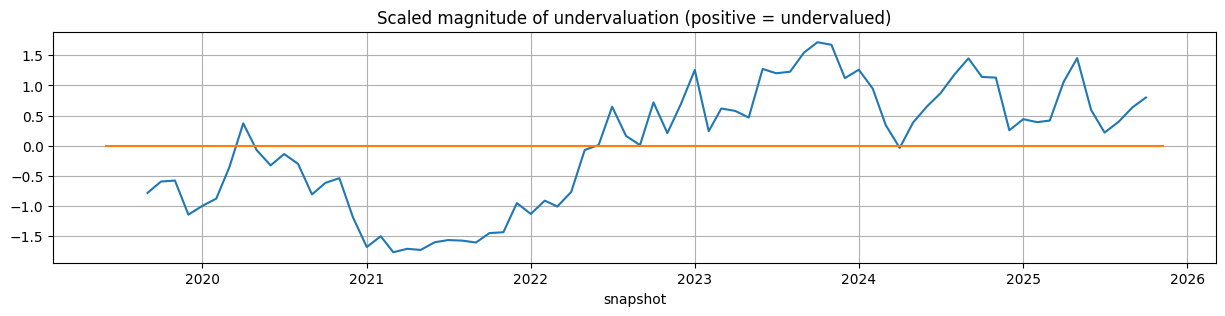

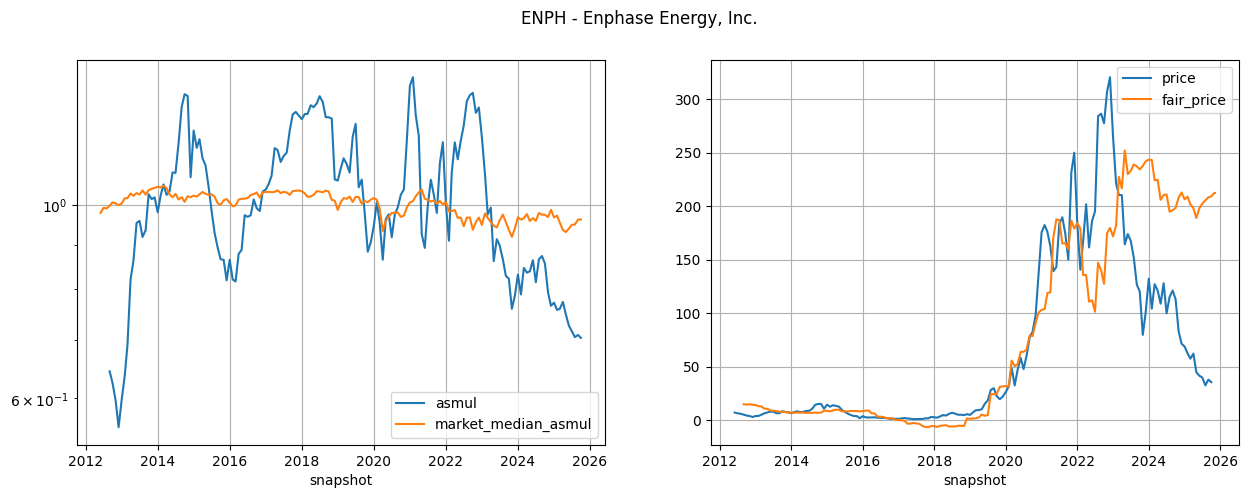

Enphase Energy, Inc. stock pricing model:
ENPH fair_price = 181.9154 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -0.5279


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001463101,2025-06-30,ENPH,3.178789,2.298152,0.412473,0.574249,1.004571,1.132030,205.405630
2025-09-01,0001463101,2025-06-30,ENPH,3.178789,2.298152,0.412473,0.611831,1.004571,1.147531,208.225600
2025-10-01,0001463101,2025-06-30,ENPH,3.178789,2.298152,0.412473,0.624741,1.004571,1.152856,209.194372
2025-11-01,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.624741,1.004571,1.170292,212.366178
2025-11-08,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.624741,1.004571,1.170292,212.366178


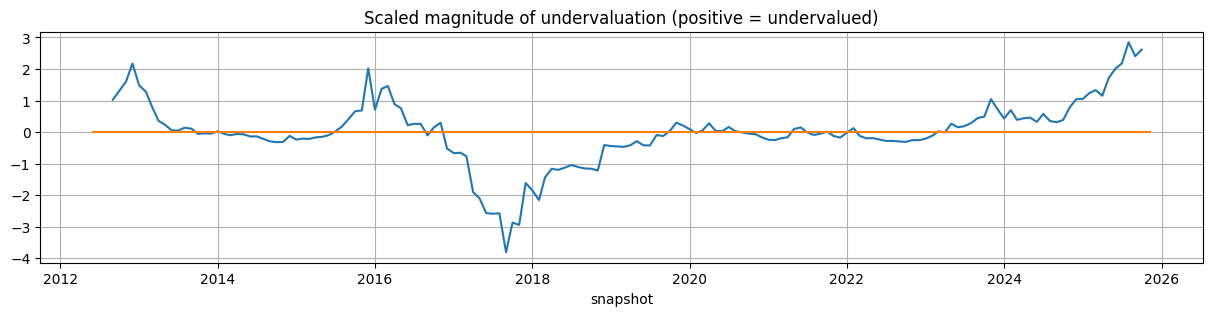

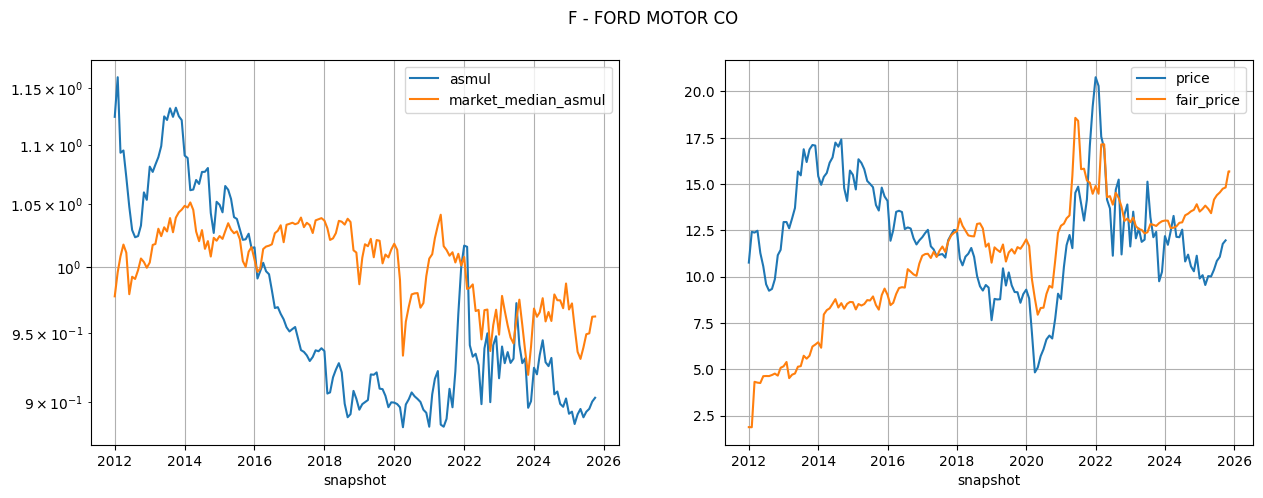

FORD MOTOR CO stock pricing model:
F fair_price = 0.2898 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 3.8612


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000037996,2025-06-30,F,292.725000,247.668000,18.526000,0.574249,0.935701,36.873642,14.546943
2025-09-01,0000037996,2025-06-30,F,292.725000,247.668000,18.526000,0.611831,0.935701,37.569886,14.748709
2025-10-01,0000037996,2025-06-30,F,292.725000,247.668000,18.526000,0.624741,0.935701,37.809074,14.818024
2025-11-01,0000037996,2025-09-30,F,300.990000,253.598000,20.426000,0.624741,0.935701,40.799652,15.684671
2025-11-08,0000037996,2025-09-30,F,300.990000,253.598000,20.426000,0.624741,0.935701,40.799652,15.684671


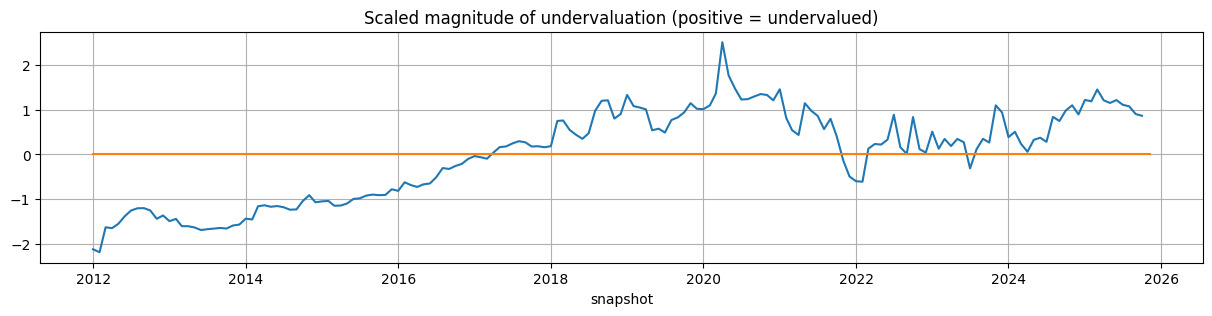

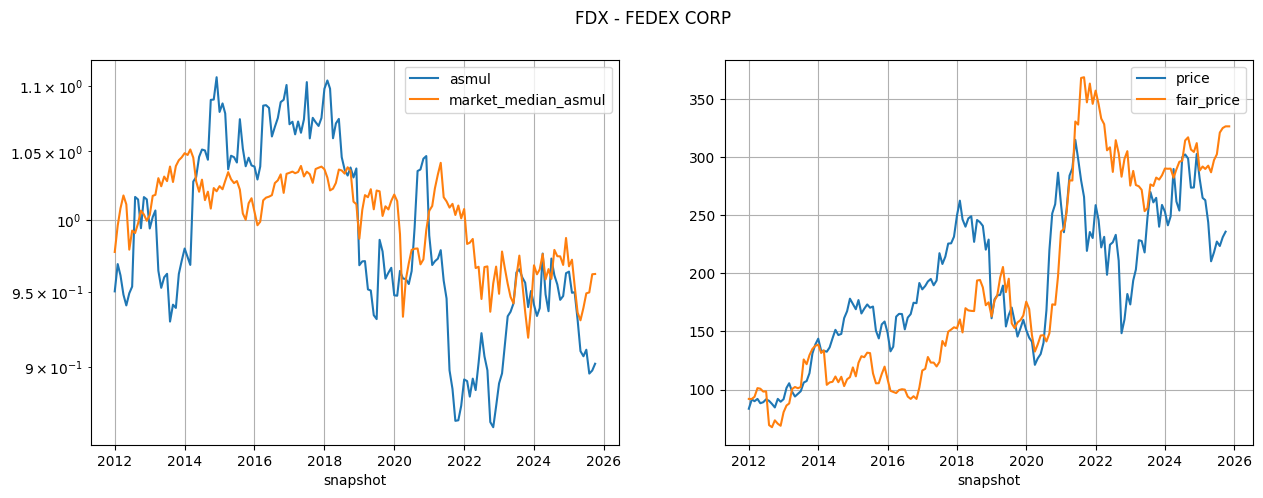

FEDEX CORP stock pricing model:
FDX fair_price = 14.9774 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -120.2772


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001048911,2025-05-31,FDX,87.627000,59.553000,7.036000,0.574249,0.969775,29.465925,321.046943
2025-09-01,0001048911,2025-05-31,FDX,87.627000,59.553000,7.036000,0.611831,0.969775,29.730352,325.007381
2025-10-01,0001048911,2025-08-31,FDX,88.416000,60.645000,7.565000,0.624741,0.969775,29.824834,326.422481
2025-11-01,0001048911,2025-08-31,FDX,88.416000,60.645000,7.565000,0.624741,0.969775,29.824834,326.422481
2025-11-08,0001048911,2025-08-31,FDX,88.416000,60.645000,7.565000,0.624741,0.969775,29.824834,326.422481


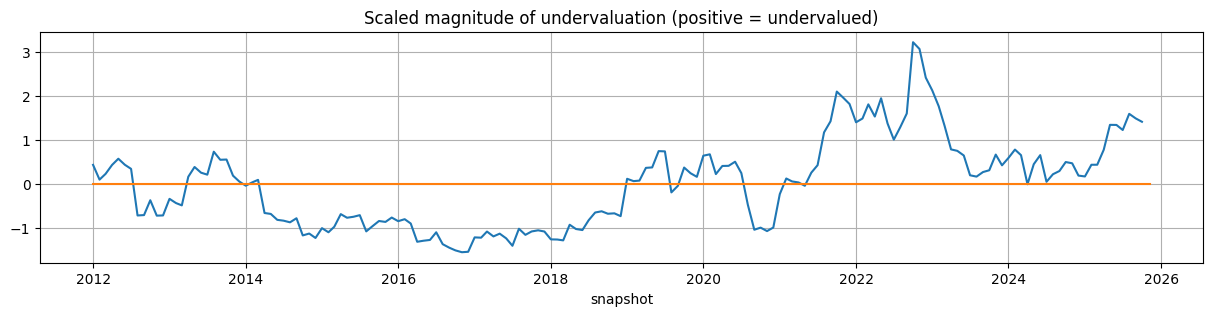

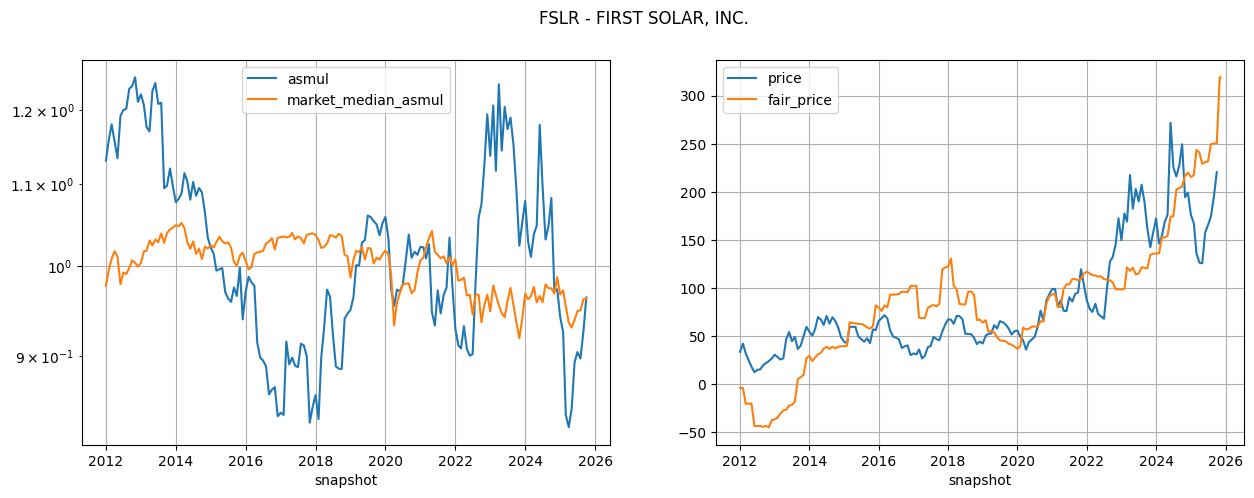

FIRST SOLAR, INC. stock pricing model:
FSLR fair_price = 52.6741 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -214.6968


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001274494,2025-06-30,FSLR,12.858044,4.311914,0.298857,0.574249,1.007662,8.816263,249.691959
2025-09-01,0001274494,2025-06-30,FSLR,12.858044,4.311914,0.298857,0.611831,1.007662,8.827494,250.283576
2025-10-01,0001274494,2025-06-30,FSLR,12.858044,4.311914,0.298857,0.624741,1.007662,8.831353,250.486820
2025-11-01,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,0.624741,1.007662,10.134393,319.123288
2025-11-08,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,0.624741,1.007662,10.134393,319.123288


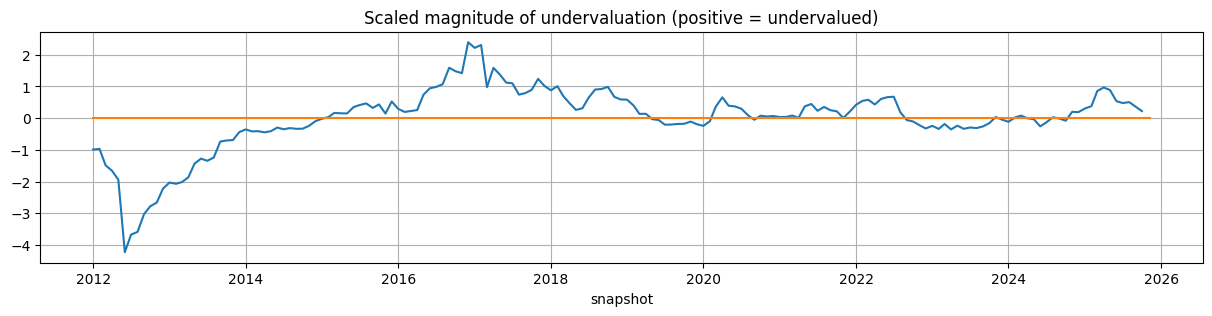

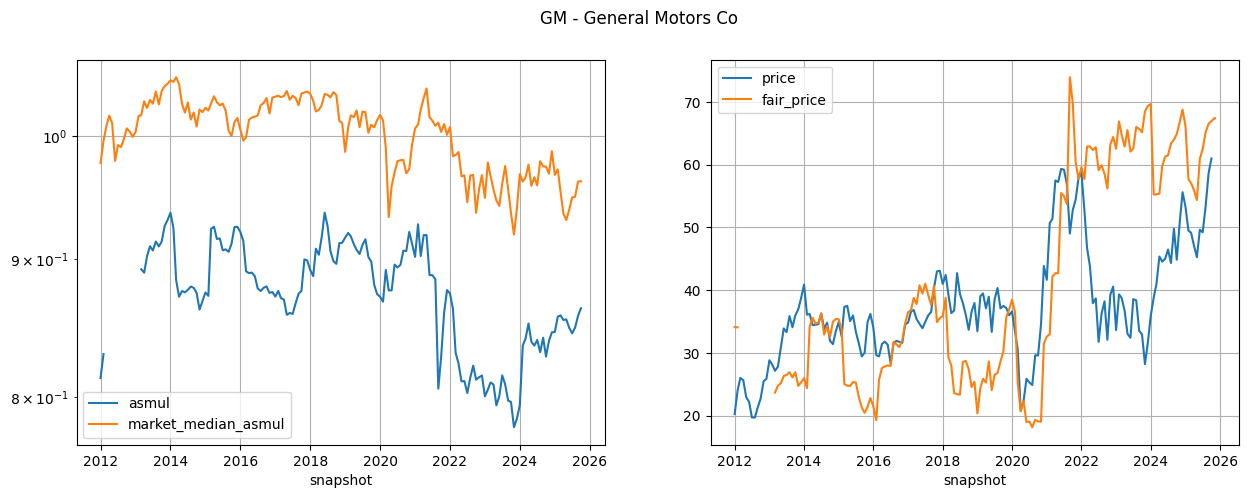

General Motors Co stock pricing model:
GM fair_price = 1.4674 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 0.0216


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001467858,2025-06-30,GM,289.384000,223.021000,23.970000,0.574249,0.876462,44.377760,65.142422
2025-09-01,0001467858,2025-06-30,GM,289.384000,223.021000,23.970000,0.611831,0.876462,45.278601,66.464333
2025-10-01,0001467858,2025-06-30,GM,289.384000,223.021000,23.970000,0.624741,0.876462,45.588075,66.918462
2025-11-01,0001467858,2025-09-30,GM,288.168000,221.794000,24.212000,0.624741,0.876462,45.900485,67.376898
2025-11-08,0001467858,2025-09-30,GM,288.168000,221.794000,24.212000,0.624741,0.876462,45.900485,67.376898


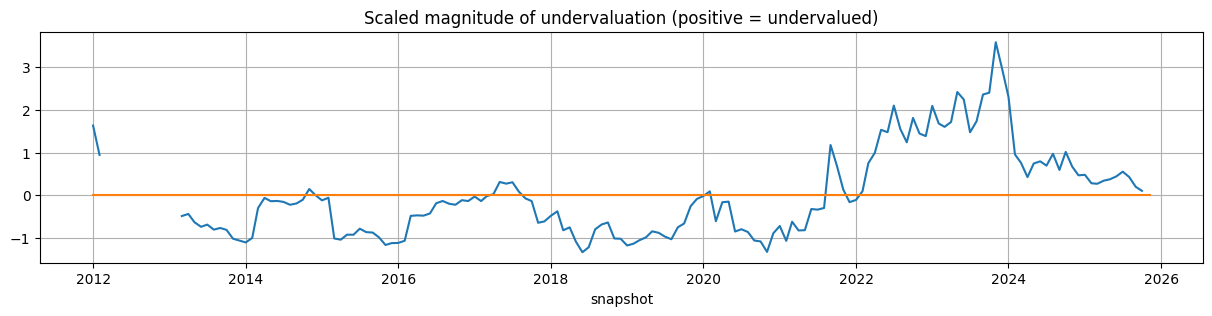

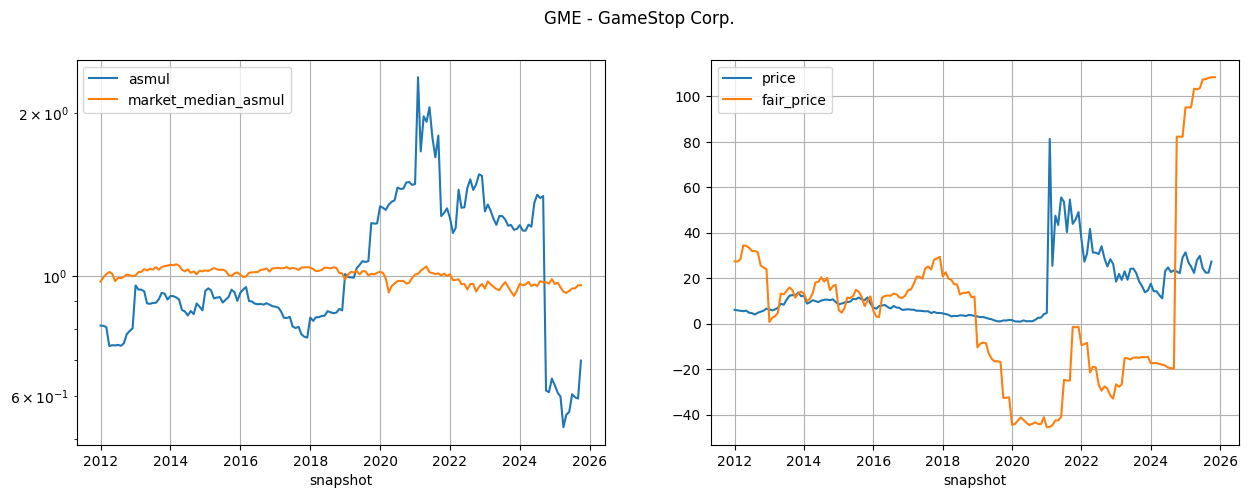

GameStop Corp. stock pricing model:
GME fair_price = 34.7025 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -54.5642


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001326380,2025-05-03,GME,7.502600,2.515200,0.448000,0.574249,0.923504,4.670743,107.522061
2025-09-01,0001326380,2025-05-03,GME,7.502600,2.515200,0.448000,0.611831,0.923504,4.687579,108.106337
2025-10-01,0001326380,2025-08-02,GME,10.341100,5.164700,0.496800,0.624741,0.923504,4.695716,108.388707
2025-11-01,0001326380,2025-08-02,GME,10.341100,5.164700,0.496800,0.624741,0.923504,4.695716,108.388707
2025-11-08,0001326380,2025-08-02,GME,10.341100,5.164700,0.496800,0.624741,0.923504,4.695716,108.388707


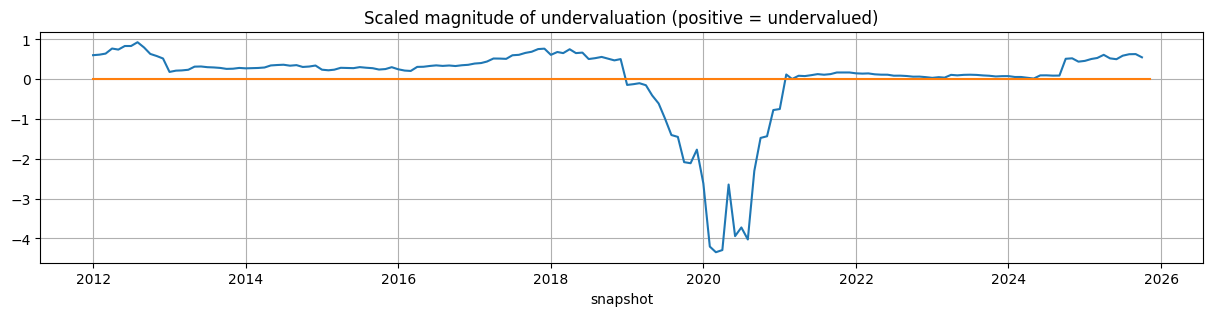

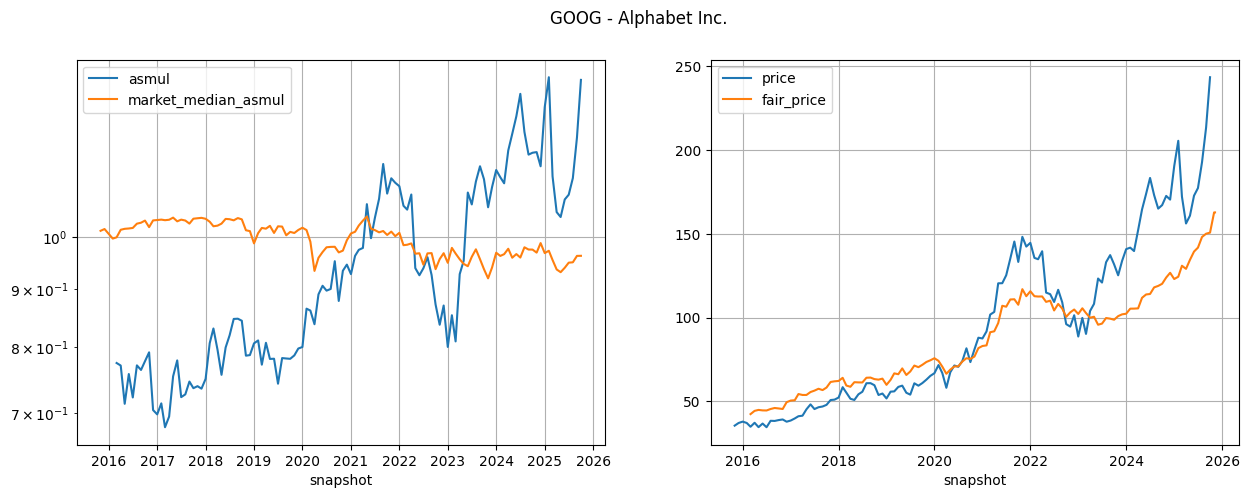

Alphabet Inc. stock pricing model:
GOOG fair_price = 0.3846 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -0.2936


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001652044,2025-06-30,GOOG,502.053000,139.137000,133.708000,0.574249,0.893208,386.082156,148.187873
2025-09-01,0001652044,2025-06-30,GOOG,502.053000,139.137000,133.708000,0.611831,0.893208,391.107167,150.120418
2025-10-01,0001652044,2025-06-30,GOOG,502.053000,139.137000,133.708000,0.624741,0.893208,392.833458,150.784325
2025-11-01,0001652044,2025-09-30,GOOG,536.469000,149.602000,151.424000,0.624741,0.893208,424.177008,162.838593
2025-11-08,0001652044,2025-09-30,GOOG,536.469000,149.602000,151.424000,0.624741,0.893208,424.177008,162.838593


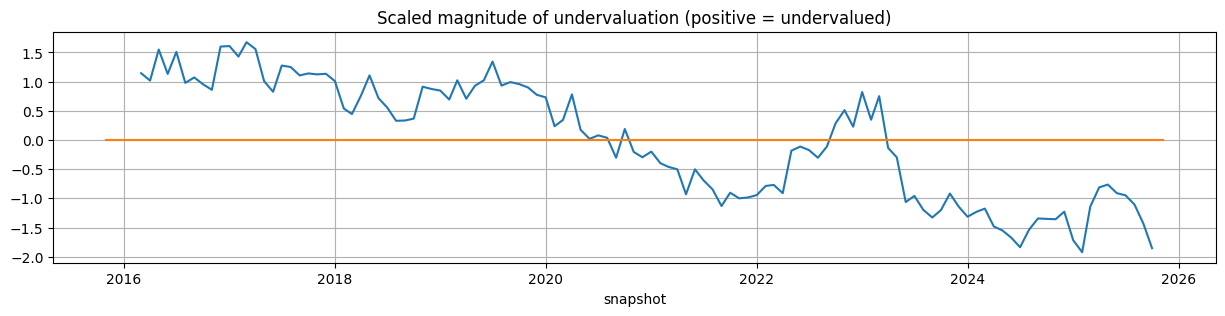

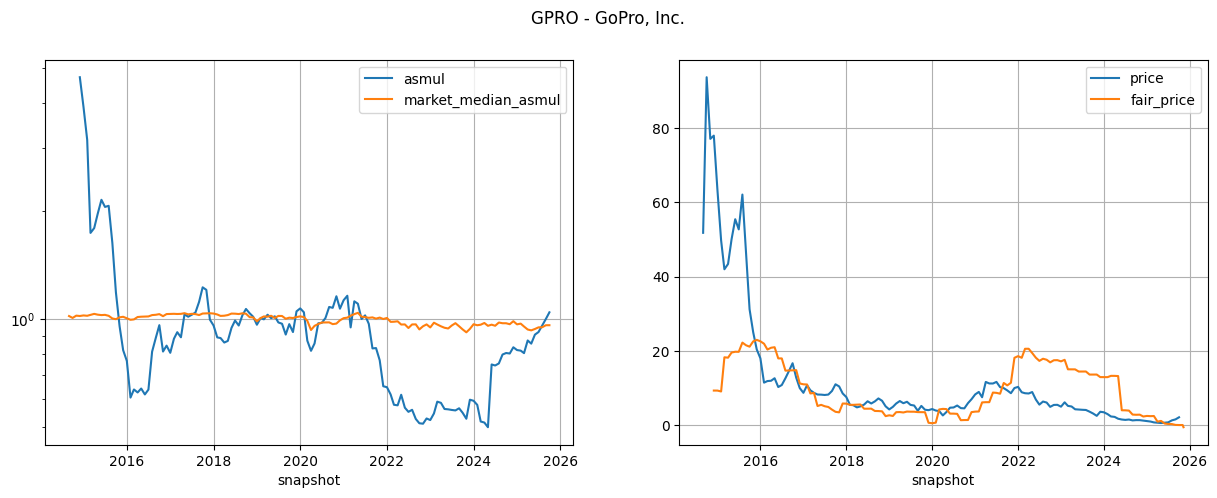

GoPro, Inc. stock pricing model:
GPRO fair_price = 30.3894 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -0.028


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001500435,2025-03-31,GPRO,0.462510,0.352530,-0.083924,0.574249,0.889637,0.010743,0.298444
2025-09-01,0001500435,2025-06-30,GPRO,0.438990,0.341075,-0.075777,0.611831,0.889637,0.003104,0.066308
2025-10-01,0001500435,2025-06-30,GPRO,0.438990,0.341075,-0.075777,0.624741,0.889637,0.002126,0.036577
2025-11-01,0001500435,2025-06-30,GPRO,0.438990,0.341075,-0.075777,0.624741,0.889637,0.002126,0.036577
2025-11-08,0001500435,2025-09-30,GPRO,0.538608,0.458114,-0.061371,0.624741,0.889637,-0.017289,-0.553436


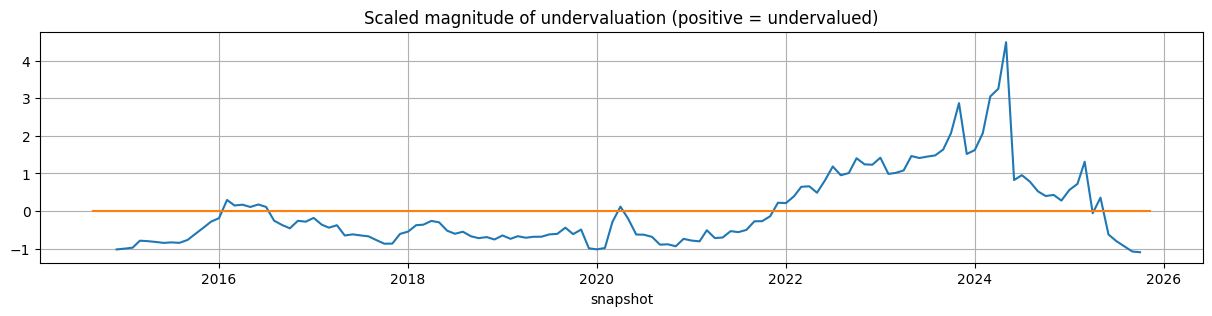

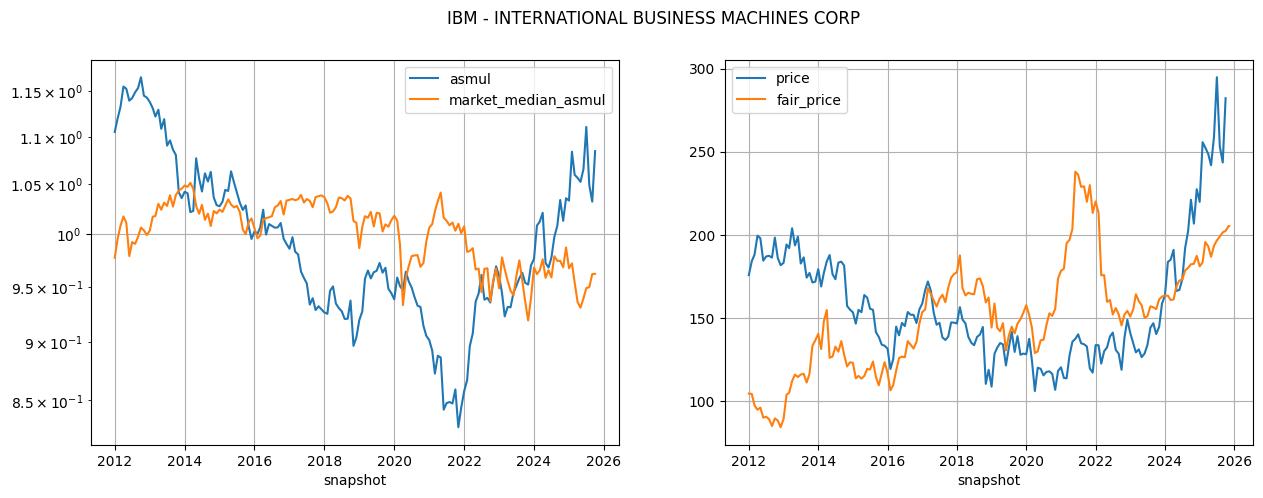

INTERNATIONAL BUSINESS MACHINES CORP stock pricing model:
IBM fair_price = 5.0331 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 39.5708


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000051143,2025-06-30,IBM,148.585000,121.076000,13.282000,0.574249,0.976665,31.668888,198.962604
2025-09-01,0000051143,2025-06-30,IBM,148.585000,121.076000,13.282000,0.611831,0.976665,32.168052,201.474932
2025-10-01,0000051143,2025-06-30,IBM,148.585000,121.076000,13.282000,0.624741,0.976665,32.339535,202.338016
2025-11-01,0000051143,2025-09-30,IBM,146.312000,118.407000,13.483000,0.624741,0.976665,32.914149,205.230092
2025-11-08,0000051143,2025-09-30,IBM,146.312000,118.407000,13.483000,0.624741,0.976665,32.914149,205.230092


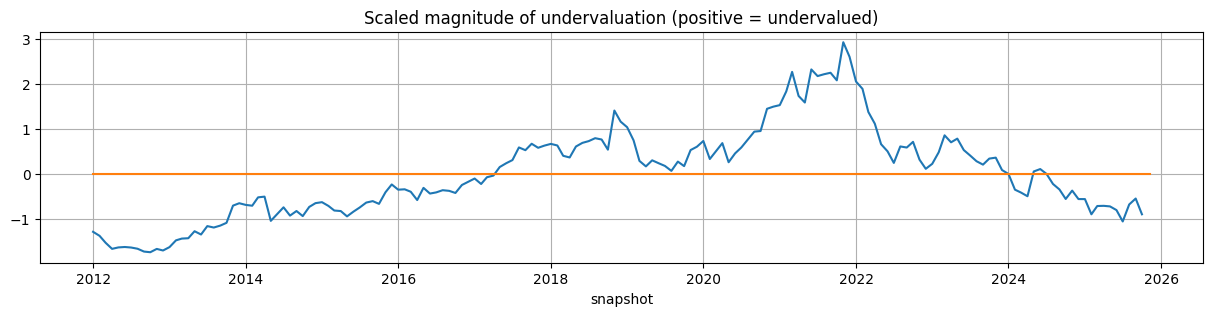

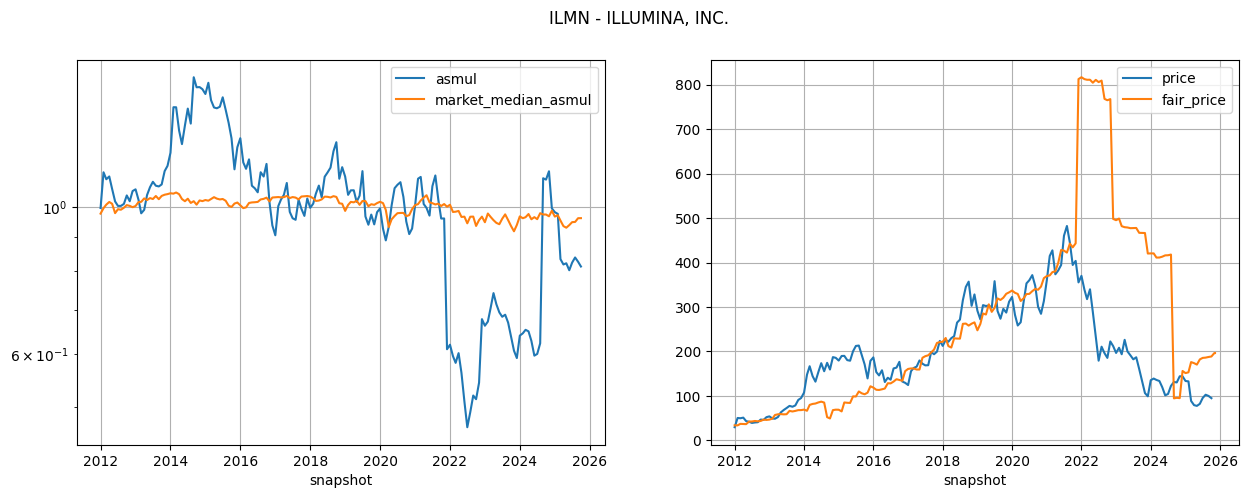

ILLUMINA, INC. stock pricing model:
ILMN fair_price = 73.7043 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -40.8885


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001110803,2025-03-30,ILMN,6.182000,3.814000,1.000000,0.574249,1.022450,3.081037,186.197155
2025-09-01,0001110803,2025-06-29,ILMN,6.087000,3.829000,1.154000,0.611831,1.022450,3.100708,187.646998
2025-10-01,0001110803,2025-06-29,ILMN,6.087000,3.829000,1.154000,0.624741,1.022450,3.115607,188.745132
2025-11-01,0001110803,2025-09-28,ILMN,6.177000,3.796000,1.122000,0.624741,1.022450,3.220636,196.486204
2025-11-08,0001110803,2025-09-28,ILMN,6.177000,3.796000,1.122000,0.624741,1.022450,3.220636,196.486204


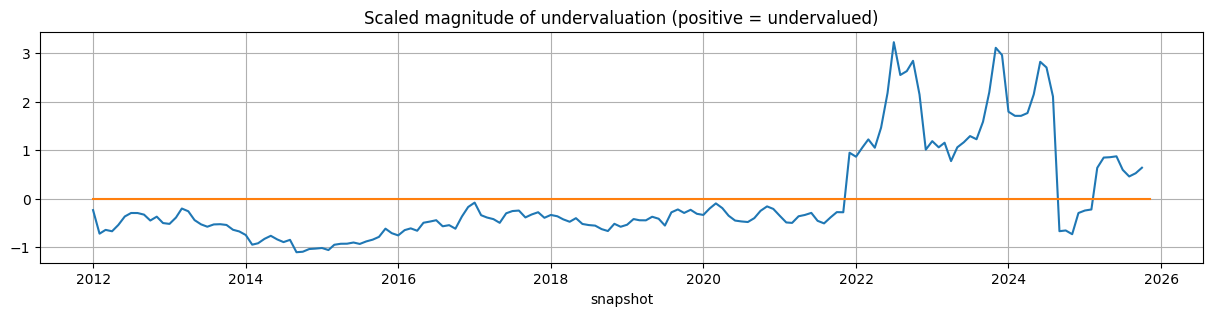

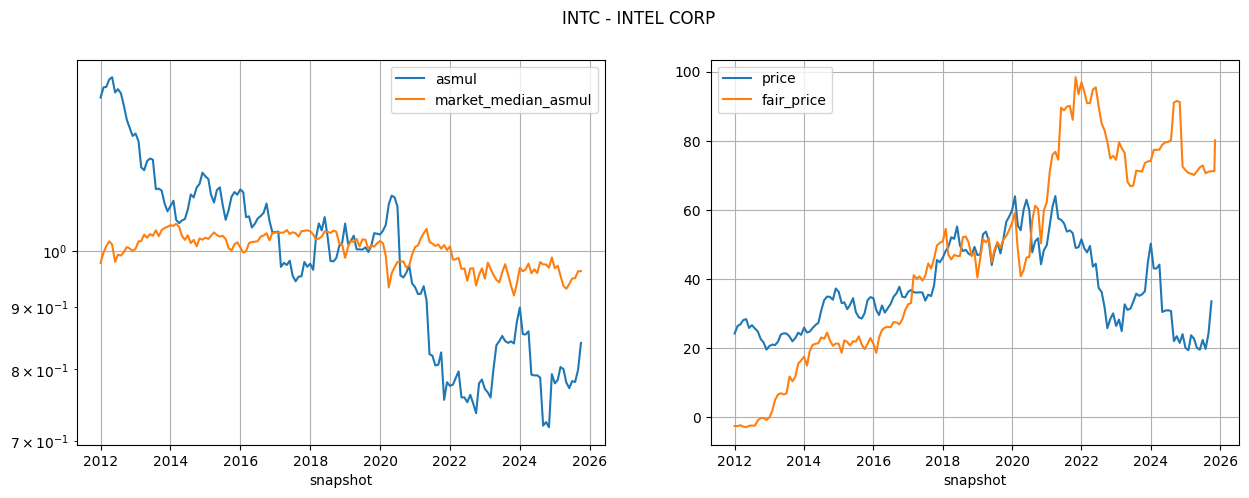

INTEL CORP stock pricing model:
INTC fair_price = 1.1672 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -52.063


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000050863,2025-06-28,INTC,192.520000,94.637000,10.082000,0.574249,1.007411,105.099432,70.614006
2025-09-01,0000050863,2025-06-28,INTC,192.520000,94.637000,10.082000,0.611831,1.007411,105.478334,71.056278
2025-10-01,0000050863,2025-06-28,INTC,192.520000,94.637000,10.082000,0.624741,1.007411,105.608501,71.208216
2025-11-01,0000050863,2025-06-28,INTC,192.520000,94.637000,10.082000,0.624741,1.007411,105.608501,71.208216
2025-11-08,0000050863,2025-09-27,INTC,204.514000,98.138000,8.574000,0.624741,1.007411,113.248284,80.125731


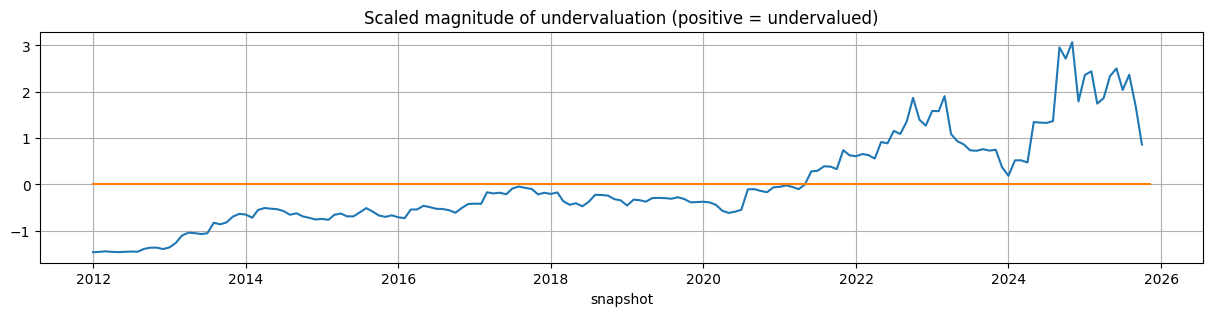

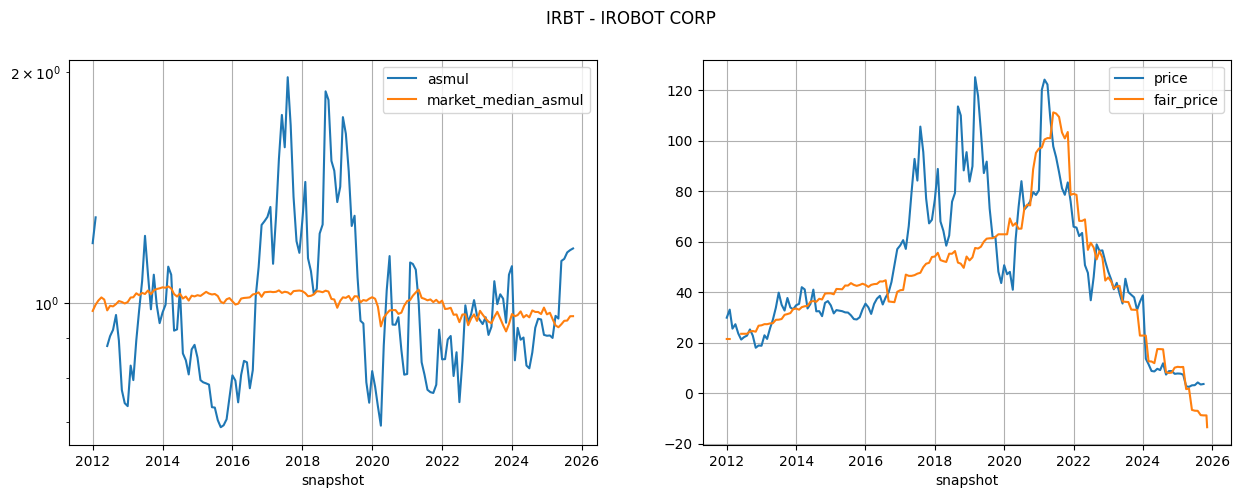

IROBOT CORP stock pricing model:
IRBT fair_price = 110.021 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -0.2127


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001159167,2025-03-29,IRBT,0.461509,0.462302,-0.061119,0.574249,0.943390,-0.062017,-7.035864
2025-09-01,0001159167,2025-06-28,IRBT,0.480320,0.488012,-0.069606,0.611831,0.943390,-0.077470,-8.736070
2025-10-01,0001159167,2025-06-28,IRBT,0.480320,0.488012,-0.069606,0.624741,0.943390,-0.078369,-8.834943
2025-11-01,0001159167,2025-06-28,IRBT,0.480320,0.488012,-0.069606,0.624741,0.943390,-0.078369,-8.834943
2025-11-08,0001159167,2025-09-27,IRBT,0.481573,0.508458,-0.106949,0.624741,0.943390,-0.120962,-13.521137


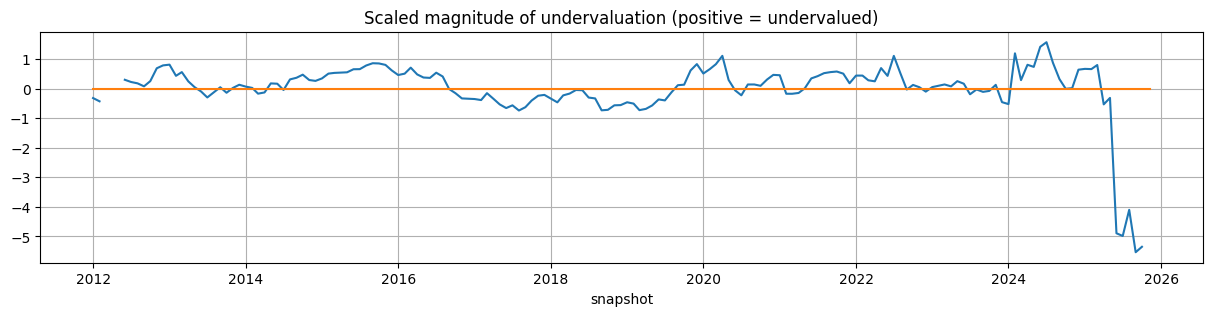

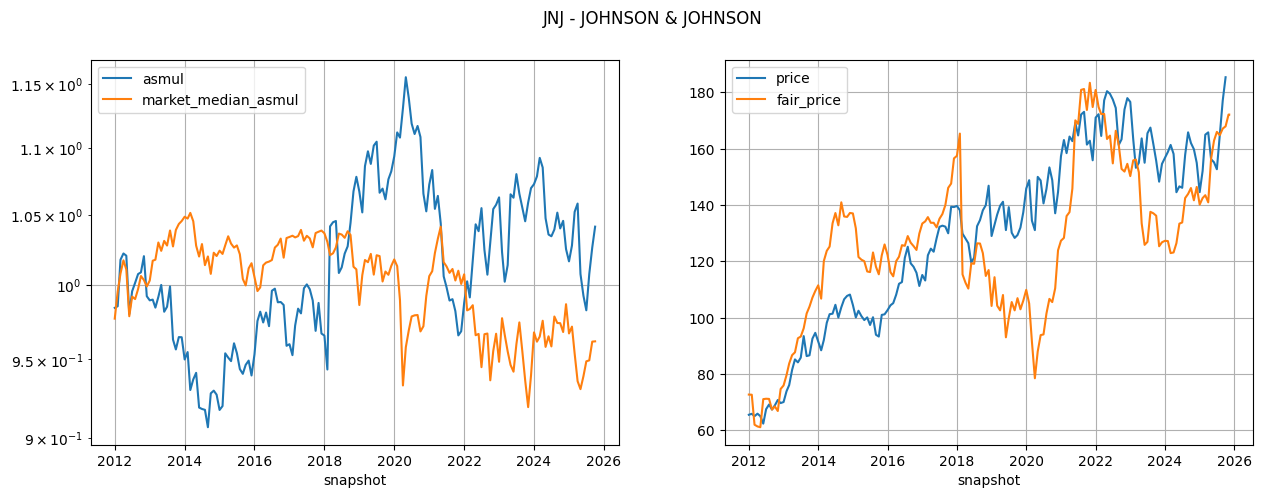

JOHNSON & JOHNSON stock pricing model:
JNJ fair_price = 2.7154 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -88.3218


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000200406,2025-06-29,JNJ,193.389000,114.916000,23.028000,0.574249,1.007912,93.226943,164.830798
2025-09-01,0000200406,2025-06-29,JNJ,193.389000,114.916000,23.028000,0.611831,1.007912,94.092381,167.180847
2025-10-01,0000200406,2025-06-29,JNJ,193.389000,114.916000,23.028000,0.624741,1.007912,94.389693,167.988182
2025-11-01,0000200406,2025-09-28,JNJ,192.816000,113.539000,24.204000,0.624741,1.007912,95.923856,172.154113
2025-11-08,0000200406,2025-09-28,JNJ,192.816000,113.539000,24.204000,0.624741,1.007912,95.923856,172.154113


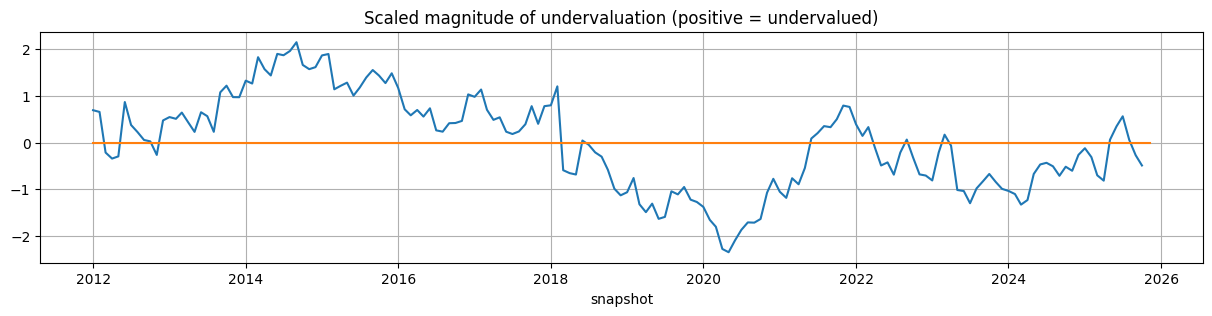

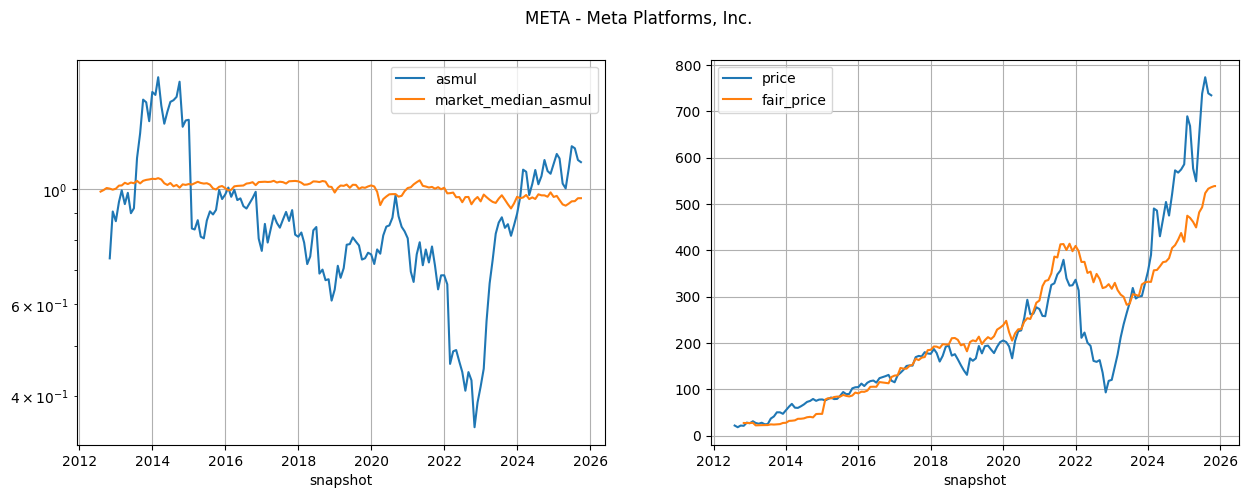

Meta Platforms, Inc. stock pricing model:
META fair_price = 2.4744 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -0.8961


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001326801,2025-06-30,META,294.744000,99.674000,102.299000,0.574249,0.857620,211.849297,523.295319
2025-09-01,0001326801,2025-06-30,META,294.744000,99.674000,102.299000,0.611831,0.857620,215.693896,532.808241
2025-10-01,0001326801,2025-06-30,META,294.744000,99.674000,102.299000,0.624741,0.857620,217.014668,536.076308
2025-11-01,0001326801,2025-09-30,META,303.844000,109.778000,107.574000,0.624741,0.857620,218.010518,538.540399
2025-11-08,0001326801,2025-09-30,META,303.844000,109.778000,107.574000,0.624741,0.857620,218.010518,538.540399


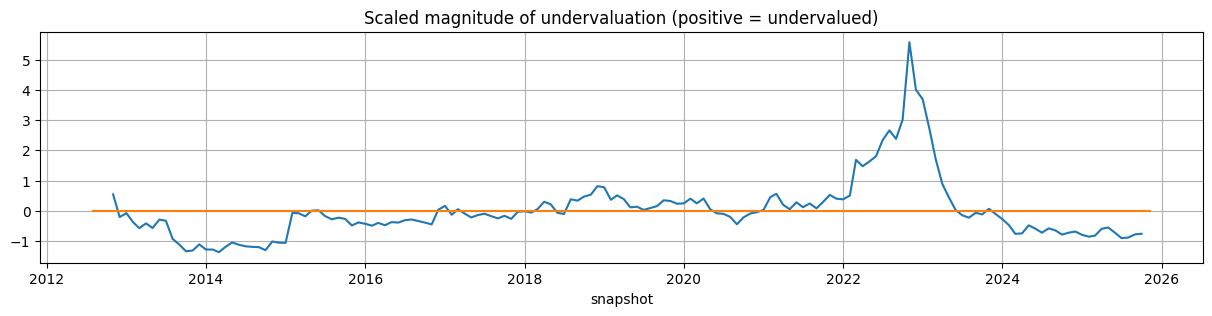

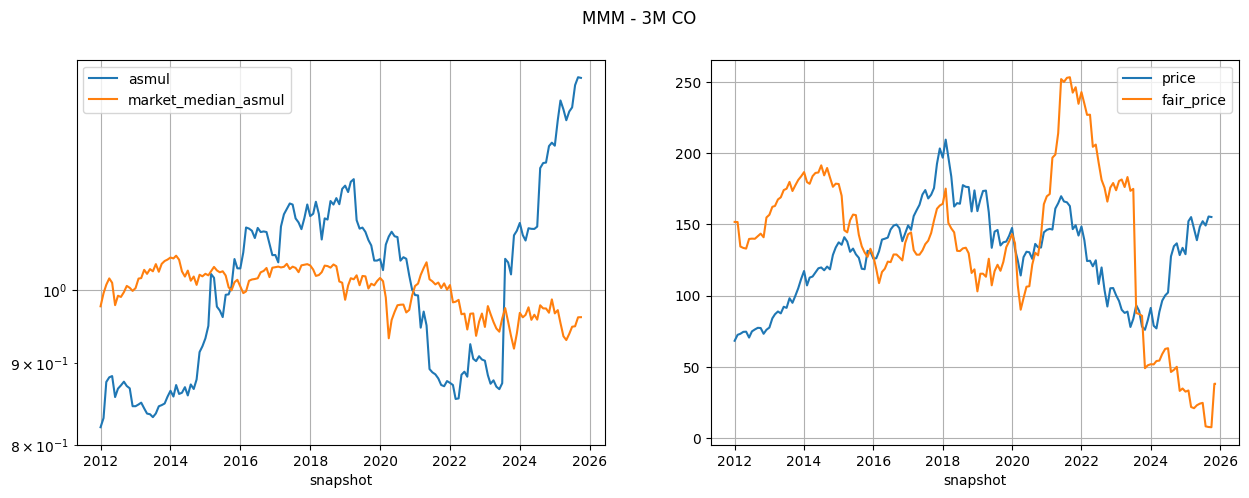

3M CO stock pricing model:
MMM fair_price = 12.0095 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -53.1486


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000066740,2025-06-30,MMM,37.989000,33.699000,-1.002000,0.574249,1.036870,5.115276,8.283330
2025-09-01,0000066740,2025-06-30,MMM,37.989000,33.699000,-1.002000,0.611831,1.036870,5.077618,7.831086
2025-10-01,0000066740,2025-06-30,MMM,37.989000,33.699000,-1.002000,0.624741,1.036870,5.064682,7.675723
2025-11-01,0000066740,2025-09-30,MMM,37.611000,32.983000,2.541000,0.624741,1.036870,7.602204,38.150114
2025-11-08,0000066740,2025-09-30,MMM,37.611000,32.983000,2.541000,0.624741,1.036870,7.602204,38.150114


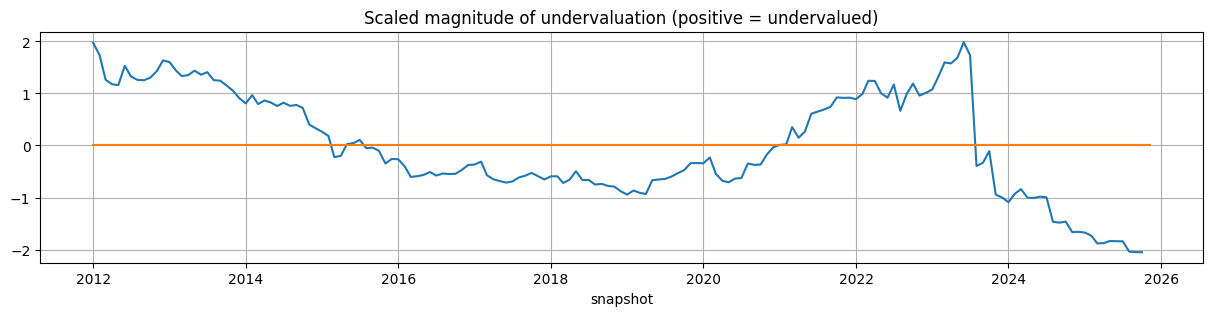

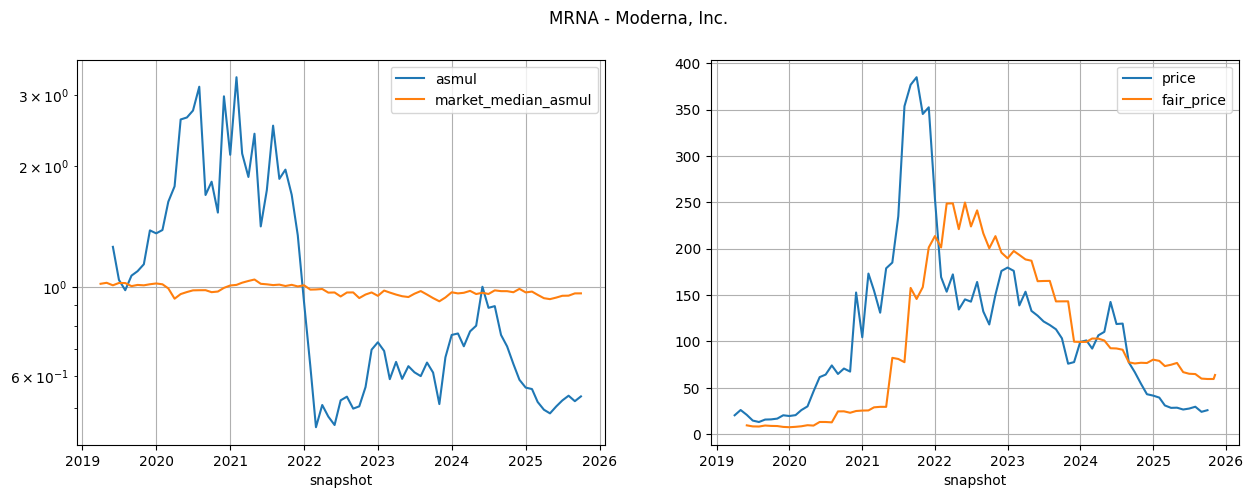

Moderna, Inc. stock pricing model:
MRNA fair_price = 12.3607 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 0.0565


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001682852,2025-03-31,MRNA,12.704000,2.638000,-3.052000,0.574249,0.757942,5.238293,64.805306
2025-09-01,0001682852,2025-06-30,MRNA,12.010000,2.611000,-2.697000,0.611831,0.757942,4.841781,59.904150
2025-10-01,0001682852,2025-06-30,MRNA,12.010000,2.611000,-2.697000,0.624741,0.757942,4.806960,59.473743
2025-11-01,0001682852,2025-06-30,MRNA,12.010000,2.611000,-2.697000,0.624741,0.757942,4.806960,59.473743
2025-11-08,0001682852,2025-09-30,MRNA,12.135000,2.805000,-1.978000,0.624741,0.757942,5.156892,63.799133


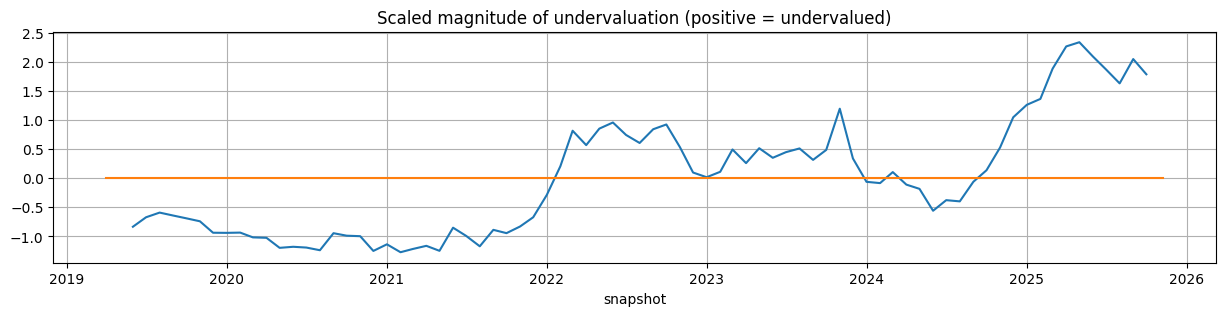

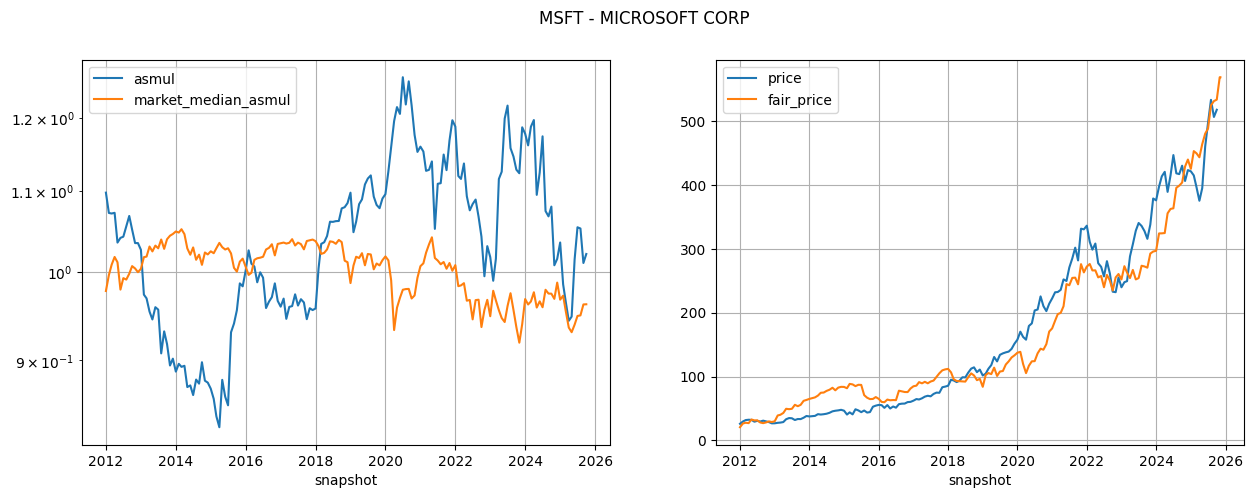

MICROSOFT CORP stock pricing model:
MSFT fair_price = 1.2956 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -54.7248


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000789019,2025-06-30,MSFT,619.003000,275.524000,136.162000,0.574249,1.041521,447.371205,524.910754
2025-09-01,0000789019,2025-06-30,MSFT,619.003000,275.524000,136.162000,0.611831,1.041521,452.488442,531.540892
2025-10-01,0000789019,2025-06-30,MSFT,619.003000,275.524000,136.162000,0.624741,1.041521,454.246416,533.818608
2025-11-01,0000789019,2025-09-30,MSFT,636.351000,273.275000,147.039000,0.624741,1.041521,481.359028,568.947009
2025-11-08,0000789019,2025-09-30,MSFT,636.351000,273.275000,147.039000,0.624741,1.041521,481.359028,568.947009


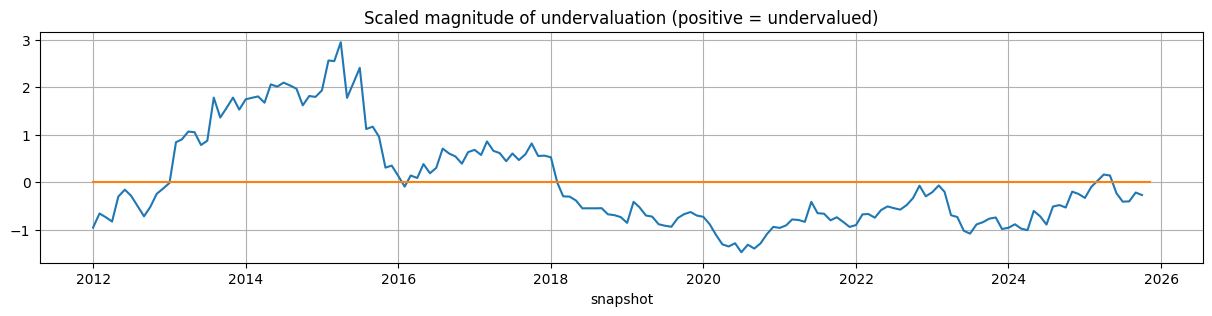

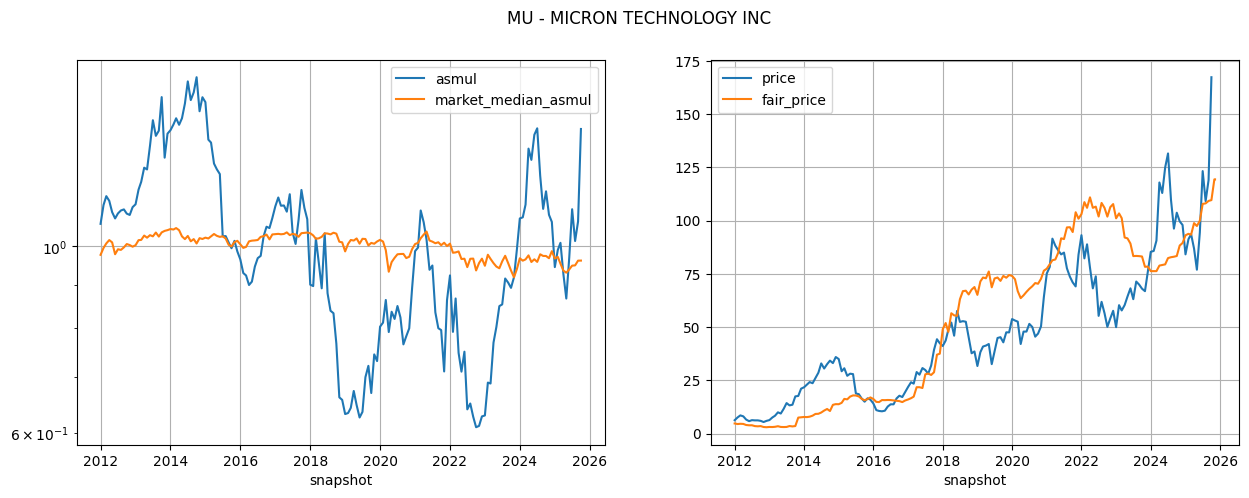

MICRON TECHNOLOGY INC stock pricing model:
MU fair_price = 1.9852 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -11.2656


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000723125,2025-05-29,MU,78.397000,27.649000,15.200000,0.574249,1.008330,60.129624,108.101312
2025-09-01,0000723125,2025-05-29,MU,78.397000,27.649000,15.200000,0.611831,1.008330,60.700870,109.235327
2025-10-01,0000723125,2025-05-29,MU,78.397000,27.649000,15.200000,0.624741,1.008330,60.897116,109.624906
2025-11-01,0000723125,2025-08-28,MU,82.798000,28.633000,17.525000,0.624741,1.008330,65.803300,119.364465
2025-11-08,0000723125,2025-08-28,MU,82.798000,28.633000,17.525000,0.624741,1.008330,65.803300,119.364465


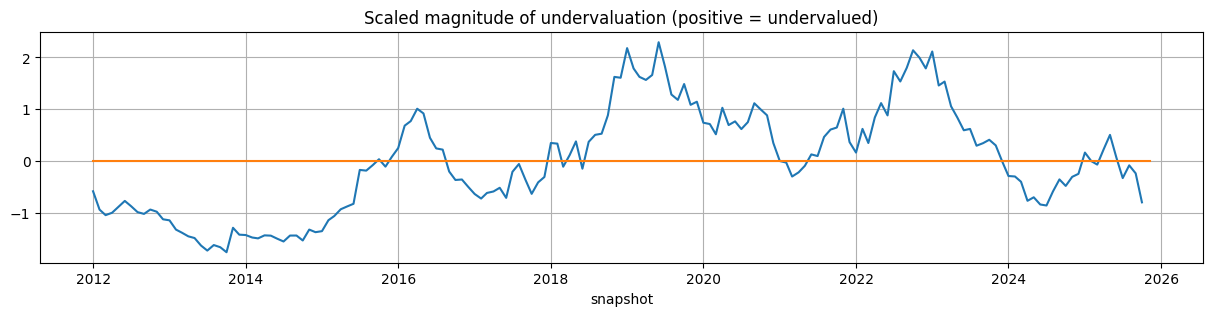

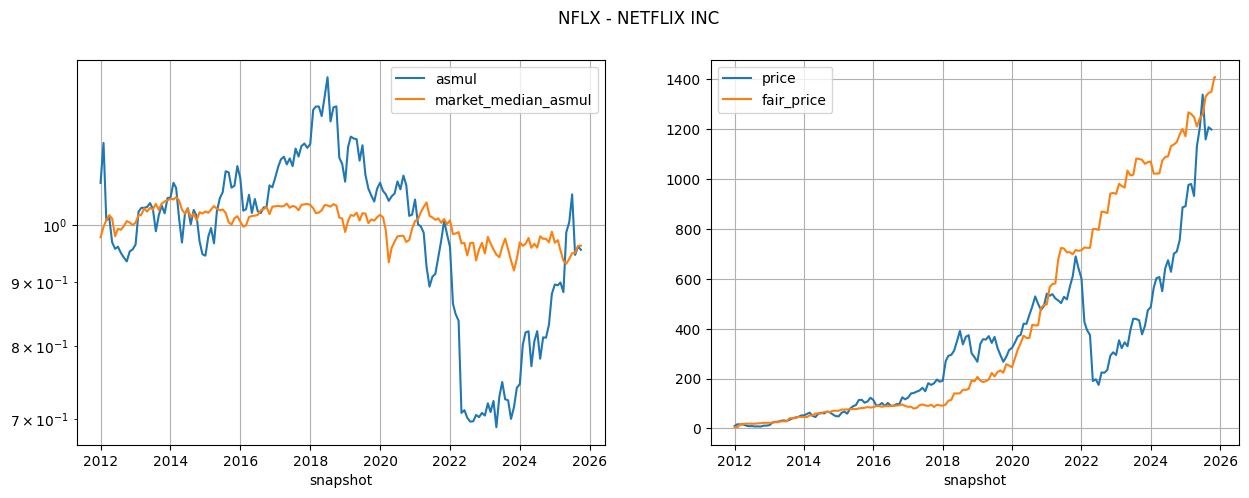

NETFLIX INC stock pricing model:
NFLX fair_price = 42.8685 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -10.1472


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001065280,2025-06-30,NFLX,53.099664,28.147765,9.070452,0.574249,1.021151,31.283695,1330.938794
2025-09-01,0001065280,2025-06-30,NFLX,53.099664,28.147765,9.070452,0.611831,1.021151,31.624580,1345.552056
2025-10-01,0001065280,2025-06-30,NFLX,53.099664,28.147765,9.070452,0.624741,1.021151,31.741688,1350.572291
2025-11-01,0001065280,2025-09-30,NFLX,54.934835,28.980800,9.574525,0.624741,1.021151,33.097555,1408.696301
2025-11-08,0001065280,2025-09-30,NFLX,54.934835,28.980800,9.574525,0.624741,1.021151,33.097555,1408.696301


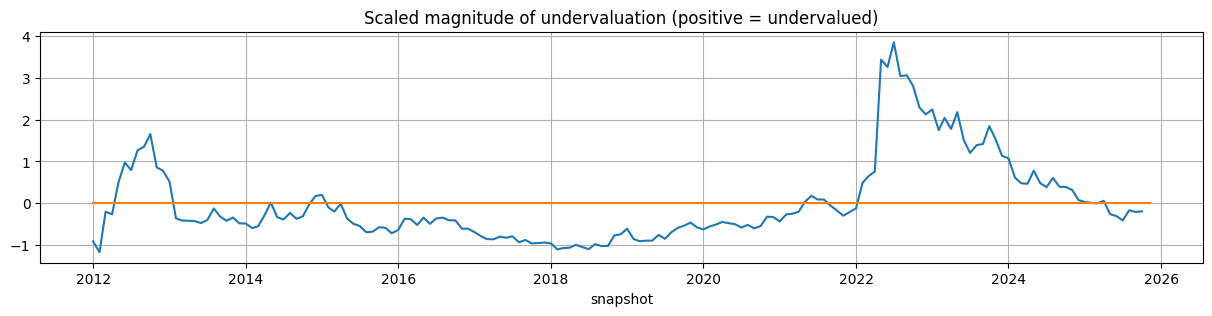

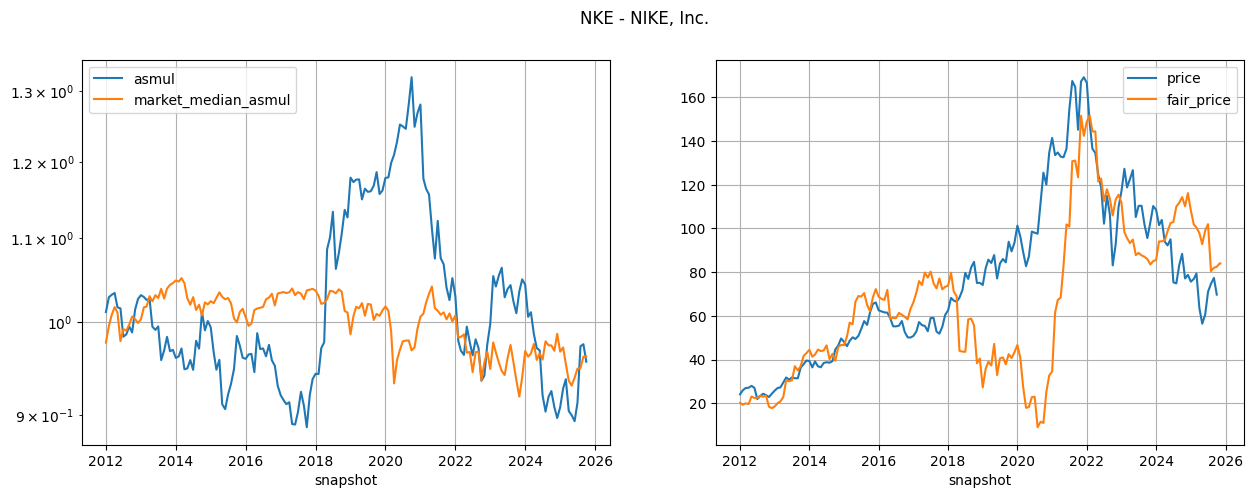

NIKE, Inc. stock pricing model:
NKE fair_price = 10.935 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -82.1526


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000320187,2025-05-31,NKE,36.579000,23.366000,3.698000,0.574249,0.987313,14.872492,80.478522
2025-09-01,0000320187,2025-05-31,NKE,36.579000,23.366000,3.698000,0.611831,0.987313,15.011471,81.998252
2025-10-01,0000320187,2025-05-31,NKE,36.579000,23.366000,3.698000,0.624741,0.987313,15.059215,82.520340
2025-11-01,0000320187,2025-08-31,NKE,37.334000,23.866000,3.526000,0.624741,0.987313,15.197181,84.028999
2025-11-08,0000320187,2025-08-31,NKE,37.334000,23.866000,3.526000,0.624741,0.987313,15.197181,84.028999


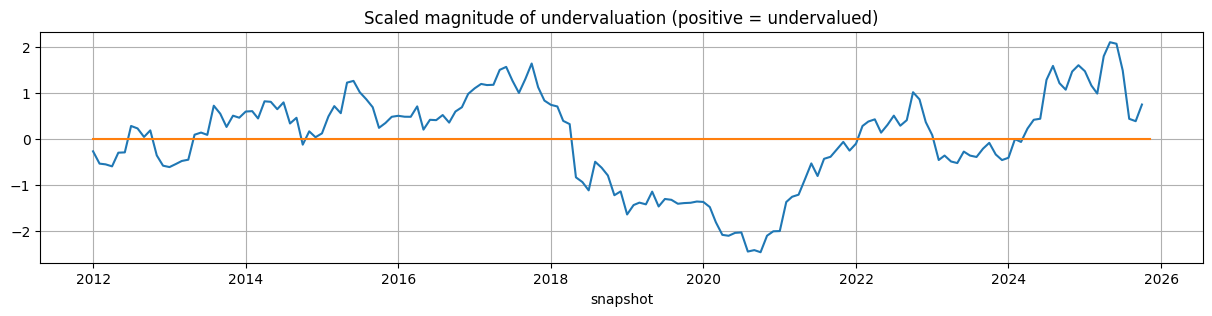

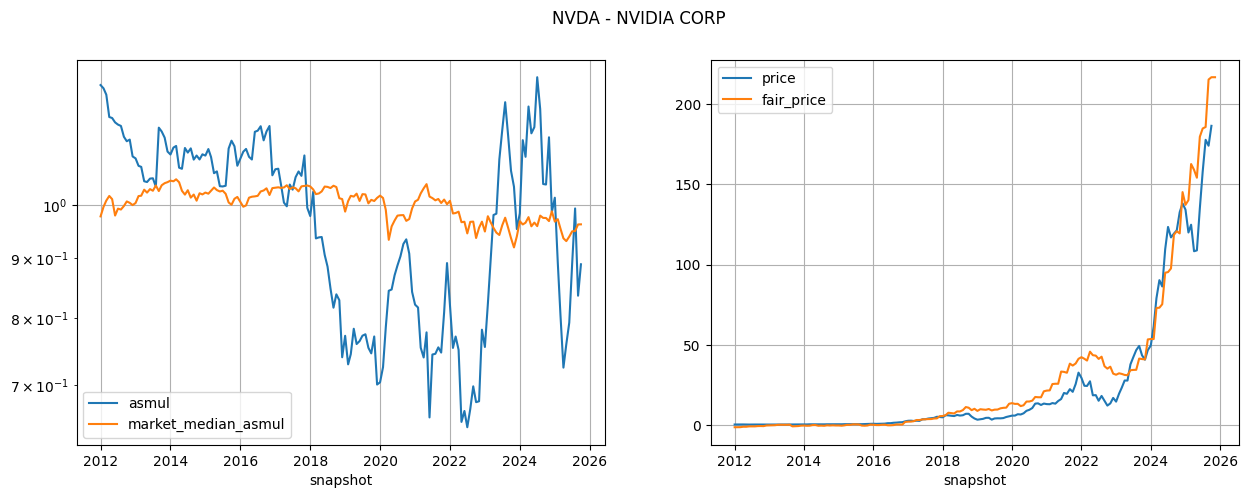

NVIDIA CORP stock pricing model:
NVDA fair_price = 1.4607 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -7.1331


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001045810,2025-04-27,NVDA,125.254000,41.411000,76.158000,0.574249,1.036278,132.120587,185.859568
2025-09-01,0001045810,2025-07-27,NVDA,140.740000,40.609000,77.035000,0.611831,1.036278,152.369132,215.437248
2025-10-01,0001045810,2025-07-27,NVDA,140.740000,40.609000,77.035000,0.624741,1.036278,153.363723,216.890079
2025-11-01,0001045810,2025-07-27,NVDA,140.740000,40.609000,77.035000,0.624741,1.036278,153.363723,216.890079
2025-11-08,0001045810,2025-07-27,NVDA,140.740000,40.609000,77.035000,0.624741,1.036278,153.363723,216.890079


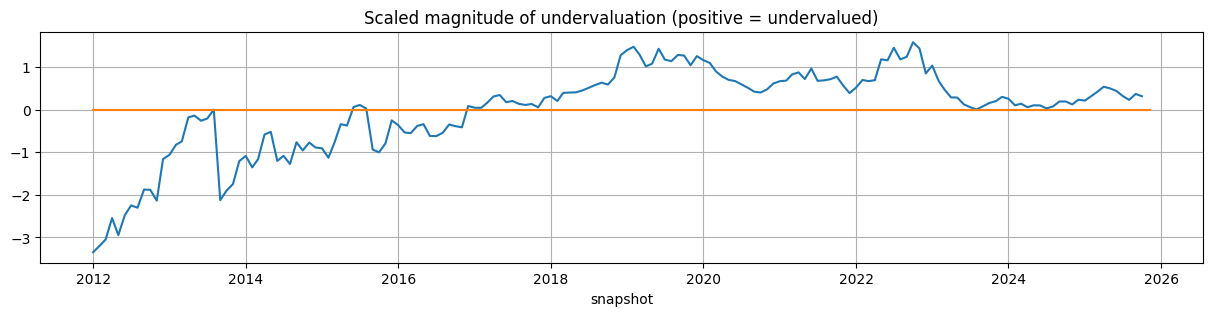

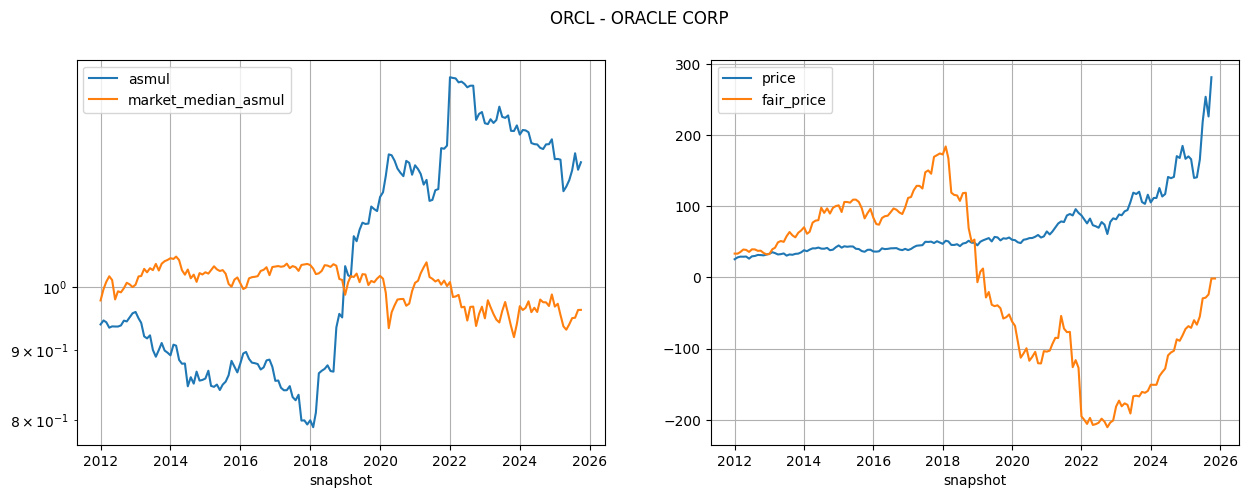

ORACLE CORP stock pricing model:
ORCL fair_price = 5.7356 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -173.2593


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001341439,2025-05-31,ORCL,168.361000,147.910000,20.821000,0.574249,0.957598,25.268561,-28.328178
2025-09-01,0001341439,2025-05-31,ORCL,168.361000,147.910000,20.821000,0.611831,0.957598,26.051055,-23.840079
2025-10-01,0001341439,2025-08-31,ORCL,180.449000,156.295000,21.534000,0.624741,0.957598,29.955757,-1.444152
2025-11-01,0001341439,2025-08-31,ORCL,180.449000,156.295000,21.534000,0.624741,0.957598,29.955757,-1.444152
2025-11-08,0001341439,2025-08-31,ORCL,180.449000,156.295000,21.534000,0.624741,0.957598,29.955757,-1.444152


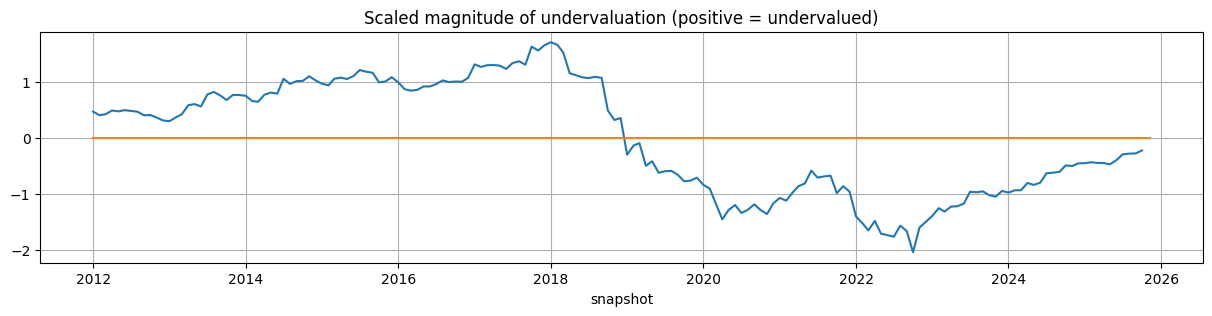

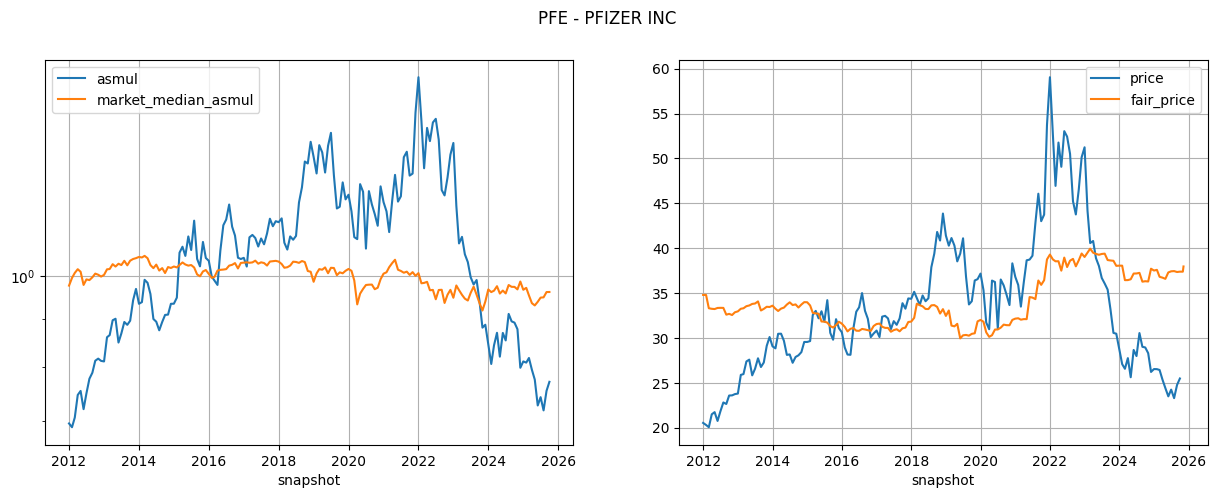

PFIZER INC stock pricing model:
PFE fair_price = 0.195 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 15.5266


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000078003,2025-03-30,PFE,208.028000,117.690000,13.989000,0.574249,1.067413,112.395023,37.446425
2025-09-01,0000078003,2025-06-29,PFE,206.095000,117.400000,15.188000,0.611831,1.067413,111.881032,37.346184
2025-10-01,0000078003,2025-06-29,PFE,206.095000,117.400000,15.188000,0.624741,1.067413,112.077123,37.384427
2025-11-01,0000078003,2025-06-29,PFE,206.095000,117.400000,15.188000,0.624741,1.067413,112.077123,37.384427
2025-11-08,0000078003,2025-09-28,PFE,208.731000,115.930000,13.077000,0.624741,1.067413,115.041996,37.962650


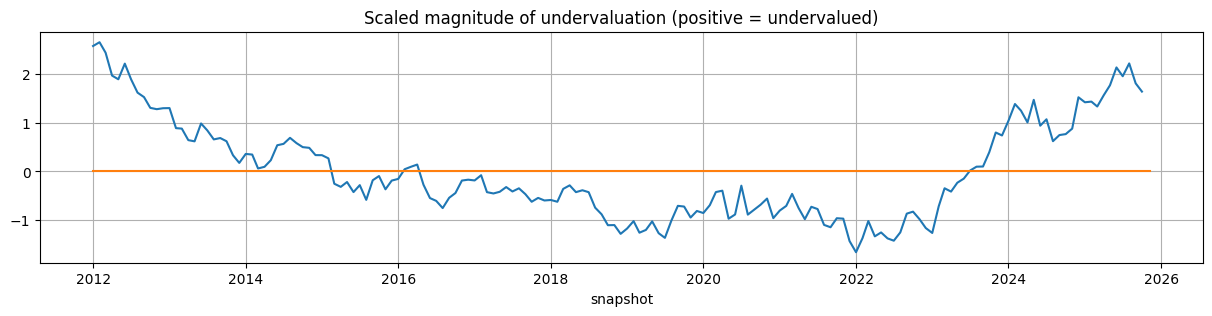

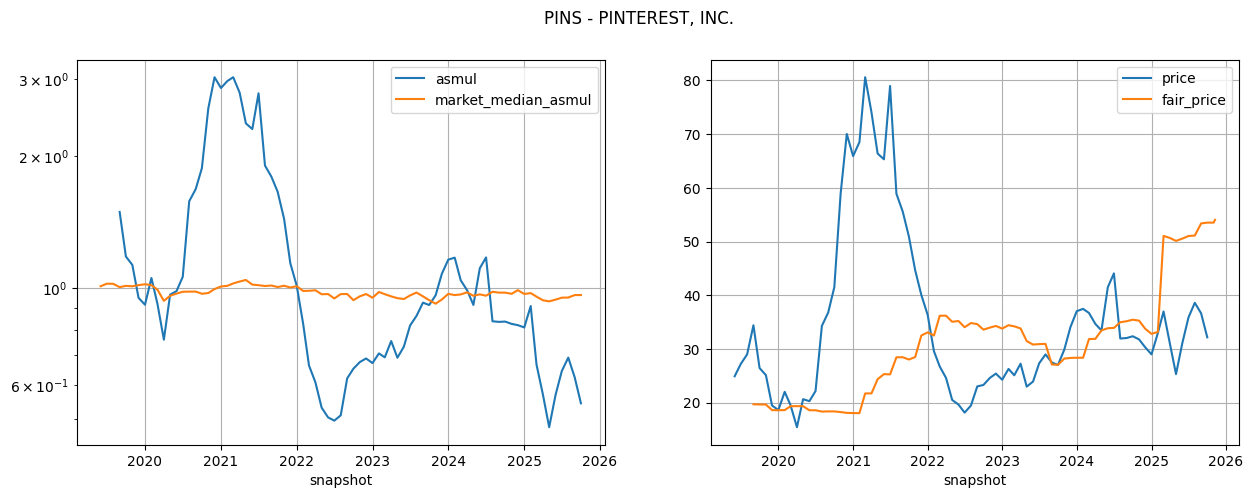

PINTEREST, INC. stock pricing model:
PINS fair_price = 10.6784 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -0.0459


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001506293,2025-03-31,PINS,5.282696,0.594227,0.972154,0.574249,0.913667,4.790656,51.110549
2025-09-01,0001506293,2025-06-30,PINS,5.402987,0.591034,1.073421,0.611831,0.913667,5.002249,53.370015
2025-10-01,0001506293,2025-06-30,PINS,5.402987,0.591034,1.073421,0.624741,0.913667,5.016108,53.518005
2025-11-01,0001506293,2025-06-30,PINS,5.402987,0.591034,1.073421,0.624741,0.913667,5.016108,53.518005
2025-11-08,0001506293,2025-09-30,PINS,5.515410,0.690442,1.147046,0.624741,0.913667,5.065414,54.044510


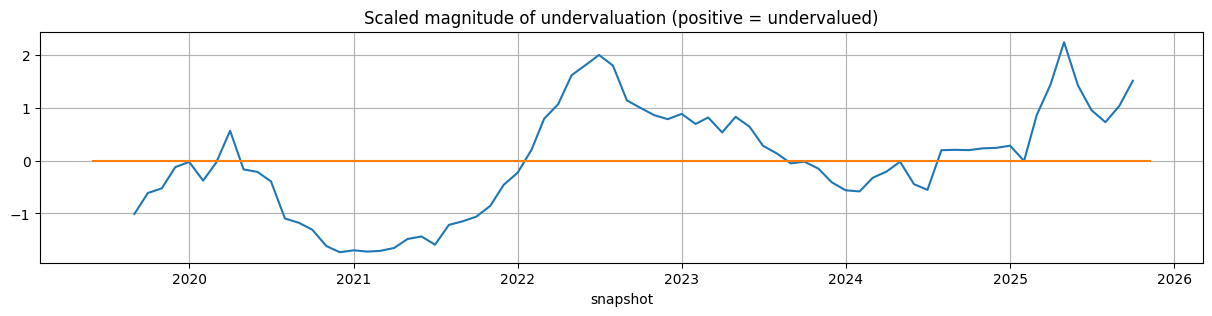

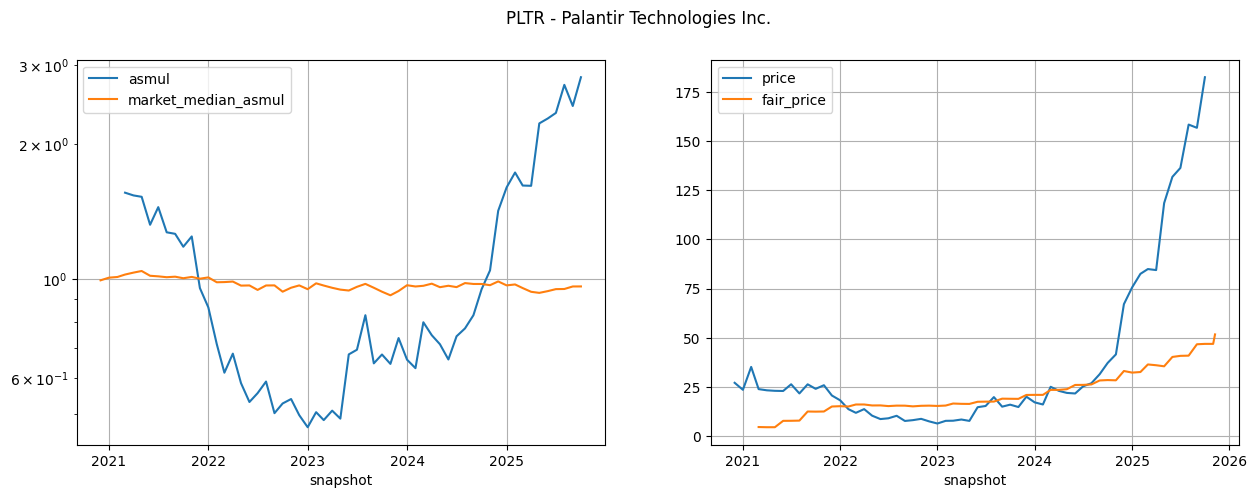

Palantir Technologies Inc. stock pricing model:
PLTR fair_price = 8.9424 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -0.1044


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001321655,2025-03-31,PLTR,6.736917,1.312762,1.334549,0.574249,0.761874,4.586280,40.907832
2025-09-01,0001321655,2025-06-30,PLTR,7.365688,1.436787,1.729613,0.611831,0.761874,5.233166,46.692534
2025-10-01,0001321655,2025-06-30,PLTR,7.365688,1.436787,1.729613,0.624741,0.761874,5.255497,46.892225
2025-11-01,0001321655,2025-06-30,PLTR,7.365688,1.436787,1.729613,0.624741,0.761874,5.255497,46.892225
2025-11-08,0001321655,2025-09-30,PLTR,8.113960,1.523503,1.817505,0.624741,0.761874,5.793780,51.705752


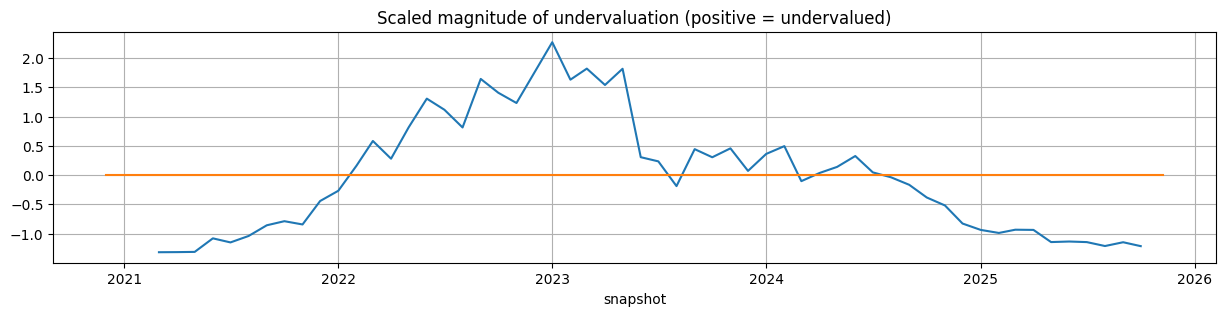

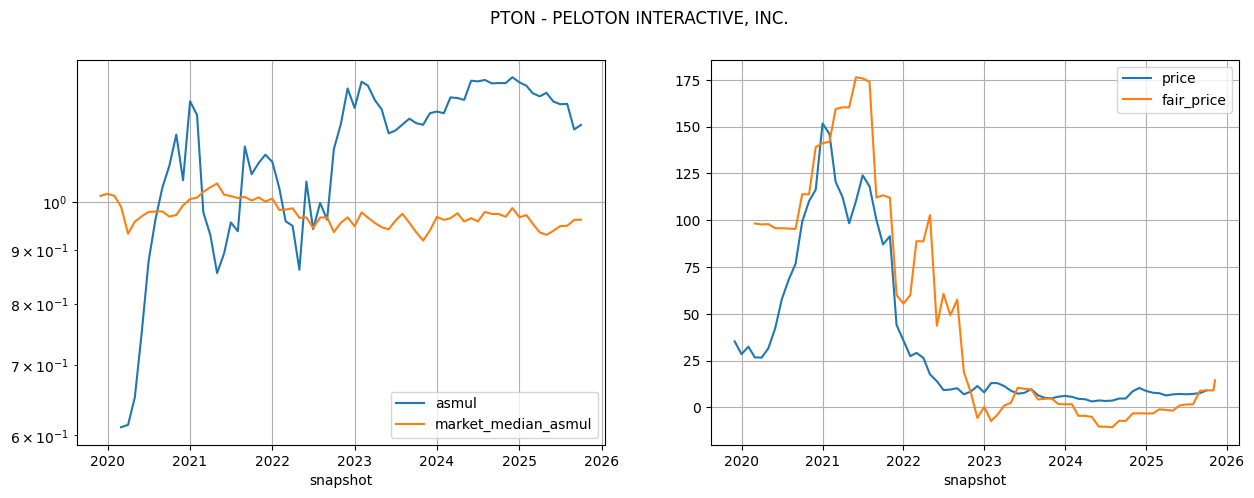

PELOTON INTERACTIVE, INC. stock pricing model:
PTON fair_price = 48.2799 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 0.0668


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001639825,2025-03-31,PTON,2.064800,2.556100,0.248600,0.574249,1.184134,0.031658,1.595254
2025-09-01,0001639825,2025-06-30,PTON,2.125300,2.539100,0.333000,0.611831,1.184134,0.181280,8.818967
2025-10-01,0001639825,2025-06-30,PTON,2.125300,2.539100,0.333000,0.624741,1.184134,0.185579,9.026538
2025-11-01,0001639825,2025-06-30,PTON,2.125300,2.539100,0.333000,0.624741,1.184134,0.185579,9.026538
2025-11-08,0001639825,2025-09-30,PTON,2.170100,2.517100,0.392400,0.624741,1.184134,0.297738,14.441558


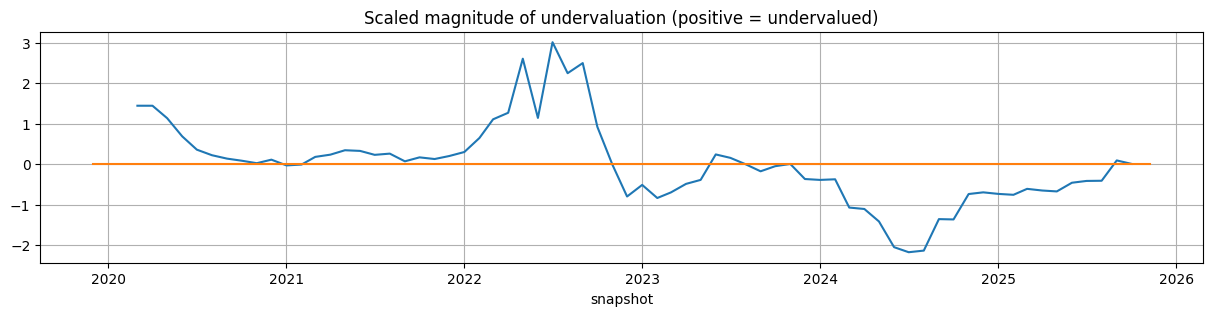

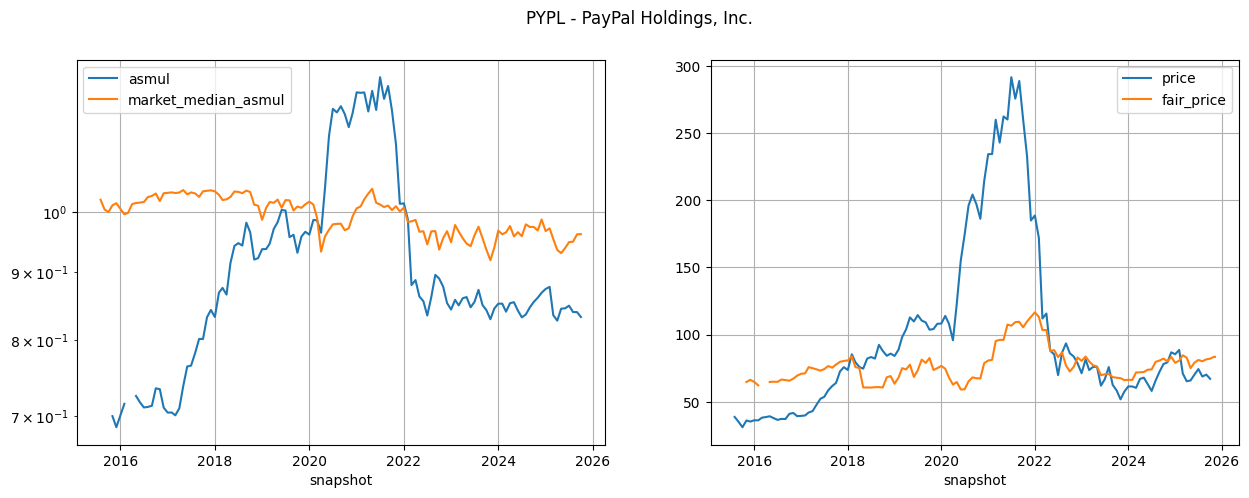

PayPal Holdings, Inc. stock pricing model:
PYPL fair_price = 6.3156 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -0.0241


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001633917,2025-06-30,PYPL,79.777000,59.576000,6.066000,0.574249,0.862202,12.691304,80.128505
2025-09-01,0001633917,2025-06-30,PYPL,79.777000,59.576000,6.066000,0.611831,0.862202,12.919276,81.568277
2025-10-01,0001633917,2025-06-30,PYPL,79.777000,59.576000,6.066000,0.624741,0.862202,12.997593,82.062896
2025-11-01,0001633917,2025-09-30,PYPL,79.801000,59.603000,6.426000,0.624741,0.862202,13.216193,83.443475
2025-11-08,0001633917,2025-09-30,PYPL,79.801000,59.603000,6.426000,0.624741,0.862202,13.216193,83.443475


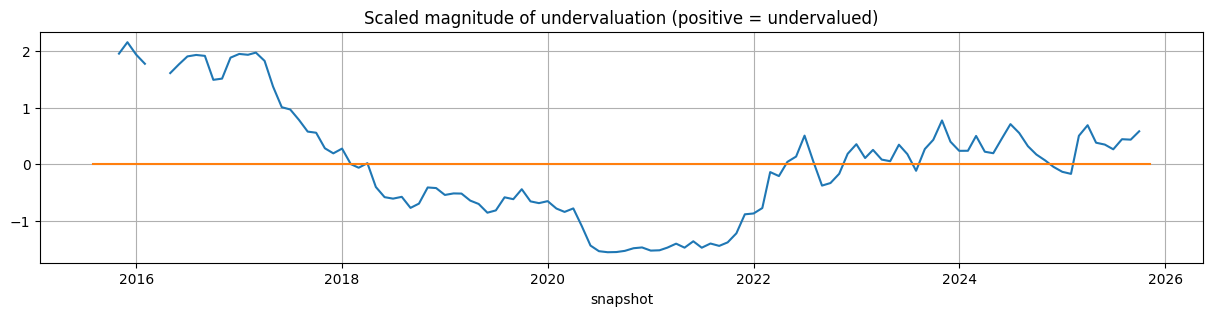

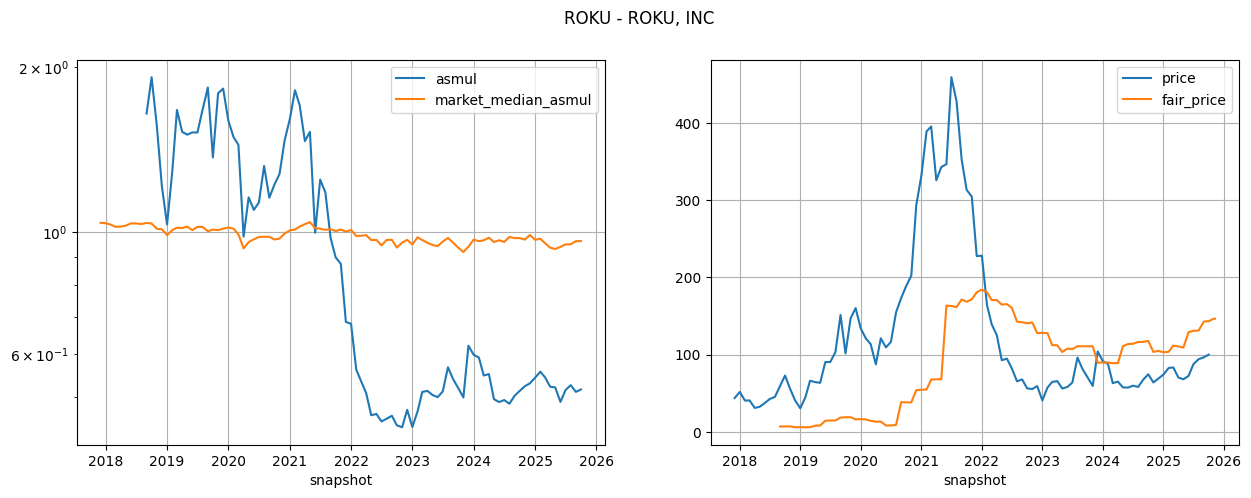

ROKU, INC stock pricing model:
ROKU fair_price = 130.4839 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 0.0439


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001428439,2025-03-31,ROKU,4.179874,1.654165,0.310094,0.574249,0.593774,1.005808,131.285670
2025-09-01,0001428439,2025-06-30,ROKU,4.281955,1.691403,0.396421,0.611831,0.593774,1.093655,142.748227
2025-10-01,0001428439,2025-06-30,ROKU,4.281955,1.691403,0.396421,0.624741,0.593774,1.098773,143.416063
2025-11-01,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.624741,0.593774,1.123279,146.613655
2025-11-08,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.624741,0.593774,1.123279,146.613655


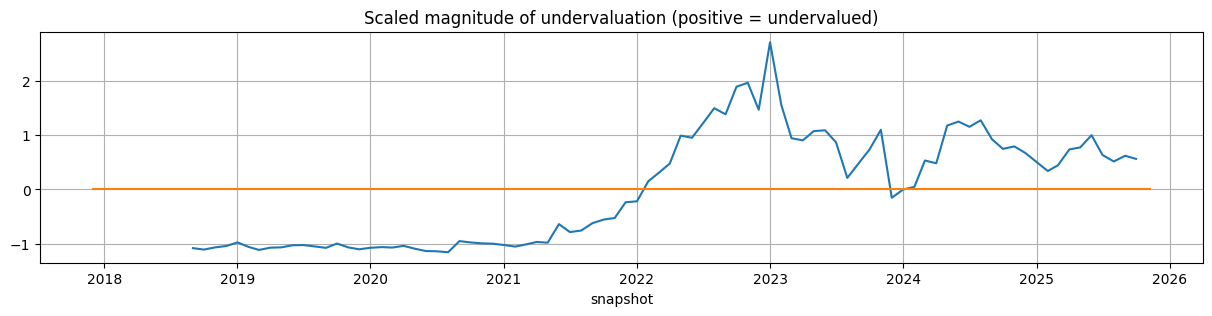

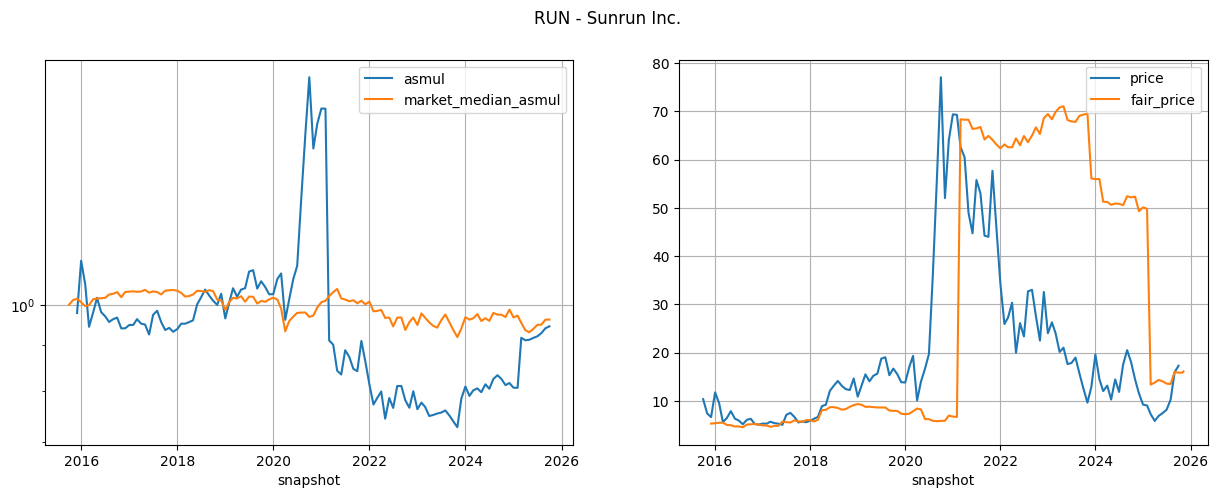

Sunrun Inc. stock pricing model:
RUN fair_price = 13.7312 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 0.0227


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001469367,2025-03-31,RUN,20.377855,17.762453,-0.727266,0.574249,0.940338,0.981992,13.506690
2025-09-01,0001469367,2025-06-30,RUN,21.230135,18.303408,-0.811380,0.611831,0.940338,1.163673,16.001389
2025-10-01,0001469367,2025-06-30,RUN,21.230135,18.303408,-0.811380,0.624741,0.940338,1.153197,15.857546
2025-11-01,0001469367,2025-06-30,RUN,21.230135,18.303408,-0.811380,0.624741,0.940338,1.153197,15.857546
2025-11-08,0001469367,2025-09-30,RUN,22.225482,19.241580,-0.776747,0.624741,0.940338,1.172625,16.124309


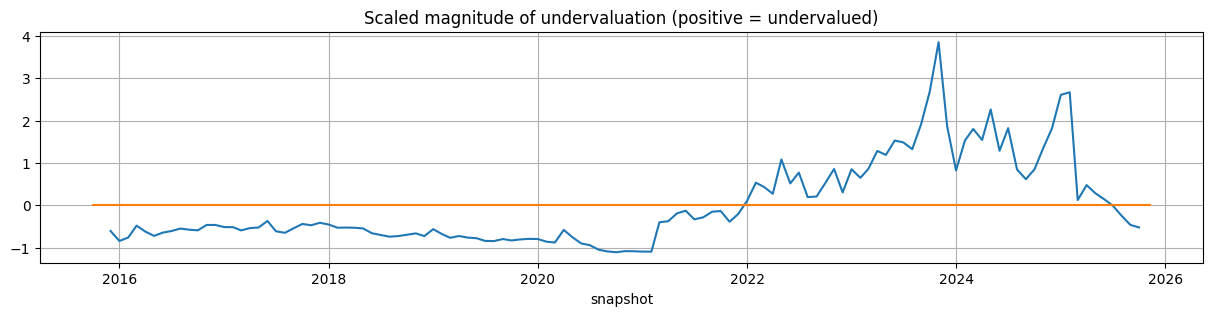

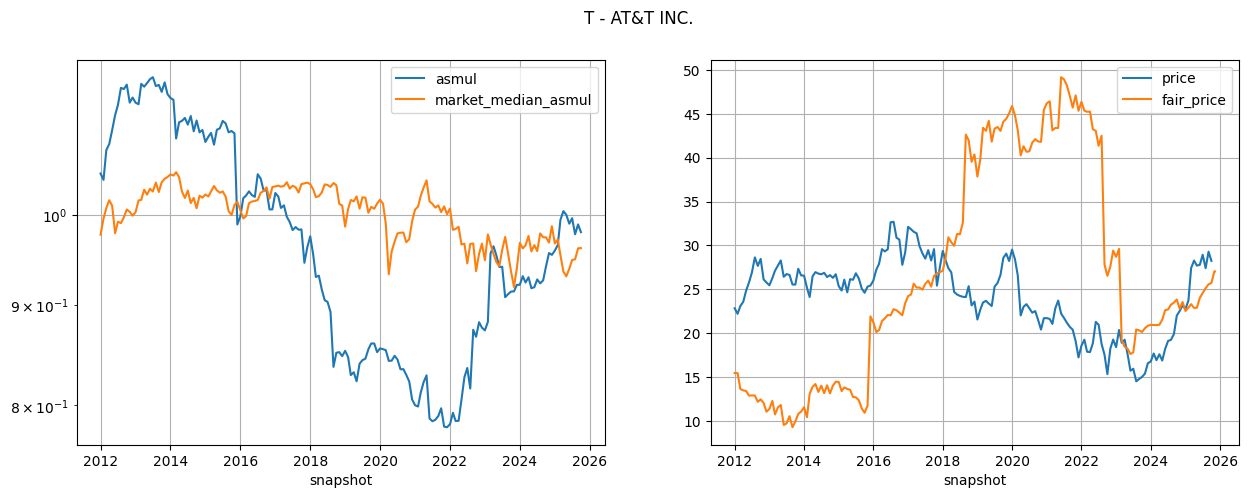

AT&T INC. stock pricing model:
T fair_price = 0.289 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -11.8088


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000732717,2025-06-30,T,405.491000,284.097000,40.943000,0.574249,0.957829,127.805473,25.129582
2025-09-01,0000732717,2025-06-30,T,405.491000,284.097000,40.943000,0.611831,0.957829,129.344192,25.574303
2025-10-01,0000732717,2025-06-30,T,405.491000,284.097000,40.943000,0.624741,0.957829,129.872803,25.727082
2025-11-01,0000732717,2025-09-30,T,423.213000,296.458000,40.860000,0.624741,0.957829,134.434594,27.045532
2025-11-08,0000732717,2025-09-30,T,423.213000,296.458000,40.860000,0.624741,0.957829,134.434594,27.045532


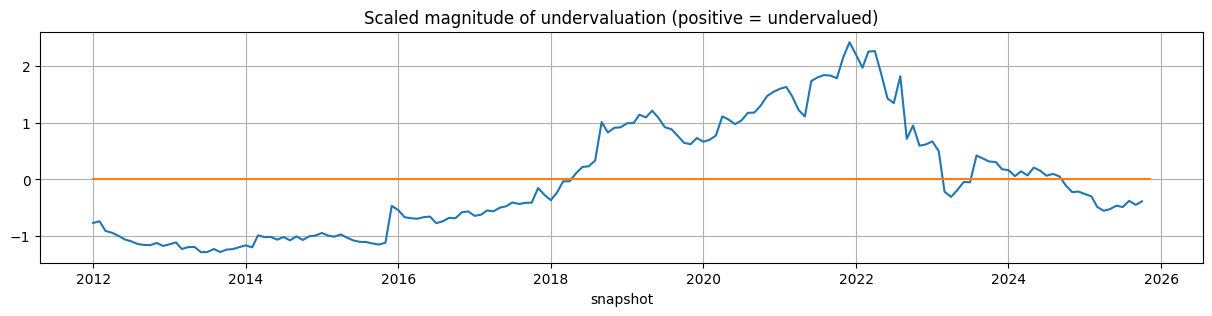

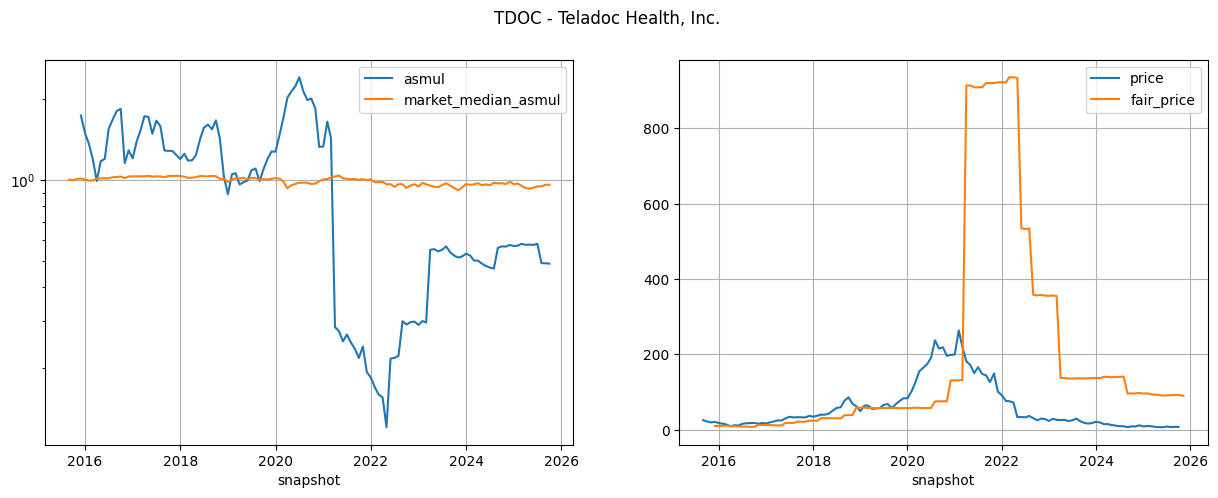

Teladoc Health, Inc. stock pricing model:
TDOC fair_price = 58.1175 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 0.0656


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001477449,2025-06-30,TDOC,2.894004,1.471865,0.303428,0.574249,0.993653,1.578015,91.775849
2025-09-01,0001477449,2025-06-30,TDOC,2.894004,1.471865,0.303428,0.611831,0.993653,1.589418,92.438588
2025-10-01,0001477449,2025-06-30,TDOC,2.894004,1.471865,0.303428,0.624741,0.993653,1.593335,92.666265
2025-11-01,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,0.624741,0.993653,1.556593,90.530886
2025-11-08,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,0.624741,0.993653,1.556593,90.530886


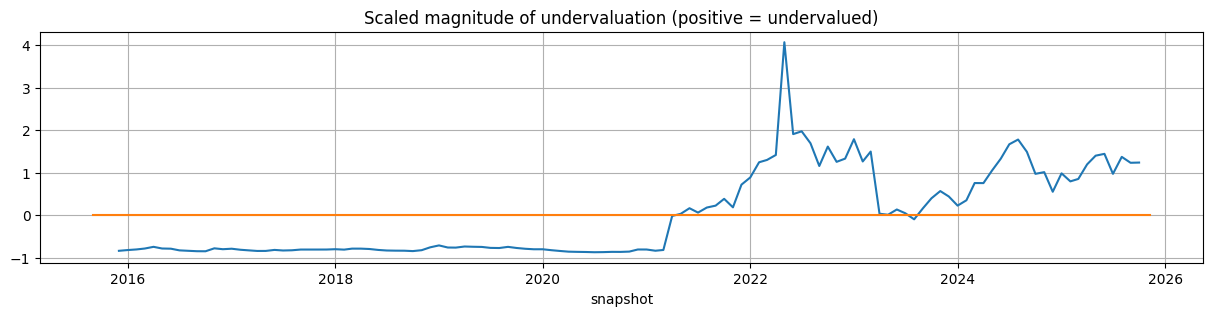

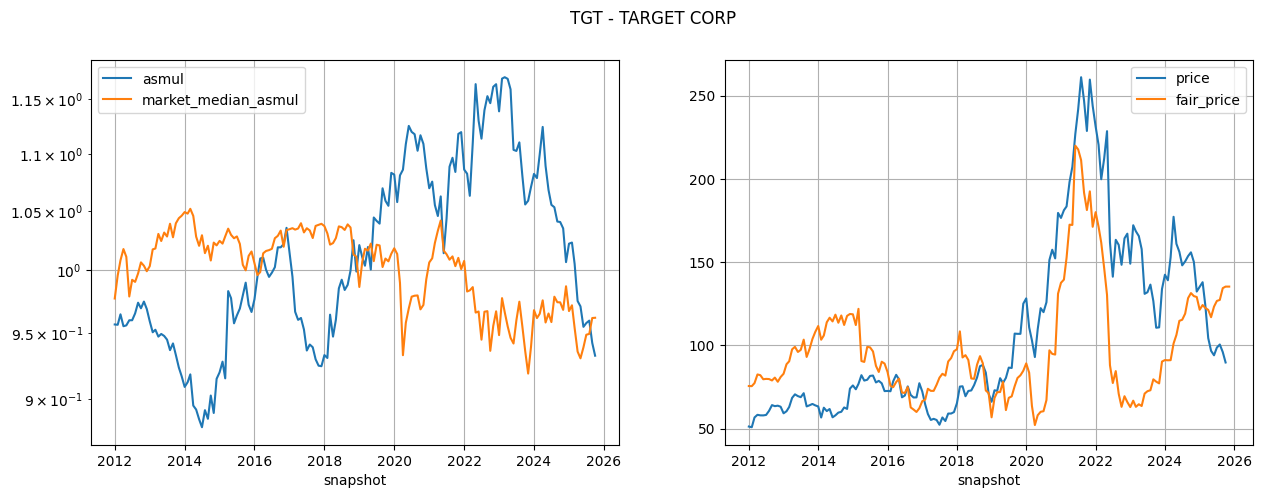

TARGET CORP stock pricing model:
TGT fair_price = 11.2713 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -84.5237


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000027419,2025-05-03,TGT,56.185000,41.238000,6.541000,0.574249,1.001584,18.792133,127.287724
2025-09-01,0000027419,2025-08-02,TGT,57.851000,42.431000,6.386000,0.611831,1.001584,19.418761,134.350628
2025-10-01,0000027419,2025-08-02,TGT,57.851000,42.431000,6.386000,0.624741,1.001584,19.501210,135.279935
2025-11-01,0000027419,2025-08-02,TGT,57.851000,42.431000,6.386000,0.624741,1.001584,19.501210,135.279935
2025-11-08,0000027419,2025-08-02,TGT,57.851000,42.431000,6.386000,0.624741,1.001584,19.501210,135.279935


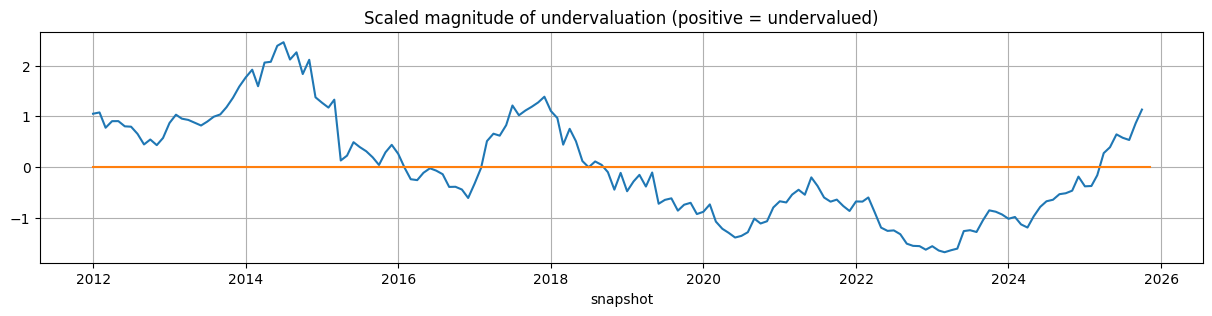

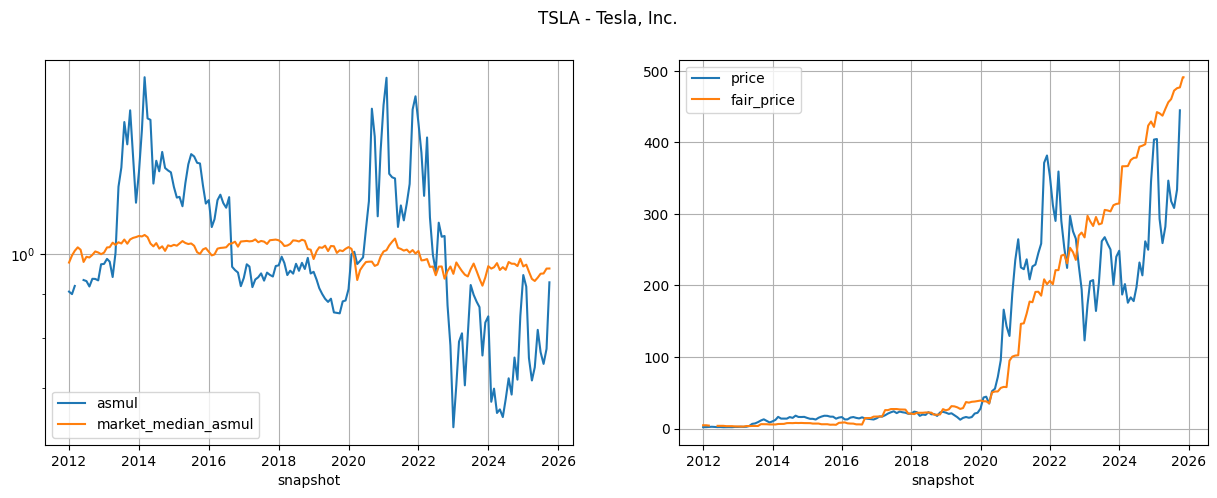

Tesla, Inc. stock pricing model:
TSLA fair_price = 5.6771 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 2.8


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001318605,2025-06-30,TSLA,128.567000,51.253000,15.765000,0.574249,0.971452,82.696651,472.280252
2025-09-01,0001318605,2025-06-30,TSLA,128.567000,51.253000,15.765000,0.611831,0.971452,83.289131,475.643842
2025-10-01,0001318605,2025-06-30,TSLA,128.567000,51.253000,15.765000,0.624741,0.971452,83.492672,476.799368
2025-11-01,0001318605,2025-09-30,TSLA,133.735000,53.765000,15.748000,0.624741,0.971452,85.990513,490.979958
2025-11-08,0001318605,2025-09-30,TSLA,133.735000,53.765000,15.748000,0.624741,0.971452,85.990513,490.979958


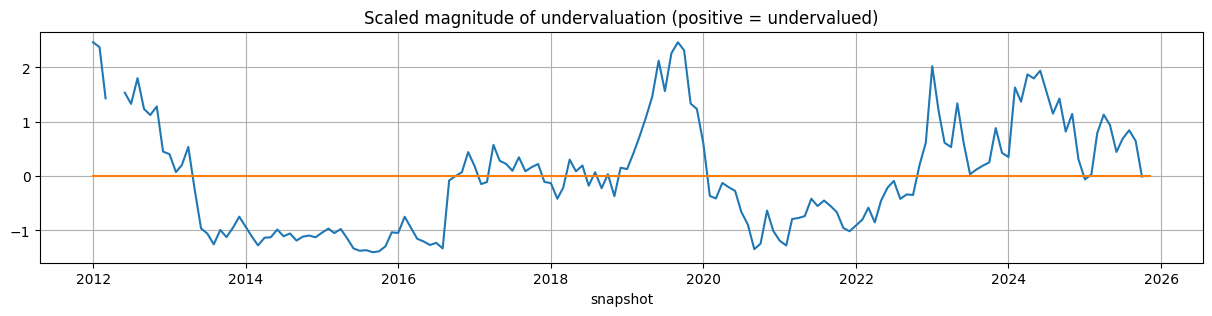

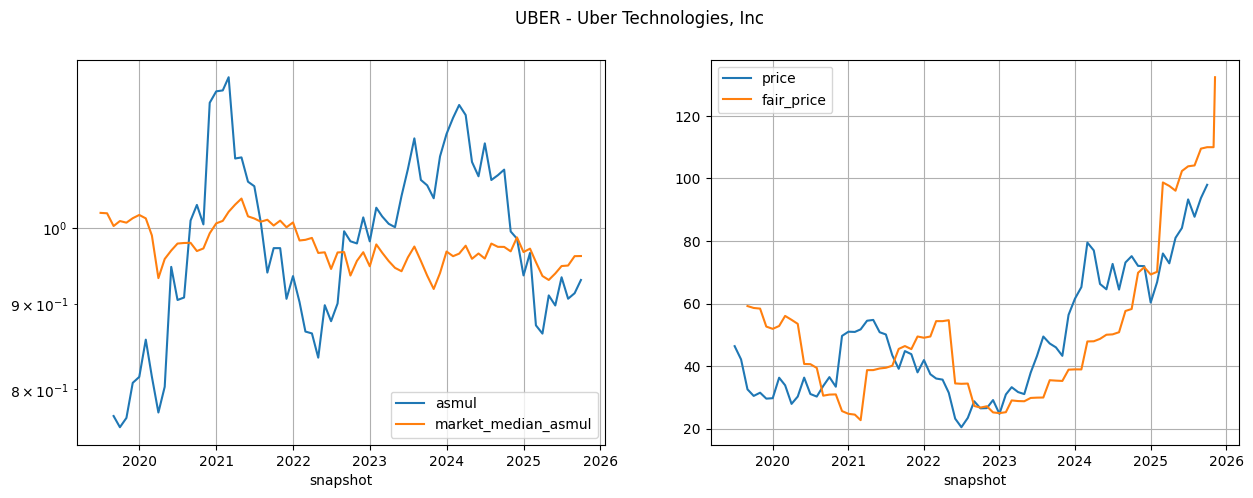

Uber Technologies, Inc stock pricing model:
UBER fair_price = 4.0485 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 0.0098


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001543151,2025-03-31,UBER,52.822000,30.847000,8.045000,0.574249,0.983548,25.725786,104.161766
2025-09-01,0001543151,2025-06-30,UBER,55.982000,33.384000,8.789000,0.611831,0.983548,27.054345,109.540498
2025-10-01,0001543151,2025-06-30,UBER,55.982000,33.384000,8.789000,0.624741,0.983548,27.167819,109.999902
2025-11-01,0001543151,2025-06-30,UBER,55.982000,33.384000,8.789000,0.624741,0.983548,27.167819,109.999902
2025-11-08,0001543151,2025-09-30,UBER,63.344000,35.210000,8.966000,0.624741,0.983548,32.693276,132.369959


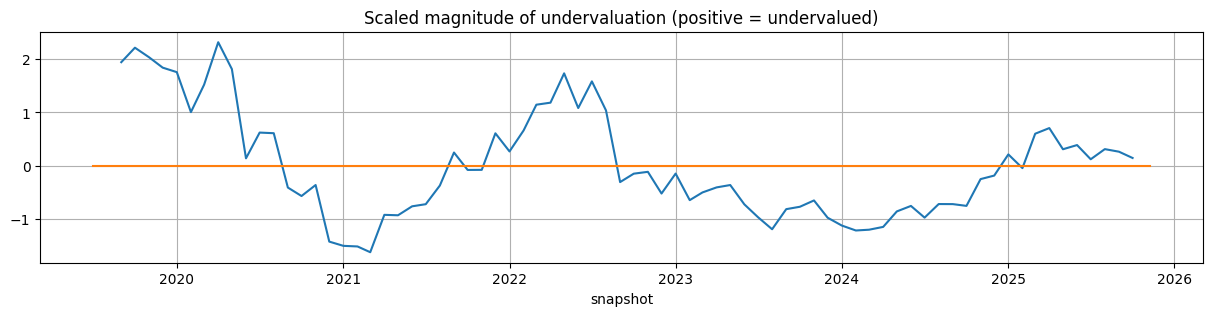

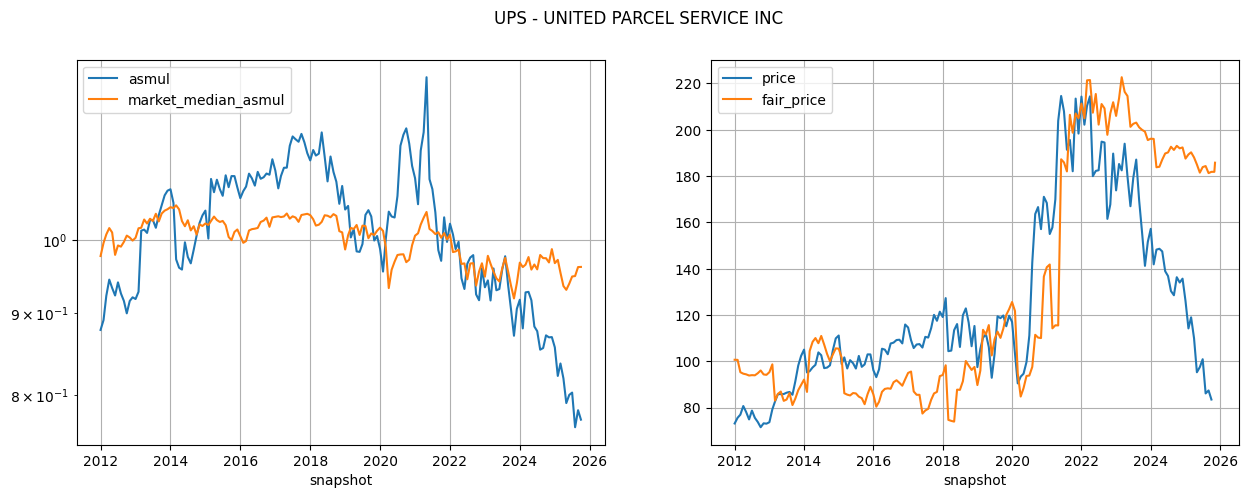

UNITED PARCEL SERVICE INC stock pricing model:
UPS fair_price = 5.6775 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 59.631


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001090727,2025-03-31,UPS,68.466000,52.806000,9.124000,0.574249,1.015570,21.965446,184.340461
2025-09-01,0001090727,2025-06-30,UPS,70.923000,55.173000,7.479000,0.611831,1.015570,21.430138,181.301232
2025-10-01,0001090727,2025-06-30,UPS,70.923000,55.173000,7.479000,0.624741,1.015570,21.526699,181.849458
2025-11-01,0001090727,2025-06-30,UPS,70.923000,55.173000,7.479000,0.624741,1.015570,21.526699,181.849458
2025-11-08,0001090727,2025-09-30,UPS,71.392000,55.569000,8.463000,0.624741,1.015570,22.221746,185.795613


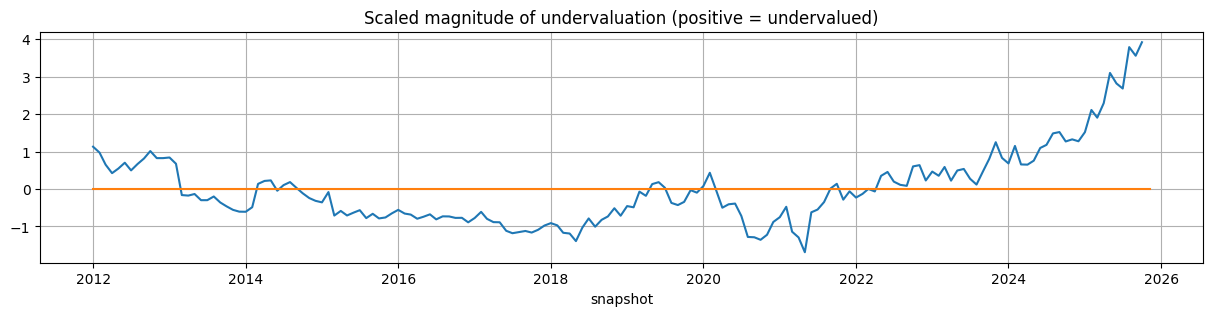

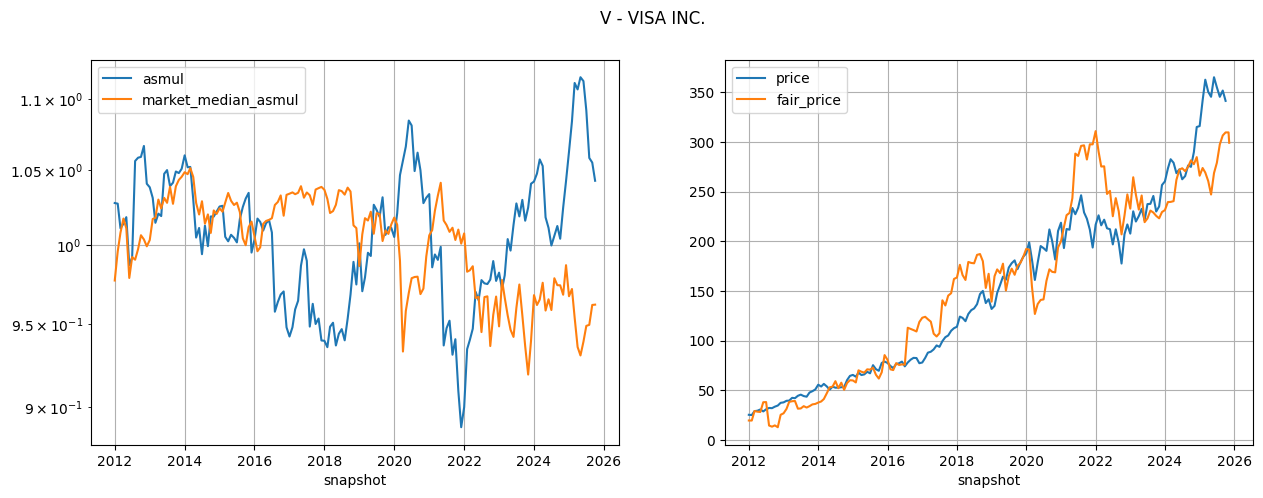

VISA INC. stock pricing model:
V fair_price = 10.1907 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -245.4444


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001403161,2025-06-30,V,100.024000,61.360000,23.485000,0.574249,1.011334,53.283905,297.557751
2025-09-01,0001403161,2025-06-30,V,100.024000,61.360000,23.485000,0.611831,1.011334,54.166518,306.552223
2025-10-01,0001403161,2025-06-30,V,100.024000,61.360000,23.485000,0.624741,1.011334,54.469731,309.642182
2025-11-01,0001403161,2025-06-30,V,100.024000,61.360000,23.485000,0.624741,1.011334,54.469731,309.642182
2025-11-08,0001403161,2025-09-30,V,99.627000,61.718000,23.059000,0.624741,1.011334,53.444091,299.190162


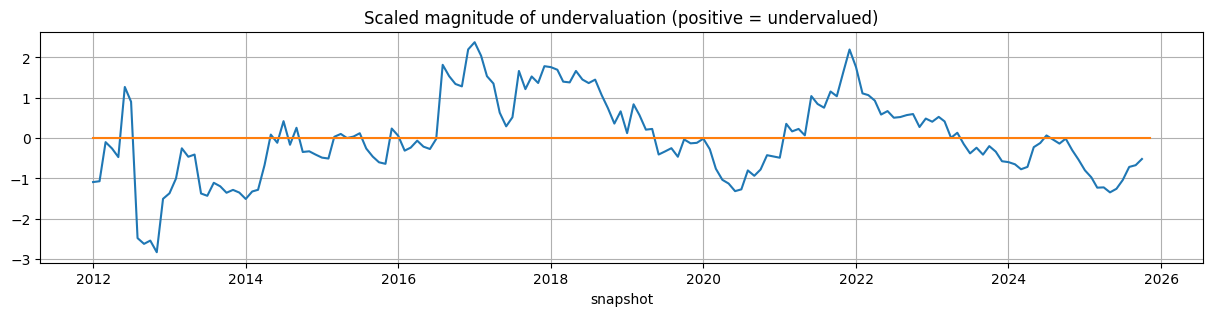

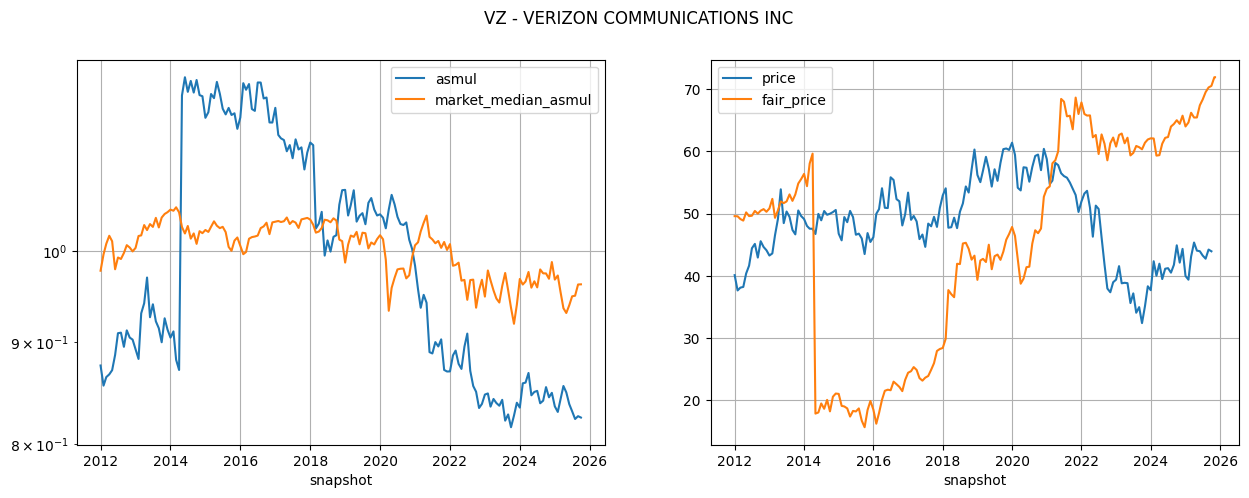

VERIZON COMMUNICATIONS INC stock pricing model:
VZ fair_price = 0.5357 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 11.7739


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000732712,2025-06-30,VZ,383.285000,278.924000,37.100000,0.574249,0.953373,107.794312,69.524070
2025-09-01,0000732712,2025-06-30,VZ,383.285000,278.924000,37.100000,0.611831,0.953373,109.188603,70.271053
2025-10-01,0000732712,2025-06-30,VZ,383.285000,278.924000,37.100000,0.624741,0.953373,109.667597,70.527671
2025-11-01,0000732712,2025-09-30,VZ,388.331000,281.986000,38.455000,0.624741,0.953373,112.262844,71.918058
2025-11-08,0000732712,2025-09-30,VZ,388.331000,281.986000,38.455000,0.624741,0.953373,112.262844,71.918058


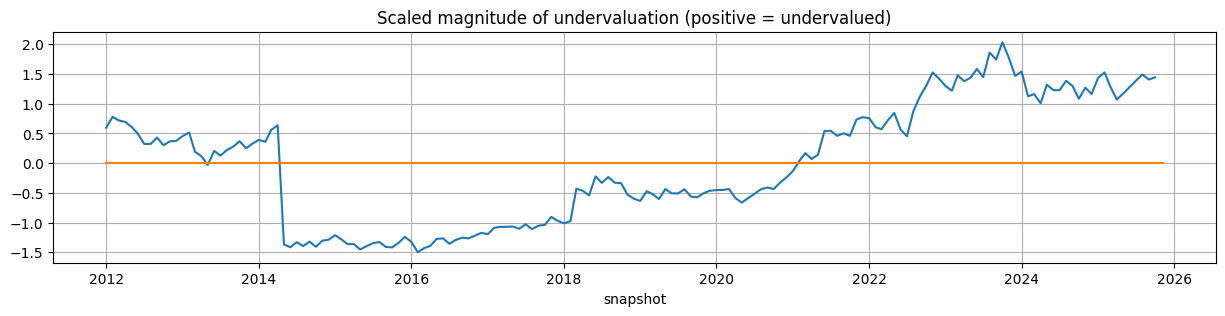

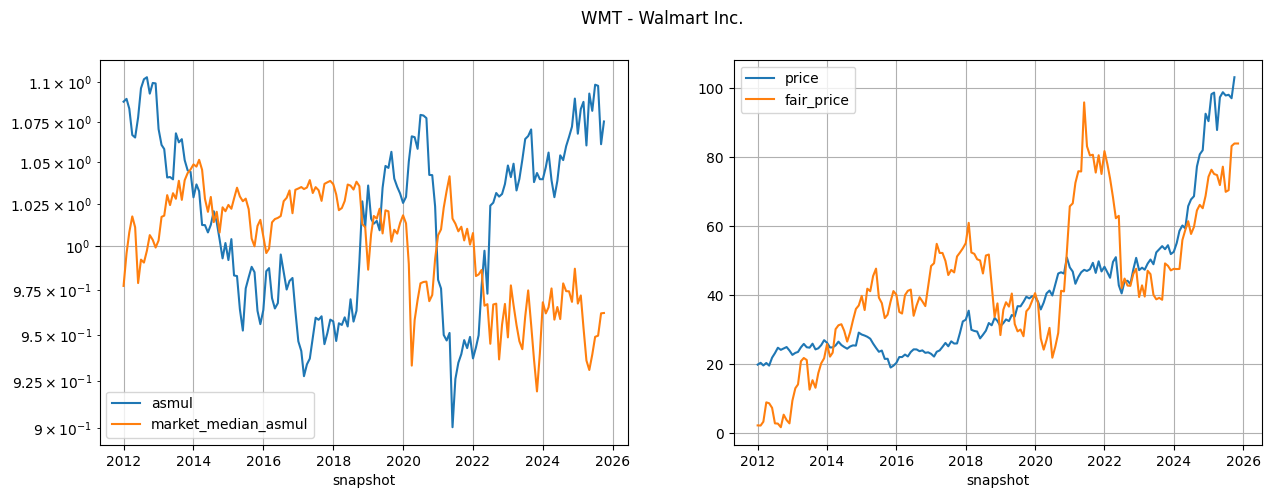

Walmart Inc. stock pricing model:
WMT fair_price = 1.505 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -99.1444


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0000104169,2025-04-30,WMT,262.372000,178.579000,37.605000,0.574249,1.027649,112.642046,70.384594
2025-09-01,0000104169,2025-07-31,WMT,270.837000,180.727000,38.438000,0.611831,1.027649,121.116023,83.138133
2025-10-01,0000104169,2025-07-31,WMT,270.837000,180.727000,38.438000,0.624741,1.027649,121.612293,83.885030
2025-11-01,0000104169,2025-07-31,WMT,270.837000,180.727000,38.438000,0.624741,1.027649,121.612293,83.885030
2025-11-08,0000104169,2025-07-31,WMT,270.837000,180.727000,38.438000,0.624741,1.027649,121.612293,83.885030


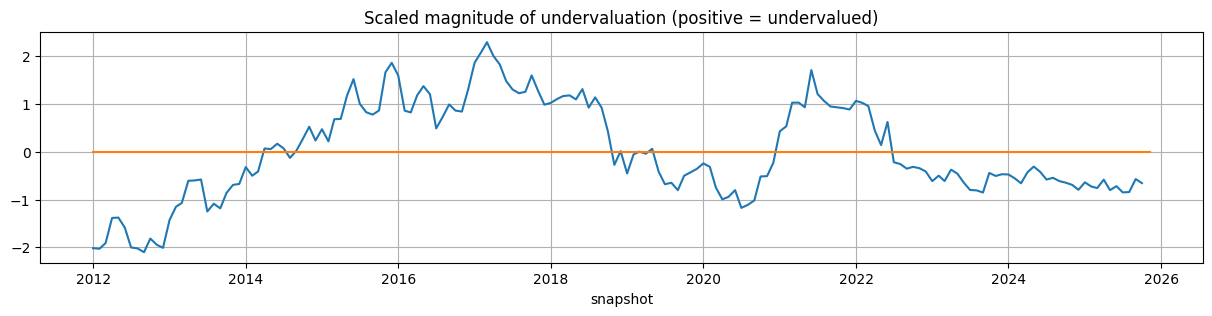

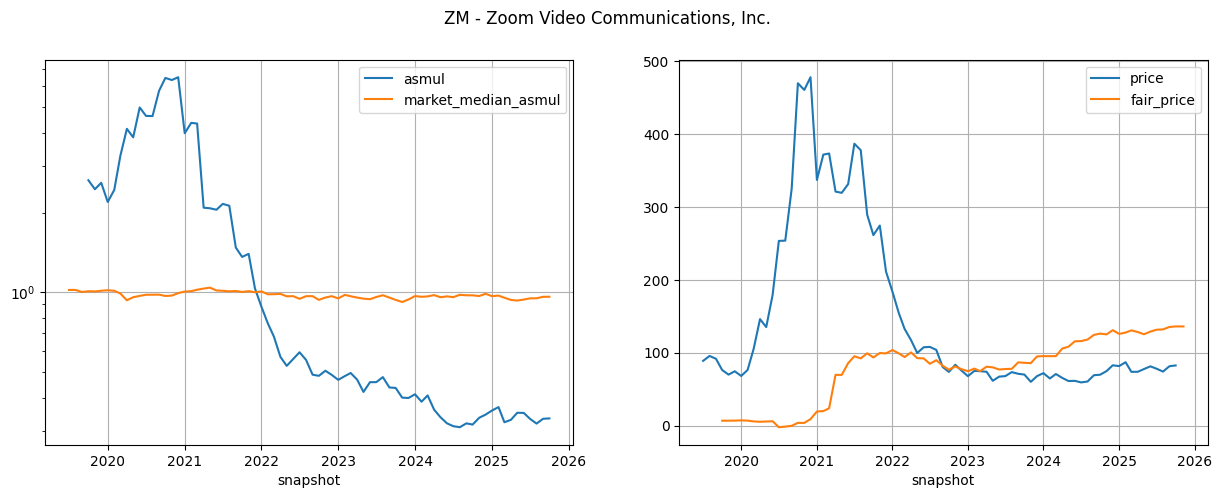

Zoom Video Communications, Inc. stock pricing model:
ZM fair_price = 29.8397 * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -0.4754


,cik,date,ticker,Assets,Liabilities,NetCashOperating_ttm,cashmul,fair_asmul,fair_model,fair_price
snapshot,,,,,,,,,,
2025-08-01,0001585521,2025-04-30,ZM,10.951896,2.049528,1.846378,0.574249,0.495713,4.439744,132.005437
2025-09-01,0001585521,2025-07-31,ZM,11.044063,2.093986,1.912984,0.611831,0.495713,4.551117,135.328763
2025-10-01,0001585521,2025-07-31,ZM,11.044063,2.093986,1.912984,0.624741,0.495713,4.575815,136.065756
2025-11-01,0001585521,2025-07-31,ZM,11.044063,2.093986,1.912984,0.624741,0.495713,4.575815,136.065756
2025-11-08,0001585521,2025-07-31,ZM,11.044063,2.093986,1.912984,0.624741,0.495713,4.575815,136.065756


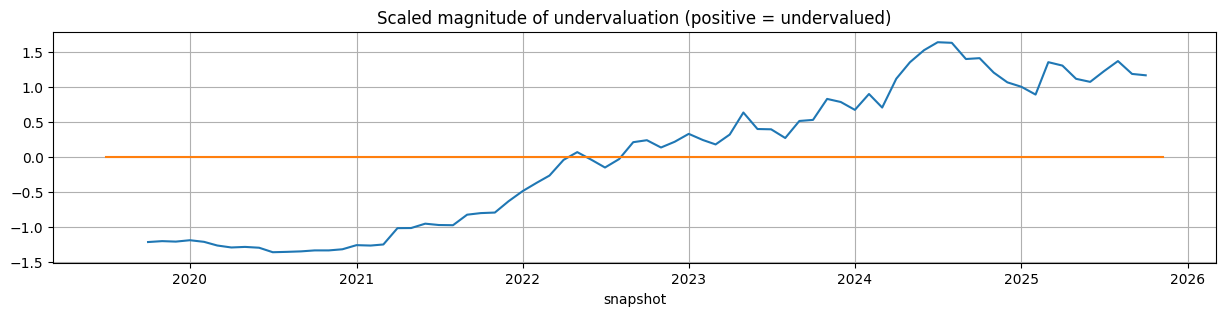

In [18]:
sample_tickers = ["AAPL","ADBE","ADSK","AMD","AMZN","BYND","CAT","COIN","COST","CRSR","CSCO",
                "DIS","ENPH","F","FDX","FSLR","GM","GME","GOOG","GPRO","IBM","ILMN","INTC","IRBT","JNJ","KO"
                "LYFT","META","MMM","MRNA","MSFT","MU","NFLX","NKE","NVDA","ORCL","PFE","PINS","PLTR","PTON","PYPL",
                "ROKU","RUN","T","TDOC","TGT","TLRY","TSLA","UBER","UPS","V","VZ","WMT","ZM"]

market_median_asmul = result['asmul'].groupby(by=['snapshot']).median().rename('market_median_asmul')

def plot_ticker(a_group):
    (ticker, cik), df = a_group
    try:
        name = tickers.loc[cik]['name']
    except:
        name = ""

    df = df.reset_index().set_index('snapshot')
    
    # Used to plot the market baseline for the asset multiplier graph
    df[market_median_asmul.name] = market_median_asmul

    # The cash multiplier is not available for the most recent snapshots, which are not part of the stock prices dataset.
    # We use the last available cash multiplier for the fair price calculation
    df['cashmul'] = df['cashmul'].interpolate()

    # We calculate the fair price by using the same asset multiplier for all data points of a company.
    # The best results seem to be when we use the median
    df['fair_asmul'] = df['asmul'].quantile(0.5)

    # Now we have everything to re-compute the model
    df['fair_model'] = df['fair_asmul'] * df['Assets'] - df['Liabilities'] + df['cashmul']*df['NetCashOperating_ttm']

    # The model values and the price correlate perfectly by design, so the simplest linear regression will yield
    # conversion between our re-calculation of the model and the fair price.
    train_data = df[['model','price']].dropna()
    regressor = linear_model.LinearRegression().fit(X=train_data[['model']],y=train_data['price'])
    fair_model = df[['fair_model']].dropna()
    df['fair_price'] = 0.0
    if not fair_model.empty:
        df['fair_price'] = pd.Series(regressor.predict(fair_model.rename(columns={'fair_model':'model'})),
                                     index=fair_model.index)
    else:
        df['fair_price'] = None

    df['undervaluation'] = preprocessing.scale(df['fair_price']/df['price'])

    fig, (ax1, ax2) = plt.subplots(1,2)
    fig.suptitle(f"{ticker} - {name}")
    fig.set_size_inches(15,5)
    ax1.set_yscale('log')
    df[['asmul',market_median_asmul.name]].plot(ax=ax1, grid=True, legend=True)
    df[['price','fair_price']].plot(ax=ax2, grid=True, legend=True)
    plt.show()

    # Here we spell out our pricing model explicitly
    print(f"{name} stock pricing model:")
    print("{} fair_price = {} * (fair_asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) {} {}".format(
        ticker, regressor.coef_[0].round(4), "+" if regressor.intercept_ >= 0 else "", regressor.intercept_.round(4)
    ))
    display(df.tail(5).dropna(axis='columns'))

    df['undervaluation'].plot(figsize=(15,3),title='Scaled magnitude of undervaluation (positive = undervalued)',grid=True)
    pd.Series([0.0]*len(df.index),index=df.index).plot(grid=True)
    plt.show()

    return df.reset_index().set_index(['snapshot','cik'])

plot_output = pd.concat(list(map(plot_ticker, 
                                 result[result['ticker'].isin(sample_tickers)].groupby(by=['ticker','cik']))))

The model has a lot of room for improvement. It is eazy to notice that, for example, the Verizon model (ticker VZ) has some extreme distortion. It is caused by an abrupt shift in the assets and liabilities between 2014-04-01 and 2014-05-01
| snapshot  | Quarter End |  Assets    | Liabilities | Equity | NetCashOp_ttm |
|-----------|-------------|------------|-------------|--------|---------------|
|2014-04-01 | 2013-12-31  | 274.098000 | 178.682000  | 95.416 | 38.818000     |
|2014-05-01 | 2014-03-31  | 221.562000 | 207.711000  | 13.851 | 38.426000     |

Such anomalies appear for many other companies, too, and should be investigated further. They are probably caused by shifting corporate accounting practicies over time, or there could be logical errors in the processing pipeline, which produces the SEC fundamentals dataset.  
The biggest advantage of the model, however, is that its results are completely explainable.


In [19]:
# Reality check for our fair price calculation: compute its correlation with the actual prices
print(plot_output[['price','fair_price']].corr())
# Sample data
plot_output[plot_output['ticker']=='VZ']

              price  fair_price
price      1.000000    0.790671
fair_price 0.790671    1.000000


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,market_median_asmul,fair_asmul,fair_model,fair_price,undervaluation
snapshot,cik,,,,,,,,,,,,,,
2012-01-01,0000732712,2011-09-30,VZ,228.032000,140.517000,29.761000,40.120000,0.875895,-0.211073,52.933383,0.977244,0.953373,70.600872,49.597918,0.596790
2012-02-01,0000732712,2011-09-30,VZ,228.032000,140.517000,29.761000,37.660000,0.855758,-0.212355,48.303435,0.995861,0.953373,70.562738,49.577489,0.781149
2012-03-01,0000732712,2011-12-31,VZ,230.461000,144.553000,29.780000,38.110000,0.864250,-0.182063,49.200971,1.008213,0.953373,69.740528,49.136995,0.718854
2012-04-01,0000732712,2011-12-31,VZ,230.461000,144.553000,29.780000,38.230000,0.866956,-0.197974,49.350779,1.017511,0.953373,69.266710,48.883150,0.694290
2012-05-01,0000732712,2012-03-31,VZ,222.921000,134.500000,30.702000,40.380000,0.871170,-0.205088,53.405545,1.011091,0.953373,71.730327,50.203017,0.612937
2012-06-01,0000732712,2012-03-31,VZ,222.921000,134.500000,30.702000,41.640000,0.886602,-0.241302,55.733678,0.978869,0.953373,70.618489,49.607357,0.493590
2012-07-01,0000732712,2012-03-31,VZ,222.921000,134.500000,30.702000,44.440000,0.909180,-0.237856,60.872630,0.992283,0.953373,70.724264,49.664025,0.323995
2012-08-01,0000732712,2012-06-30,VZ,226.072000,135.644000,32.259000,45.140000,0.909756,-0.239372,62.304457,0.990584,0.953373,72.165109,50.435949,0.323468
2012-09-01,0000732712,2012-06-30,VZ,226.072000,135.644000,32.259000,42.940000,0.894995,-0.264556,58.154974,0.997459,0.953373,71.352695,50.000703,0.431745


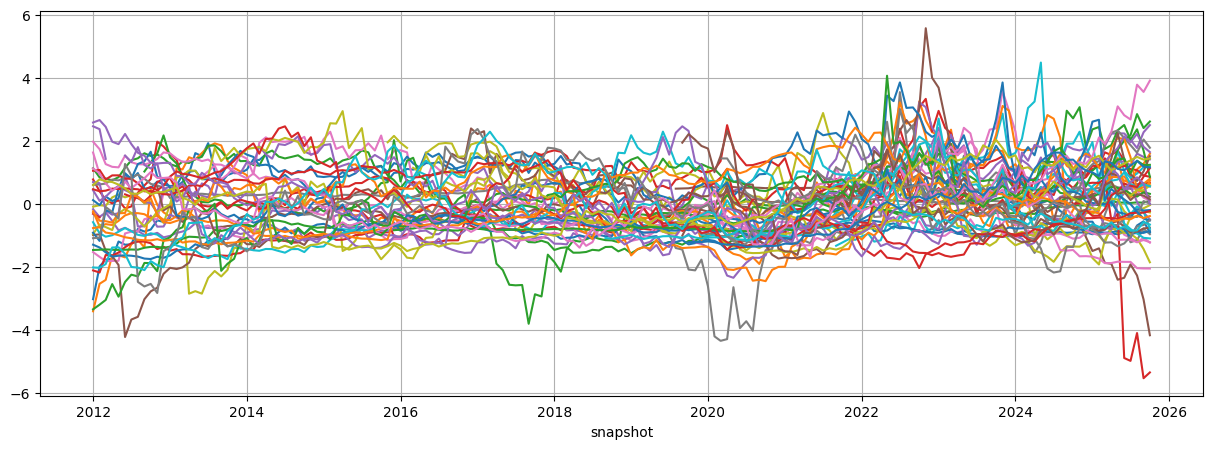

In [20]:
# All undervaluation sequences are scaled, therefore directly comparable
pd.pivot_table(plot_output, index='snapshot',columns='ticker',values='undervaluation').plot(
    grid=True, legend=False, figsize=(15,5))
plt.show()

In [21]:
print('Done without errors')

Done without errors


DISCLAIMER: The results of this model must not in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.